# Testing 6-8 Global Variation

In this notebook, I will compare random lam3/lam4/lam5 values and their base. I will account for how far away their original N is from the base to see if that accounts for why we are seeing power spectra variation.

In [3]:
import numpy as np
import random
from scipy.integrate import solve_ivp
import pygsl.rng #random num generator
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm, colors as mcolors


import sys
import os
import glob


#Should modify the Python import path at runtime
sys.path.append('/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/InflationModels')


from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import re

from scipy.interpolate import UnivariateSpline, splrep, splev, CubicSpline, interp1d, PchipInterpolator, InterpolatedUnivariateSpline
import numdifftools as nd
from scipy.integrate import cumulative_trapezoid, solve_ivp, odeint


from pathlib import Path



## Functions that get re-used

In [4]:
colors = {
    5: "pink",
    6: "turquoise",
    7: "plum",
    8: "mediumslateblue",
    9: "blue",
}

def load_path_data(NEQS, param_name, value):
    val_str = f"{value:.10e}"
    folder = os.path.join(
        base_path_root,
        f"neqs{NEQS}",
        f"{param_name}_{val_str}",
    )
    file_path = os.path.join(
        folder,
        f"path_neqs{NEQS}_{param_name}_{val_str}.dat",
    )
    return pd.read_csv(file_path, sep=r"\s+", header=None).values

def folder_for(NEQS, param_name, value):
    val_str = f"{value:.10e}"
    return os.path.join(
        base_path_root,
        f"neqs{NEQS}",
        f"{param_name}_{val_str}"
    )

def load_specs(NEQS, param_name, value):
    folder = folder_for(NEQS, param_name, value)

    s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
    t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

    k_s = s[:, 0]
    Ps = np.abs(s[:, 1])

    k_t = t[:, 0]
    Pt = np.abs(t[:, 1])

    return k_s, Ps, k_t, Pt


    
def prepare_increasing(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    order = np.argsort(x)
    return x[order], y[order]

def normalize_curve_at_Nref(N, Y, N_ref=60.0, ref_floor=1e-20):
    N_use, Y_use = prepare_increasing(N, Y)

    if not (N_use.min() <= N_ref <= N_use.max()):
        raise ValueError(
            f"N_ref={N_ref} outside range [{N_use.min()}, {N_use.max()}]"
        )

    Y_ref = np.interp(N_ref, N_use, Y_use)

    if np.abs(Y_ref) < ref_floor:
        raise ValueError(f"Reference too small: {Y_ref:.3e}")

    return N_use, Y_use / Y_ref, Y_ref

def normalize_at_ref(k, P):
        k, P = prepare_increasing(k, P)
        P_ref = np.interp(k_ref, k, P)
        return k, P / P_ref, P_ref


def fractional_difference_on_overlap(x, y, x_ref, y_ref, frac_floor=1e-30):
    x, y = prepare_increasing(x, y)
    x_ref, y_ref = prepare_increasing(x_ref, y_ref)

    xmin = max(np.min(x), np.min(x_ref))
    xmax = min(np.max(x), np.max(x_ref))

    mask = (x >= xmin) & (x <= xmax)

    x_use = x[mask]
    y_use = y[mask]

    y_ref_interp = np.interp(x_use, x_ref, y_ref)

    frac = (y_use - y_ref_interp) / np.where(
        np.abs(y_ref_interp) > frac_floor,
        y_ref_interp,
        np.nan,
    )

    return x_use, frac


def get_base_dir(NEQS, param_name, base_value, base_path_root):
    val_str = f"{base_value:.10e}"
    folder = os.path.join(
        base_path_root,
        f"neqs{NEQS}",
        f"{param_name}_{val_str}"
    )

    if not os.path.exists(folder):
        raise FileNotFoundError(f"Missing base folder: {folder}")

    return folder



def get_param_values_from_dirs(NEQS, param_name, base_path_root, show_summary=True):
    base_path = f"{base_path_root}/neqs{NEQS}"
    pattern = os.path.join(base_path, f"{param_name}_*")
    dirs = glob.glob(pattern)

    values = []

    for d in dirs:
        try:
            base = os.path.basename(d)
            val_str = base.replace(f"{param_name}_", "")
            val = float(val_str)
            label = rf"${param_name} = {val:.1e}$"
            values.append((val, label))
        except Exception as e:
            print(f"Skipping {d}: {e}")

    values.sort(key=lambda x: x[0])

    if show_summary:
        print(f"\n{'='*60}")
        print(f"Summary for NEQS={NEQS}, parameter={param_name}")
        print(f"{'='*60}")
        print(f"Total models found: {len(values)}")
        if len(values) > 0:
            print(f"Parameter range: {values[0][0]:.3e} to {values[-1][0]:.3e}")
        else:
            print("Parameter range: none found")
        print(f"{'='*60}\n")

    return values

Let's run our base models:

In [6]:
# LAM_BASE = {
#     6: ("lam3", -4.60971e-6),
#     7: ("lam4",  6.87065e-8),
#     8: ("lam5", -8.92461e-9),
# }

LAM_BASE = {
    5: ("lam2", 0.000278972),
    6: ("lam3", -4.60971e-6),
    7: ("lam4",  6.87065e-8),
    8: ("lam5", -8.92461e-9),
    9: ("lam6", 6.1e-10),
}



base_path_root = "/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests"


base_dirs = {}

for NEQS, (param_name, base_val) in LAM_BASE.items():
    folder = get_base_dir(NEQS, param_name, base_val, base_path_root)
    base_dirs[NEQS] = {
        "param_name": param_name,
        "value": base_val,
        "folder": folder
    }

    print(f"NEQS={NEQS}: {folder}")

NEQS=5: /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs5/lam2_2.7897200000e-04
NEQS=6: /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs6/lam3_-4.6097100000e-06
NEQS=7: /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs7/lam4_6.8706500000e-08
NEQS=8: /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs8/lam5_-8.9246100000e-09
NEQS=9: /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs9/lam6_6.1000000000e-10


When I ran my code I modified it to also include the original N information which I can include. If I want to print that information out I can do that as well. So, this will load the summary information associated with e-folds.

In [12]:
def load_base_summary_row(NEQS, param_name, base_value, base_path_root):
    summary_file = f"{base_path_root}/neqs{NEQS}/neqs{NEQS}_summary.csv"
    df = pd.read_csv(summary_file)

    idx = np.argmin(np.abs(df[param_name] - base_value))
    return df.iloc[idx]

rows = []

for NEQS, (param_name, base_val) in LAM_BASE.items():
    row = load_base_summary_row(NEQS, param_name, base_val, base_path_root)

    rows.append({
        "NEQS": NEQS,
        "param": param_name,
        "value": row[param_name],
        "n_s": row["n_s"],
        "r": row["r"],
        "original_N_end": row["original_N_end"],
        "spectrum_N_start": row["spectrum_N_start"],
        "path_N_end": row["path_N_end"],
    })

base_summary_df = pd.DataFrame(rows)
print(base_summary_df.to_string(index=False))

#Compare relative to 6 base
ref = base_summary_df.loc[base_summary_df["NEQS"] == 6, "original_N_end"].iloc[0]

base_summary_df["delta_N_vs_NEQS6"] = (
    base_summary_df["original_N_end"] - ref
)


# #This will print the information
# print(base_summary_df.to_string(index=False))

 NEQS param         value      n_s        r  original_N_end  spectrum_N_start  path_N_end
    5  lam2  2.789720e-04 0.959171 0.004996      929.312981          0.000156        60.0
    6  lam3 -4.609710e-06 0.965678 0.003454      939.163572          0.000160        60.0
    7  lam4  6.870650e-08 0.967201 0.003158      941.837071          0.000156        60.0
    8  lam5 -8.924610e-09 0.969485 0.002737      946.349733          0.000156        60.0
    9  lam6  6.100000e-10 0.970677 0.002529      948.989450          0.000156        60.0


These are scan info for each lamX.

In [8]:
SCAN_INFO = {
    5: ("lam2",  r"\lambda_2"),
    6: ("lam3",  r"\lambda_3"),
    7: ("lam4",  r"\lambda_4"),
    8: ("lam5",  r"\lambda_5"),
    9: ("lam6",  r"\lambda_6"),
    10: ("lam7", r"\lambda_7"),
    11: ("lam8", r"\lambda_8"),
    12: ("lam9", r"\lambda_9"),
    13: ("lam10", r"\lambda_{10}"),
}

## To examine the original power spectra:

Before applying any ΔN-shift, how much spread remains in normalized spectra among models with acceptable ns?

In [9]:
def plot_filtered_spectra_by_ns(
    NEQS,
    lamX_values,
    baseX,
    base_path_root,
    ns_min=0.955,
    ns_max=0.974,
    ns_target=0.967,
    k_ref=0.05,
    k_max_scalar=10.0,
    cmap_name="plasma",
    save_name=None,
    show=True,
):

    scan_name, scan_symbol = SCAN_INFO[NEQS]

    def sanitize_lam_values(vals):#extracts only first value
        return np.array([x[0] if isinstance(x, tuple) else x for x in vals], dtype=float)

    def folder_for(value):
        val_str = f"{value:.10e}"
        return os.path.join(base_path_root, f"neqs{NEQS}", f"{scan_name}_{val_str}")

    def load_observables(value): #loads ns and r and stuff
        arr = np.loadtxt(os.path.join(folder_for(value), f"test_nr_neqs{NEQS}.dat"))
        arr = np.atleast_1d(arr)
        return arr[0], arr[1], arr[2]

    def load_specs(value):
        folder = folder_for(value)
        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))
        return s[:, 0], np.abs(s[:, 1]), t[:, 0], np.abs(t[:, 1])

    def prepare_increasing(x, y):
        x = np.asarray(x)
        y = np.asarray(y)
        dx = np.diff(x)

        if np.all(dx >= 0):
            return x, y
        elif np.all(dx <= 0):
            return x[::-1], y[::-1]
        else:
            raise ValueError("x grid is not monotonic")

    def normalize_at_ref(x, y, x_ref):
        x, y = prepare_increasing(x, y)
        y_ref = np.interp(x_ref, x, y)
        return x, y / y_ref

    def frac_on_base_grid(x_base, y_base, x_cmp, y_cmp, kmax=None):
        x_base, y_base = prepare_increasing(x_base, y_base)
        x_cmp, y_cmp = prepare_increasing(x_cmp, y_cmp)

        xmin = max(np.min(x_base), np.min(x_cmp)) #returns largest item
        xmax = min(np.max(x_base), np.max(x_cmp))

        # ONLY upper cutoff
        if kmax is not None:
            xmax = min(xmax, kmax)

        mask = (x_base >= xmin) & (x_base <= xmax)
        x_use = x_base[mask]
        y_base_use = y_base[mask]
        y_cmp_interp = np.interp(x_use, x_cmp, y_cmp)

        frac = (y_cmp_interp - y_base_use) / y_base_use
        return x_use, frac

    lam_vals = sanitize_lam_values(lamX_values)

    r_base, ns_base, alpha_base = load_observables(baseX)

    k_s_base_raw, Ps_base_raw, k_t_base_raw, Pt_base_raw = load_specs(baseX)

    k_s_base, Ps_base_norm = normalize_at_ref(k_s_base_raw, Ps_base_raw, k_ref)
    k_t_base, Pt_base_norm = normalize_at_ref(k_t_base_raw, Pt_base_raw, k_ref)

    rows = []
    kept_models = []

    for lamX in lam_vals:
        try:
            r, ns, alpha_s = load_observables(lamX)

            k_s_raw, Ps_raw, k_t_raw, Pt_raw = load_specs(lamX)

            k_s, Ps_norm = normalize_at_ref(k_s_raw, Ps_raw, k_ref)
            k_t, Pt_norm = normalize_at_ref(k_t_raw, Pt_raw, k_ref)

            k_ps_err, frac_ps = frac_on_base_grid(
                k_s_base, Ps_base_norm, k_s, Ps_norm, kmax=k_max_scalar
            )

            k_pt_err, frac_pt = frac_on_base_grid(
                k_t_base, Pt_base_norm, k_t, Pt_norm, kmax=None
            )

            #multiply frac error by 100 so in percents
            mean_dPs_pct = 100.0 * np.nanmean(frac_ps)
            max_dPs_pct = 100.0 * np.nanmax(np.abs(frac_ps))
            mean_dPt_pct = 100.0 * np.nanmean(frac_pt)
            max_dPt_pct = 100.0 * np.nanmax(np.abs(frac_pt))

            
            keep = ns_min <= ns <= ns_max

            row = {
                "lamX": lamX,
                "r": r,
                "ns": ns,
                "alpha_s": alpha_s,
                "delta_ns_from_base": ns - ns_base,
                "delta_ns_from_target": ns - ns_target,
                "mean_dPs_pct": mean_dPs_pct,
                "max_dPs_pct": max_dPs_pct,
                "mean_dPt_pct": mean_dPt_pct,
                "max_dPt_pct": max_dPt_pct,
                "kept_by_ns_cut": keep,
            }

            rows.append(row)

            if keep:
                kept_models.append({
                    **row,
                    "k_s": k_s,
                    "Ps_norm": Ps_norm,
                    "k_t": k_t,
                    "Pt_norm": Pt_norm,
                    "k_ps_err": k_ps_err,
                    "frac_ps": frac_ps,
                    "k_pt_err": k_pt_err,
                    "frac_pt": frac_pt,
                })

        except FileNotFoundError:
            print(f"Missing files for {scan_name}={lamX:.5e}")
        except ValueError as e:
            print(f"Skipping {scan_name}={lamX:.5e}: {e}")

    stats_df = pd.DataFrame(rows).sort_values("ns")
    kept_df = stats_df[stats_df["kept_by_ns_cut"]].copy()

    print("\n=== All models summary ===")
    print(f"Total loaded: {len(stats_df)}")
    print(f"Base ns: {ns_base:.6f}")
    print(f"Models in ns window [{ns_min}, {ns_max}]: {len(kept_df)}")

    if not kept_df.empty:
        print("\n=== Filtered models by ns cut ===")
        print(
            kept_df[[
                "lamX", "ns", "delta_ns_from_base",
                "mean_dPs_pct", "max_dPs_pct",
                "mean_dPt_pct", "max_dPt_pct"
            ]].to_string(index=False)
        )

        print("\n=== Error shrink check (in percentages) ===")
        print("All models:")
        print(
            stats_df[["mean_dPs_pct", "max_dPs_pct", "mean_dPt_pct", "max_dPt_pct"]]
            .agg(["mean", "max"])
            .to_string()
        )
        print("\nFiltered models:")
        print(
            kept_df[["mean_dPs_pct", "max_dPs_pct", "mean_dPt_pct", "max_dPt_pct"]]
            .agg(["mean", "max"])
            .to_string()
        )

    fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)

    ax_ps, ax_pt = axes[0]
    ax_ps_err, ax_pt_err = axes[1]

    if len(kept_models) > 0:
        lam_kept = np.array([m["lamX"] for m in kept_models])
        cmap = plt.get_cmap(cmap_name)
        norm = mcolors.Normalize(vmin=np.min(lam_kept), vmax=np.max(lam_kept))

        for m in kept_models:
            color = cmap(norm(m["lamX"]))

            mask_ps_plot = m["k_s"] <= k_max_scalar

            ax_ps.loglog(
                m["k_s"][mask_ps_plot],
                m["Ps_norm"][mask_ps_plot],
                color=color,
                lw=1.8,
                alpha=0.85,
            )

            ax_pt.loglog(
                m["k_t"],
                m["Pt_norm"],
                color=color,
                lw=1.8,
                alpha=0.85,
            )

            ax_ps_err.semilogx(
                m["k_ps_err"],
                100.0 * m["frac_ps"],
                color=color,
                lw=1.5,
                alpha=0.85,
            )

            ax_pt_err.semilogx(
                m["k_pt_err"],
                100.0 * m["frac_pt"],
                color=color,
                lw=1.5,
                alpha=0.85,
            )

        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        fig.colorbar(sm, ax=axes, label=rf"${scan_symbol}$")

    mask_base_s = k_s_base <= k_max_scalar

    ax_ps.loglog(
        k_s_base[mask_base_s],
        Ps_base_norm[mask_base_s],
        color="black",
        lw=3,
        ls="--",
        label=rf"base $n_s={ns_base:.4f}$",
    )

    ax_pt.loglog(
        k_t_base,
        Pt_base_norm,
        color="black",
        lw=3,
        ls="--",
        label=rf"base $n_s={ns_base:.4f}$",
    )

    for ax in [ax_ps_err, ax_pt_err]:
        ax.axhline(0.0, color="black", ls="--", lw=0.8, alpha=0.6)

    ax_ps.axvline(k_ref, color="black", ls=":", alpha=0.7)
    ax_pt.axvline(k_ref, color="black", ls=":", alpha=0.7)

    ax_ps.set_title(rf"Filtered normalized scalar spectra: $P_s/P_s({k_ref})$")
    ax_pt.set_title(rf"Filtered normalized tensor spectra: $P_t/P_t({k_ref})$")
    ax_ps_err.set_title(r"Filtered scalar fractional error")
    ax_pt_err.set_title(r"Filtered tensor fractional error")

    ax_ps.set_xlabel(r"$k$")
    ax_pt.set_xlabel(r"$k$")
    ax_ps_err.set_xlabel(r"$k$")
    ax_pt_err.set_xlabel(r"$k$")

    ax_ps.set_ylabel(r"$P_s/P_s(k_{\rm ref})$")
    ax_pt.set_ylabel(r"$P_t/P_t(k_{\rm ref})$")
    ax_ps_err.set_ylabel(r"% difference in $P_s$")
    ax_pt_err.set_ylabel(r"% difference in $P_t$")

    # ONLY upper cutoff behavior:
    ax_ps.set_xlim(np.min(k_s_base), k_max_scalar)
    ax_ps_err.set_xlim(np.min(k_ps_err), k_max_scalar)

    for ax in axes.ravel():
        ax.grid(True, alpha=0.25)
        handles, labels = ax.get_legend_handles_labels()
        if len(handles) > 0:
            ax.legend(fontsize=8)

    fig.suptitle(
        rf"Models with ${ns_min} \leq n_s \leq {ns_max}$ "
        rf"(target $n_s={ns_target}$)",
        fontsize=16,
    )

    if save_name is None:
        save_name = f"neqs{NEQS}_{scan_name}_filtered_ns_{ns_min}_{ns_max}.png"

    plt.savefig(save_name, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return stats_df, kept_df

## Instead of just looking at how they appear lets take into account their N shift with the function below

This initially just does scalar power spectra but it applies simple first deltaN shift within one NEQs scan. If I shift each model’s k-axis by e−ΔN, do the scalar spectra line up with the base model?

In [10]:
def plot_k_shift_equivalence_scan(
    NEQS,
    lamX_values,
    baseX,
    base_path_root,
    k_norm=0.05,
    k_max_scalar=10.0,
    cmap_name="plasma",
    save_name=None,
):

    scan_name, scan_symbol = SCAN_INFO[NEQS]

    def sanitize_lam_values(vals):
        return np.array(
            [x[0] if isinstance(x, tuple) else x for x in vals],
            dtype=float
        )

    def folder_for(value):
        val_str = f"{value:.10e}"
        return os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"{scan_name}_{val_str}"
        )

    def load_scalar_spec(value):
        folder = folder_for(value)
        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))

        k = s[:, 0]
        Ps = np.abs(s[:, 1])

        order = np.argsort(k)
        return k[order], Ps[order]

    def get_original_N_end(value):
        summary_file = os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"neqs{NEQS}_summary.csv"
        )

        summary_df = pd.read_csv(summary_file)

        matches = summary_df.loc[
            np.isclose(summary_df[scan_name], value)
        ]

        if len(matches) == 0:
            raise ValueError(
                f"No summary row found for {scan_name}={value:.10e}"
            )

        return float(matches.iloc[0]["original_N_end"])

    lam_vals = sanitize_lam_values(lamX_values)

    # -----------------------------
    # Base/reference
    # -----------------------------
    base_N_end = get_original_N_end(baseX)

    k_base, Ps_base = load_scalar_spec(baseX)
    Ps_base_norm = Ps_base / np.interp(k_norm, k_base, Ps_base)

    mask_base = k_base <= k_max_scalar

    fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

    ax.loglog(
        k_base[mask_base],
        Ps_base_norm[mask_base],
        color="black",
        lw=3,
        ls="--",
        label=rf"base {scan_symbol}={baseX:.2e}",
    )

    cmap = plt.get_cmap(cmap_name)
    norm = mcolors.Normalize(vmin=np.min(lam_vals), vmax=np.max(lam_vals))

    rows = []

    for value in lam_vals:
        try:
            k, Ps = load_scalar_spec(value)

            model_N_end = get_original_N_end(value)
            deltaN = model_N_end - base_N_end

            k_shifted = k * np.exp(-deltaN)

            Ps_norm = Ps / np.interp(k_norm, k_shifted, Ps)

            mask = k_shifted <= k_max_scalar
            color = cmap(norm(value))

            ax.loglog(
                k_shifted[mask],
                Ps_norm[mask],
                color=color,
                lw=1.5,
                alpha=0.85,
            )

            rows.append({
                scan_name: value,
                "original_N_end": model_N_end,
                "deltaN_from_base": deltaN,
                "exp_minus_deltaN": np.exp(-deltaN),
            })

        except FileNotFoundError:
            print(f"Missing files for {scan_name}={value:.5e}")

        except ValueError as e:
            print(f"Skipping {scan_name}={value:.5e}: {e}")

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    fig.colorbar(sm, ax=ax, label=rf"${scan_symbol}$")

    ax.axvline(k_norm, color="black", ls=":", alpha=0.6)

    ax.set_xlabel(r"shifted $k$")
    ax.set_ylabel(rf"$P_s/P_s(k={k_norm})$")
    ax.set_title(
        rf"NEQS={NEQS}: scalar spectra after $k \to k e^{{-\Delta N}}$"
    )

    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

    if save_name is None:
        save_name = f"neqs{NEQS}_{scan_name}_all_kshifted_scalar.png"

#     plt.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()

    return pd.DataFrame(rows)



Similar but in a 2x2 plot:

The top-row plots show the spectra as functions of the shifted grid, kshifted=ke−ΔN,so each model is horizontally aligned before plotting.

The bottom-row fractional-error plots are then computed on the fixed unshifted base-model k-grid by interpolating the shifted model spectrum onto that reference grid and comparing

(Pshifted −Pbase)/Pbase


In [11]:
def plot_k_shift_equivalence_scan_2x2(
    NEQS,
    lamX_values,
    baseX,
    base_path_root,
    k_norm=0.05,
    k_max_scalar=10.0,
    cmap_name="plasma",
    save_name=None,
):
  
    scan_name, scan_symbol = SCAN_INFO[NEQS]

    def sanitize_lam_values(vals):
        return np.array(
            [x[0] if isinstance(x, tuple) else x for x in vals],
            dtype=float
        )

    def folder_for(value):
        val_str = f"{value:.10e}"
        return os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"{scan_name}_{val_str}"
        )

    def load_specs_local(value):
        folder = folder_for(value)

        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

        k_s = s[:, 0]
        Ps = np.abs(s[:, 1])

        k_t = t[:, 0]
        Pt = np.abs(t[:, 1])

        k_s, Ps = prepare_increasing(k_s, Ps)
        k_t, Pt = prepare_increasing(k_t, Pt)

        return k_s, Ps, k_t, Pt

    def get_original_N_end(value):
        summary_file = os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"neqs{NEQS}_summary.csv"
        )

        summary_df = pd.read_csv(summary_file)

        matches = summary_df.loc[
            np.isclose(summary_df[scan_name], value)
        ]

        if len(matches) == 0:
            raise ValueError(
                f"No summary row found for {scan_name}={value:.10e}"
            )

        return float(matches.iloc[0]["original_N_end"])

    def normalize_at_k(k, P, k_ref):
        k, P = prepare_increasing(k, P)

        if not (k.min() <= k_ref <= k.max()):
            raise ValueError(
                f"k_ref={k_ref} outside shifted k range "
                f"[{k.min():.3e}, {k.max():.3e}]"
            )

        P_ref = np.interp(k_ref, k, P)

        if np.abs(P_ref) < 1e-30:
            raise ValueError(f"Reference spectrum too small at k={k_ref}")

        return k, P / P_ref, P_ref

    def frac_on_base_grid(k_base, P_base, k_cmp, P_cmp, kmax=None):
        k_base, P_base = prepare_increasing(k_base, P_base)
        k_cmp, P_cmp = prepare_increasing(k_cmp, P_cmp)

        xmin = max(k_base.min(), k_cmp.min())
        xmax = min(k_base.max(), k_cmp.max())

        if kmax is not None:
            xmax = min(xmax, kmax)

        mask = (k_base >= xmin) & (k_base <= xmax)

        k_use = k_base[mask]
        P_base_use = P_base[mask]
        P_cmp_interp = np.interp(k_use, k_cmp, P_cmp)

        frac = (P_cmp_interp - P_base_use) / P_base_use

        return k_use, frac

    lam_vals = sanitize_lam_values(lamX_values)

    # -----------------------------
    # Base/reference
    # -----------------------------
    base_N_end = get_original_N_end(baseX)

    k_s_base_raw, Ps_base_raw, k_t_base_raw, Pt_base_raw = load_specs_local(baseX)

    k_s_base, Ps_base_norm, _ = normalize_at_k(
        k_s_base_raw, Ps_base_raw, k_norm
    )

    k_t_base, Pt_base_norm, _ = normalize_at_k(
        k_t_base_raw, Pt_base_raw, k_norm
    )

    # -----------------------------
    # Figure
    # -----------------------------
    fig, axes = plt.subplots(
        2, 2,
        figsize=(15, 10),
        constrained_layout=True
    )

    ax_ps, ax_pt = axes[0]
    ax_ps_err, ax_pt_err = axes[1]

    cmap = plt.get_cmap(cmap_name)
    norm = mcolors.Normalize(vmin=np.min(lam_vals), vmax=np.max(lam_vals))

    rows = []

    for value in lam_vals:

        try:
            model_N_end = get_original_N_end(value)
            deltaN = model_N_end - base_N_end

            k_s_raw, Ps_raw, k_t_raw, Pt_raw = load_specs_local(value)

            # In your convention: a(N) ~ exp(-N),
            # so N-shift corresponds to k -> k exp(-deltaN).
            k_s_shifted = k_s_raw * np.exp(-deltaN)
            k_t_shifted = k_t_raw * np.exp(-deltaN)

            k_s, Ps_norm, _ = normalize_at_k(
                k_s_shifted, Ps_raw, k_norm
            )

            k_t, Pt_norm, _ = normalize_at_k(
                k_t_shifted, Pt_raw, k_norm
            )

            k_ps_err, frac_ps = frac_on_base_grid(
                k_s_base,
                Ps_base_norm,
                k_s,
                Ps_norm,
                kmax=k_max_scalar
            )

            k_pt_err, frac_pt = frac_on_base_grid(
                k_t_base,
                Pt_base_norm,
                k_t,
                Pt_norm,
                kmax=None
            )

            color = cmap(norm(value))

            mask_s = k_s <= k_max_scalar

            ax_ps.loglog(
                k_s[mask_s],
                Ps_norm[mask_s],
                color=color,
                lw=1.5,
                alpha=0.85,
            )

            ax_pt.loglog(
                k_t,
                Pt_norm,
                color=color,
                lw=1.5,
                alpha=0.85,
            )

            ax_ps_err.semilogx(
                k_ps_err,
                100.0 * frac_ps,
                color=color,
                lw=1.4,
                alpha=0.85,
            )

            ax_pt_err.semilogx(
                k_pt_err,
                100.0 * frac_pt,
                color=color,
                lw=1.4,
                alpha=0.85,
            )

            rows.append({
                scan_name: value,
                "original_N_end": model_N_end,
                "deltaN_from_base": deltaN,
                "exp_minus_deltaN": np.exp(-deltaN),

                "mean_dPs_pct": 100.0 * np.nanmean(frac_ps),
                "max_dPs_pct": 100.0 * np.nanmax(np.abs(frac_ps)),

                "mean_dPt_pct": 100.0 * np.nanmean(frac_pt),
                "max_dPt_pct": 100.0 * np.nanmax(np.abs(frac_pt)),
            })

        except FileNotFoundError:
            print(f"Missing files for {scan_name}={value:.5e}")

        except ValueError as e:
            print(f"Skipping {scan_name}={value:.5e}: {e}")

    # -----------------------------
    # Base overlays
    # -----------------------------
    mask_base_s = k_s_base <= k_max_scalar

    ax_ps.loglog(
        k_s_base[mask_base_s],
        Ps_base_norm[mask_base_s],
        color="black",
        lw=3,
        ls="--",
        label=rf"base ${scan_symbol}={baseX:.2e}$",
    )

    ax_pt.loglog(
        k_t_base,
        Pt_base_norm,
        color="black",
        lw=3,
        ls="--",
        label=rf"base ${scan_symbol}={baseX:.2e}$",
    )

    for ax in [ax_ps_err, ax_pt_err]:
        ax.axhline(
            0.0,
            color="black",
            ls="--",
            lw=0.8,
            alpha=0.6,
        )

    ax_ps.axvline(k_norm, color="black", ls=":", alpha=0.7)
    ax_pt.axvline(k_norm, color="black", ls=":", alpha=0.7)

    # -----------------------------
    # Labels
    # -----------------------------
    ax_ps.set_title(
        rf"Shifted scalar spectra: $P_s/P_s({k_norm})$"
    )

    ax_pt.set_title(
        rf"Shifted tensor spectra: $P_t/P_t({k_norm})$"
    )

    ax_ps_err.set_title(
        r"Shifted scalar fractional error"
    )

    ax_pt_err.set_title(
        r"Shifted tensor fractional error"
    )

    ax_ps.set_xlabel(r"shifted $k$")
    ax_pt.set_xlabel(r"shifted $k$")
    ax_ps_err.set_xlabel(r"$k$ on base grid")
    ax_pt_err.set_xlabel(r"$k$ on base grid")

    ax_ps.set_ylabel(rf"$P_s/P_s(k={k_norm})$")
    ax_pt.set_ylabel(rf"$P_t/P_t(k={k_norm})$")
    ax_ps_err.set_ylabel(r"% difference in $P_s$")
    ax_pt_err.set_ylabel(r"% difference in $P_t$")

    ax_ps.set_xlim(k_s_base.min(), k_max_scalar)
    ax_ps_err.set_xlim(k_s_base.min(), k_max_scalar)

    for ax in axes.ravel():
        ax.grid(True, alpha=0.25)
        handles, labels = ax.get_legend_handles_labels()
        if len(handles) > 0:
            ax.legend(fontsize=8)

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    fig.colorbar(sm, ax=axes, label=rf"${scan_symbol}$")

    fig.suptitle(
        rf"NEQS={NEQS}: spectra after $k \to k e^{{-\Delta N}}$ "
        rf"relative to base ${scan_symbol}={baseX:.2e}$",
        fontsize=16,
    )

    if save_name is None:
        save_name = f"neqs{NEQS}_{scan_name}_all_kshifted_spectra_2x2.png"

#     plt.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()

    stats_df = pd.DataFrame(rows)

    if not stats_df.empty:
        print("\n=== Shifted spectra fractional-error summary ===")
        print(
            stats_df[[
                scan_name,
                "deltaN_from_base",
                "mean_dPs_pct",
                "max_dPs_pct",
                "mean_dPt_pct",
                "max_dPt_pct",
            ]].to_string(index=False)
        )

    return stats_df



## LAM2


Summary for NEQS=5, parameter=lam2
Total models found: 40
Parameter range: 2.738e-04 to 4.653e-03


=== All models summary ===
Total loaded: 40
Base ns: 0.959171
Models in ns window [0.963, 0.969]: 20

=== Filtered models by ns cut ===
    lamX       ns  delta_ns_from_base  mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct
0.000410 0.963605            0.004434     -0.828597     3.888950      0.739030     3.047166
0.000420 0.963986            0.004814     -0.899572     4.122936      0.779975     3.221463
0.000424 0.964151            0.004980     -0.961169     4.290303      0.797147     3.294715
0.000427 0.964257            0.005085     -0.974982     4.359178      0.807852     3.340401
0.000435 0.964552            0.005381     -1.024618     4.611613      0.837095     3.465511
0.000439 0.964708            0.005536     -1.042908     4.744562      0.852030     3.529372
0.000463 0.965675            0.006504     -1.196750     5.619635      0.938608     3.902293
0.000465 0.965727          

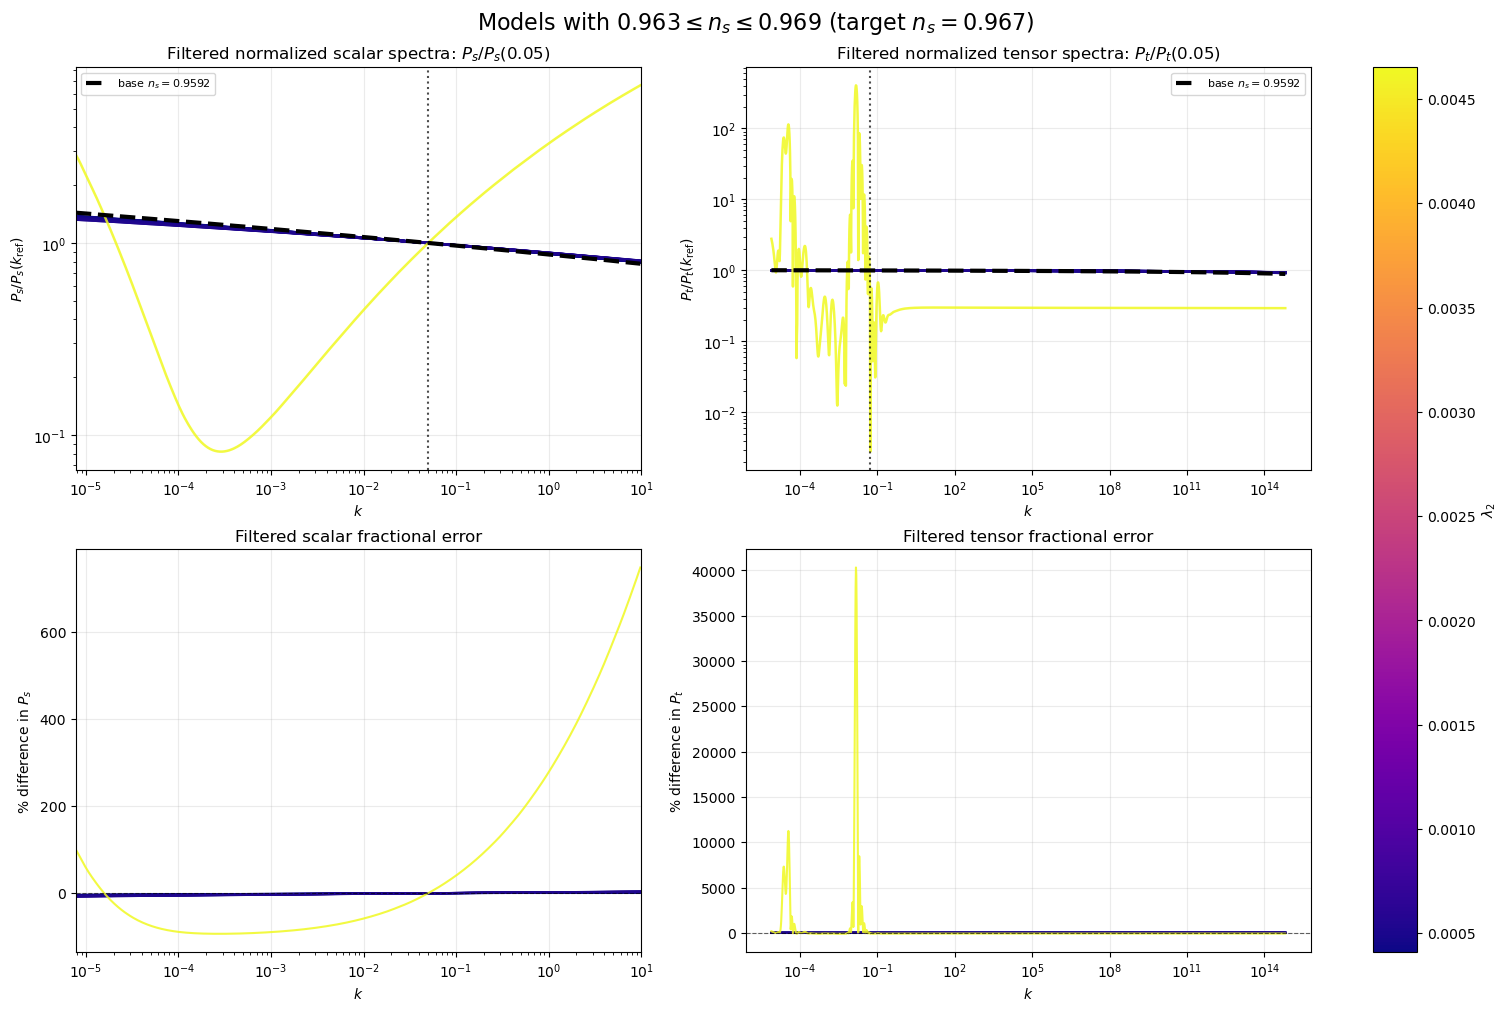

In [29]:
base_path_root = "/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests"
lam2_values = get_param_values_from_dirs(5, "lam2", base_path_root)

stats_df, kept_df = plot_filtered_spectra_by_ns(
    NEQS=5,
    lamX_values=lam2_values,
    baseX= 0.000278972,
    base_path_root="/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests",
    ns_min=0.963,
    ns_max=0.969,
    ns_target=0.967,
    k_ref=0.05,
    k_max_scalar=10.0,
    save_name="neqs5_lam2_filtered_ns_spectra.png"
)

## LAM3


Summary for NEQS=6, parameter=lam3
Total models found: 39
Parameter range: -5.385e-05 to -4.124e-07


=== All models summary ===
Total loaded: 39
Base ns: 0.965678
Models in ns window [0.963, 0.969]: 27

=== Filtered models by ns cut ===
     lamX       ns  delta_ns_from_base  mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct
-0.000046 0.963399           -0.002279      0.463867     3.478058      0.907306     4.044949
-0.000046 0.963489           -0.002189      0.447737     3.495003      0.906044     4.039441
-0.000045 0.963571           -0.002107      0.436794     3.516697      0.904871     4.034319
-0.000003 0.963964           -0.001714      0.262704     1.492713     -0.241361     1.079005
-0.000043 0.964421           -0.001257      0.340033     3.721994      0.891939     3.977717
-0.000043 0.964452           -0.001226      0.239506     3.623974      0.891439     3.975525
-0.000004 0.964739           -0.000939      0.067964     0.770892     -0.129312     0.577973
-0.000004 0.96524

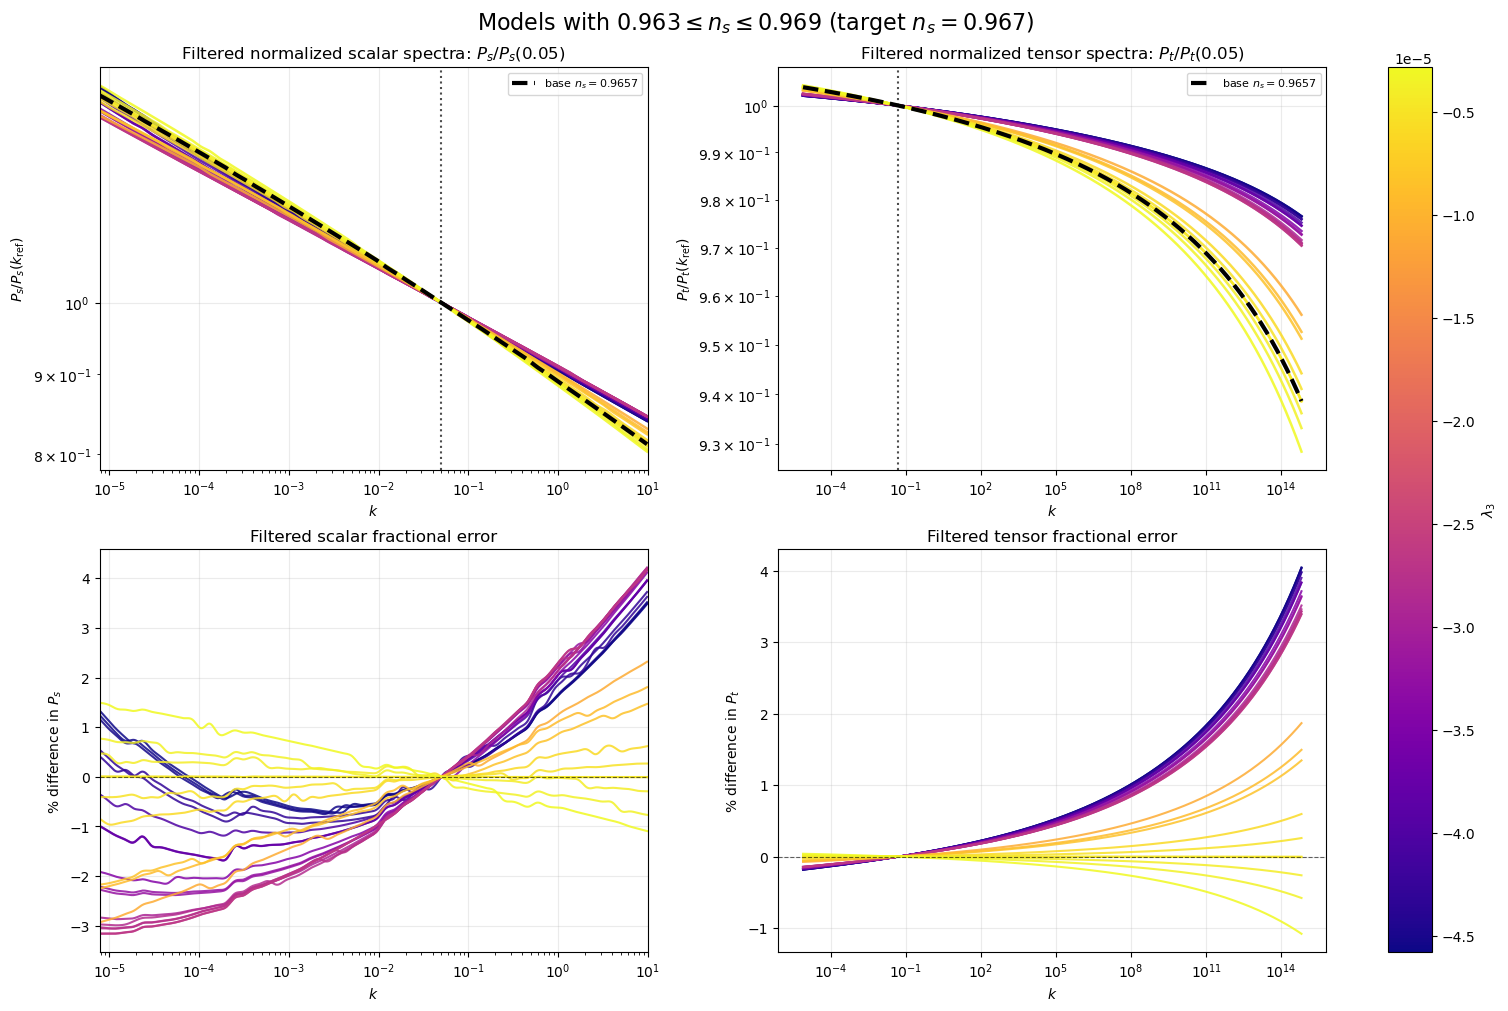

In [22]:
base_path_root = "/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests"
lam3_values = get_param_values_from_dirs(6, "lam3", base_path_root)

stats_df, kept_df = plot_filtered_spectra_by_ns(
    NEQS=6,
    lamX_values=lam3_values,
    baseX=-4.6097100000e-6,
    base_path_root="/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests",
    ns_min=0.963,
    ns_max=0.969,
    ns_target=0.967,
    k_ref=0.05,
    k_max_scalar=10.0,
    save_name="neqs6_lam3_filtered_ns_spectra.png"
)

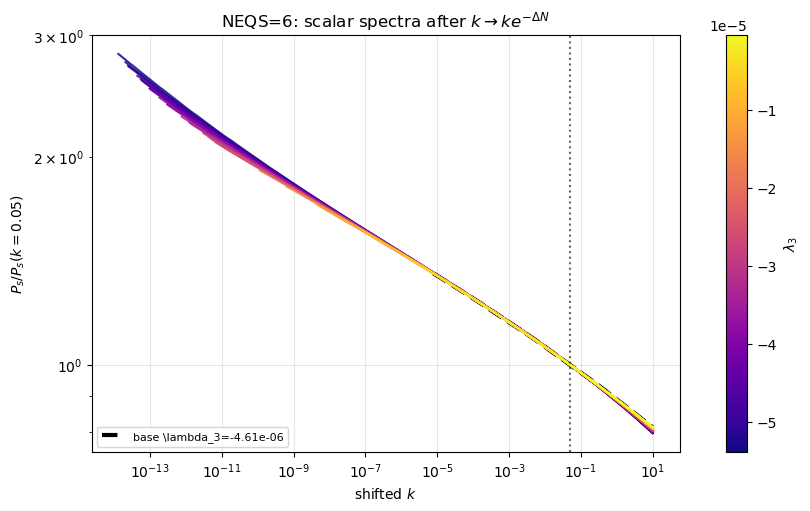

In [23]:
kshift6_df_scalar = plot_k_shift_equivalence_scan(
    NEQS=6,
    lamX_values=lam3_values,
    baseX=-4.6097100000e-6,
    base_path_root=base_path_root,
    k_norm=0.05,
    k_max_scalar=10.0,
    save_name="neqs6_lam3_all_kshifted_scalar.png",
)

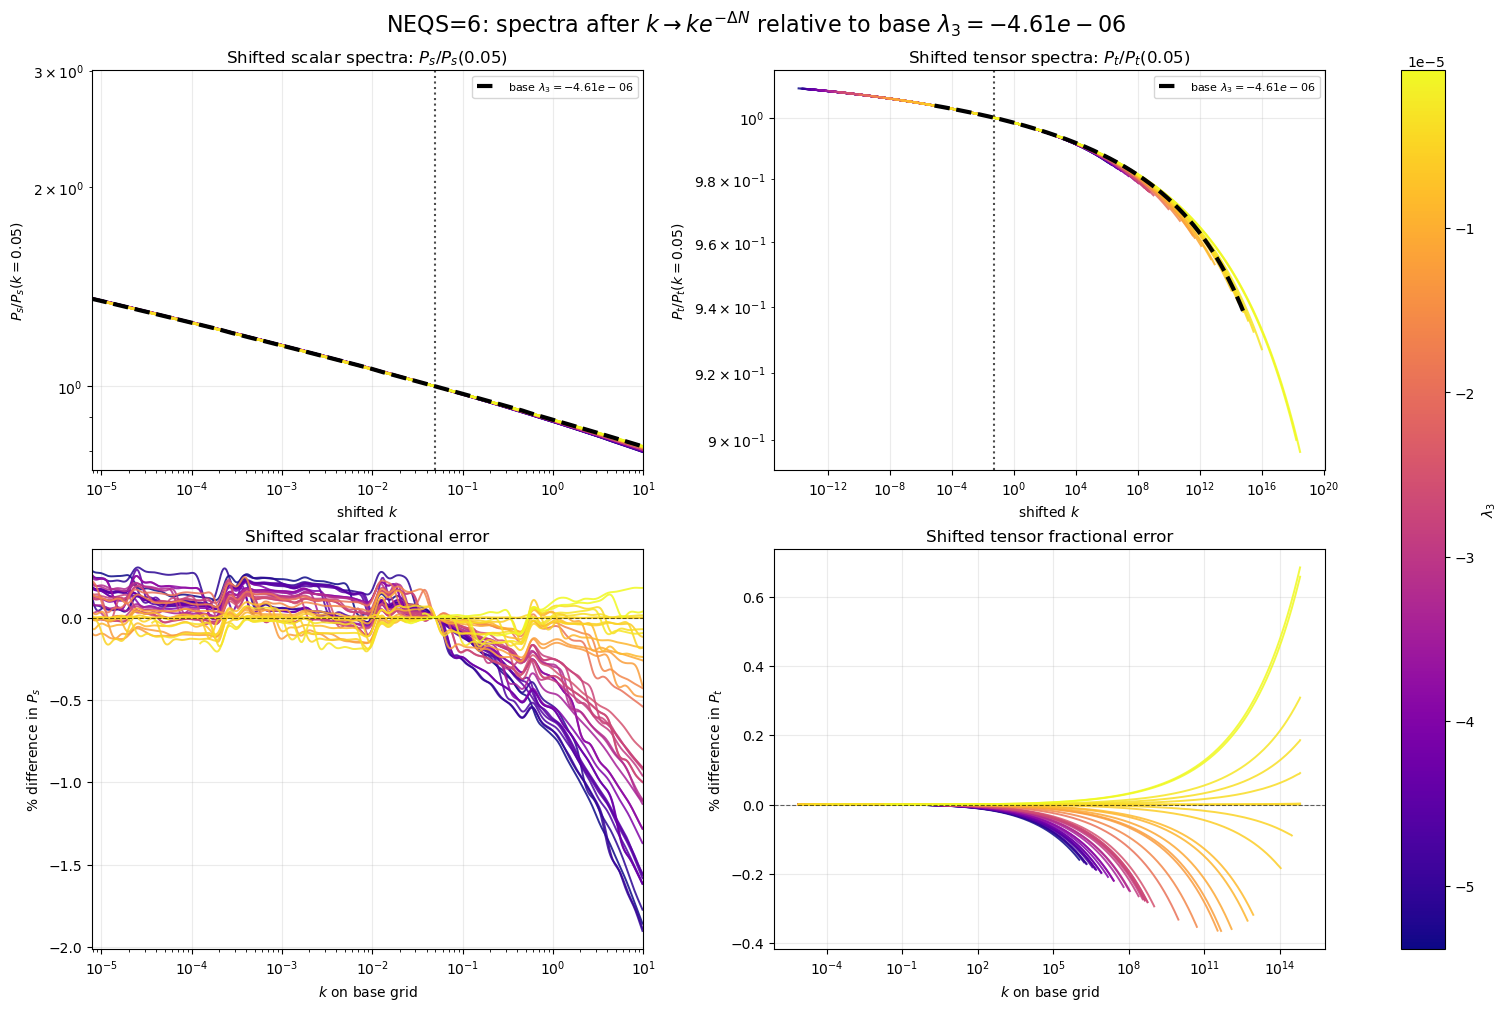


=== Shifted spectra fractional-error summary ===
         lam3  deltaN_from_base  mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct
-5.385109e-05         20.187445     -0.161098     1.858036     -0.022396     0.159524
-5.116411e-05         19.731253     -0.110397     1.773133     -0.023387     0.166943
-5.020221e-05         19.561842     -0.246804     1.902396     -0.023829     0.170319
-4.995717e-05         19.518147     -0.243835     1.886633     -0.024022     0.171838
-4.699539e-05         18.971693     -0.181483     1.615336     -0.025233     0.181026
-4.578533e-05         18.738119     -0.153310     1.581926     -0.025804     0.185438
-4.554858e-05         18.691678     -0.143948     1.563788     -0.025983     0.186918
-4.533016e-05         18.648612     -0.134260     1.553253     -0.026184     0.188540
-4.302045e-05         18.179721     -0.199235     1.616512     -0.027326     0.197490
-4.293461e-05         18.161801     -0.197149     1.614448     -0.027256     0.196872
-4.0

In [24]:
kshift6_df = plot_k_shift_equivalence_scan_2x2(
    NEQS=6,
    lamX_values=lam3_values,
    baseX=-4.6097100000e-6,
    base_path_root=base_path_root,
    k_norm=0.05,
    k_max_scalar=10.0,
    save_name="neqs6_lam3_all_kshifted_spectra_2x2.png",
)

## LAM4


Summary for NEQS=7, parameter=lam4
Total models found: 40
Parameter range: -6.014e-08 to 3.499e-07


=== All models summary ===
Total loaded: 40
Base ns: 0.967201
Models in ns window [0.963, 0.969]: 28

=== Filtered models by ns cut ===
         lamX       ns  delta_ns_from_base  mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct
-4.595628e-08 0.963727           -0.003474      0.657374     3.206053     -0.532801     2.614080
-4.105247e-08 0.964026           -0.003176      0.663394     3.084890     -0.480692     2.348698
-3.562833e-08 0.964317           -0.002885      0.540703     2.709345     -0.431151     2.098265
-2.835396e-08 0.964660           -0.002542      0.488675     2.376604     -0.374380     1.813754
-5.952929e-09 0.965495           -0.001707      0.437513     1.792092     -0.242730     1.163871
-2.418550e-09 0.965605           -0.001596      0.389743     1.608479     -0.225978     1.082160
-2.163669e-09 0.965613           -0.001589      0.383885     1.600759     -0.224802

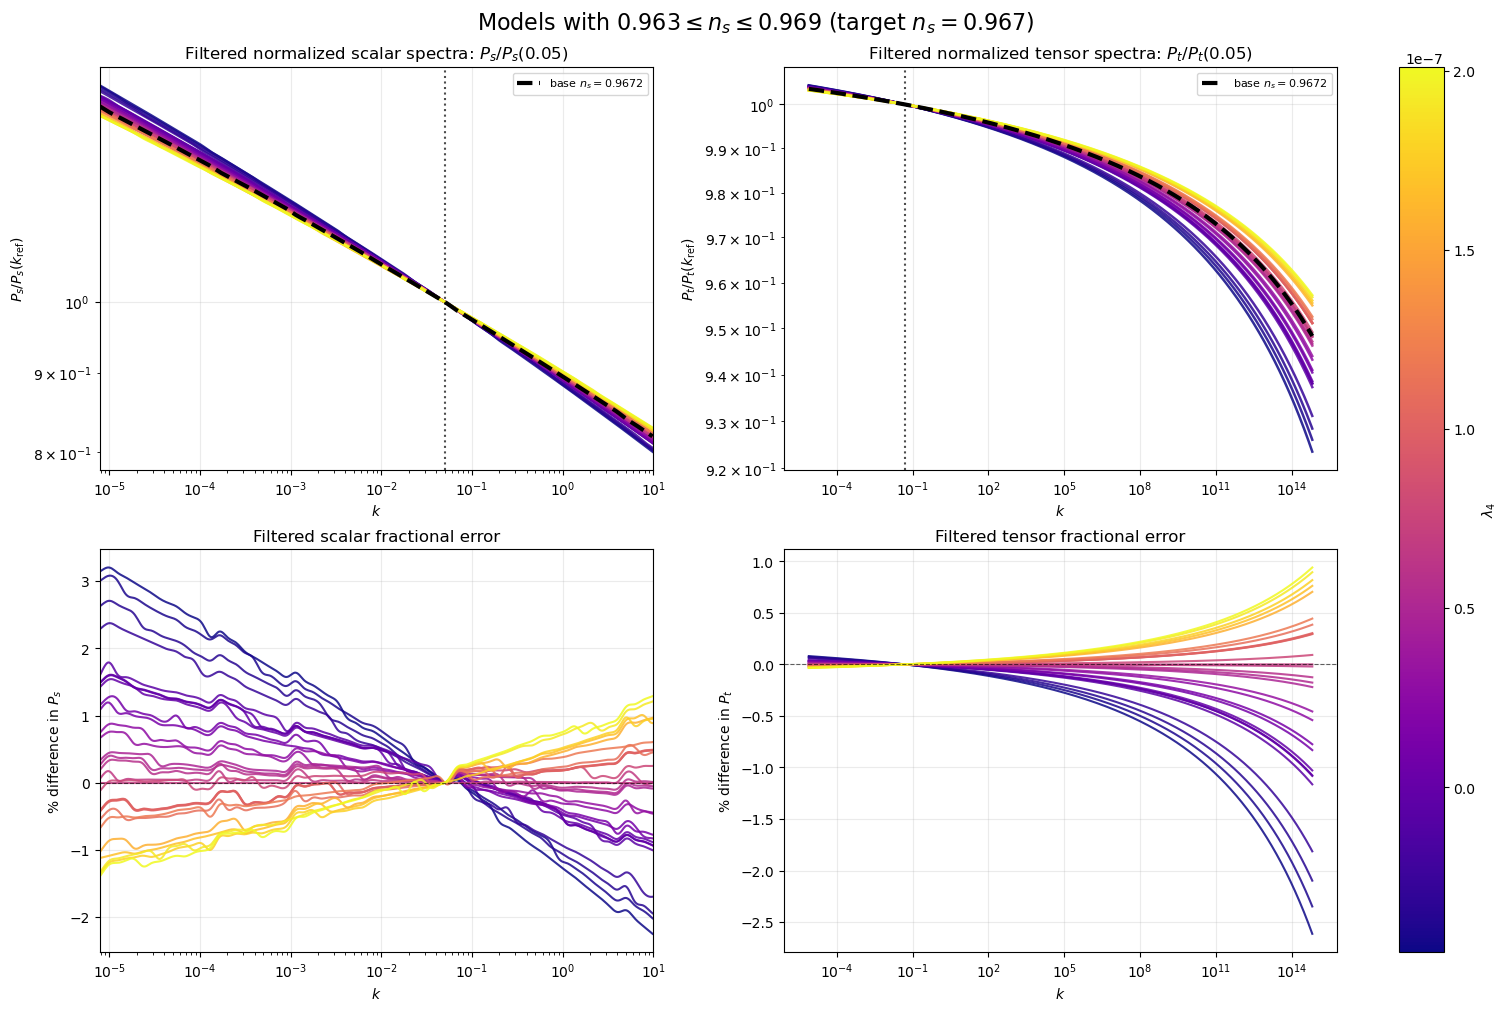

In [32]:
base_path_root = "/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests"
lam4_values = get_param_values_from_dirs(7, "lam4", base_path_root)

stats_df, kept_df = plot_filtered_spectra_by_ns(
    NEQS=7,
    lamX_values=lam4_values,
    baseX= 6.87065e-8,
    base_path_root="/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests",
    ns_min=0.963,
    ns_max=0.969,
    ns_target=0.967,
    k_ref=0.05,
    k_max_scalar=10.0,
    save_name="neqs7_lam4_filtered_ns_spectra.png"
)

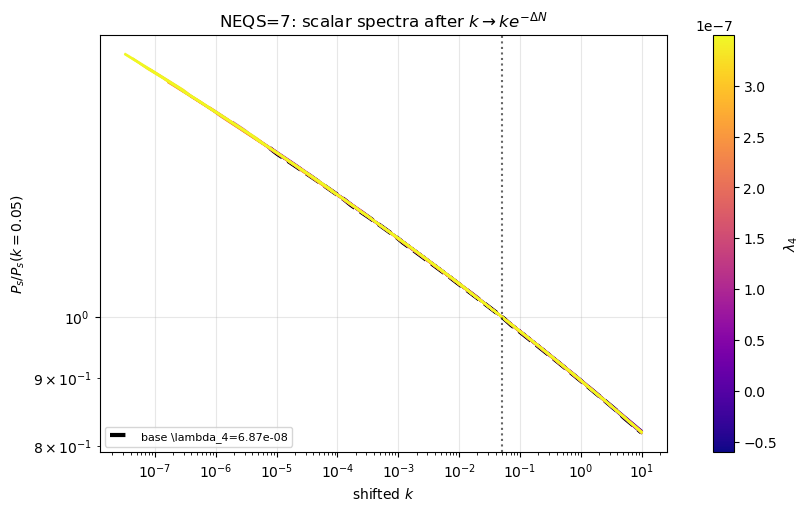

In [33]:
kshift7_df_scalar = plot_k_shift_equivalence_scan(
    NEQS=7,
    lamX_values=lam4_values,
    baseX=6.87065e-8,
    base_path_root=base_path_root,
    k_norm=0.05,
    k_max_scalar=10.0,
    save_name="neqs7_lam4_all_kshifted_scalar.png",
)

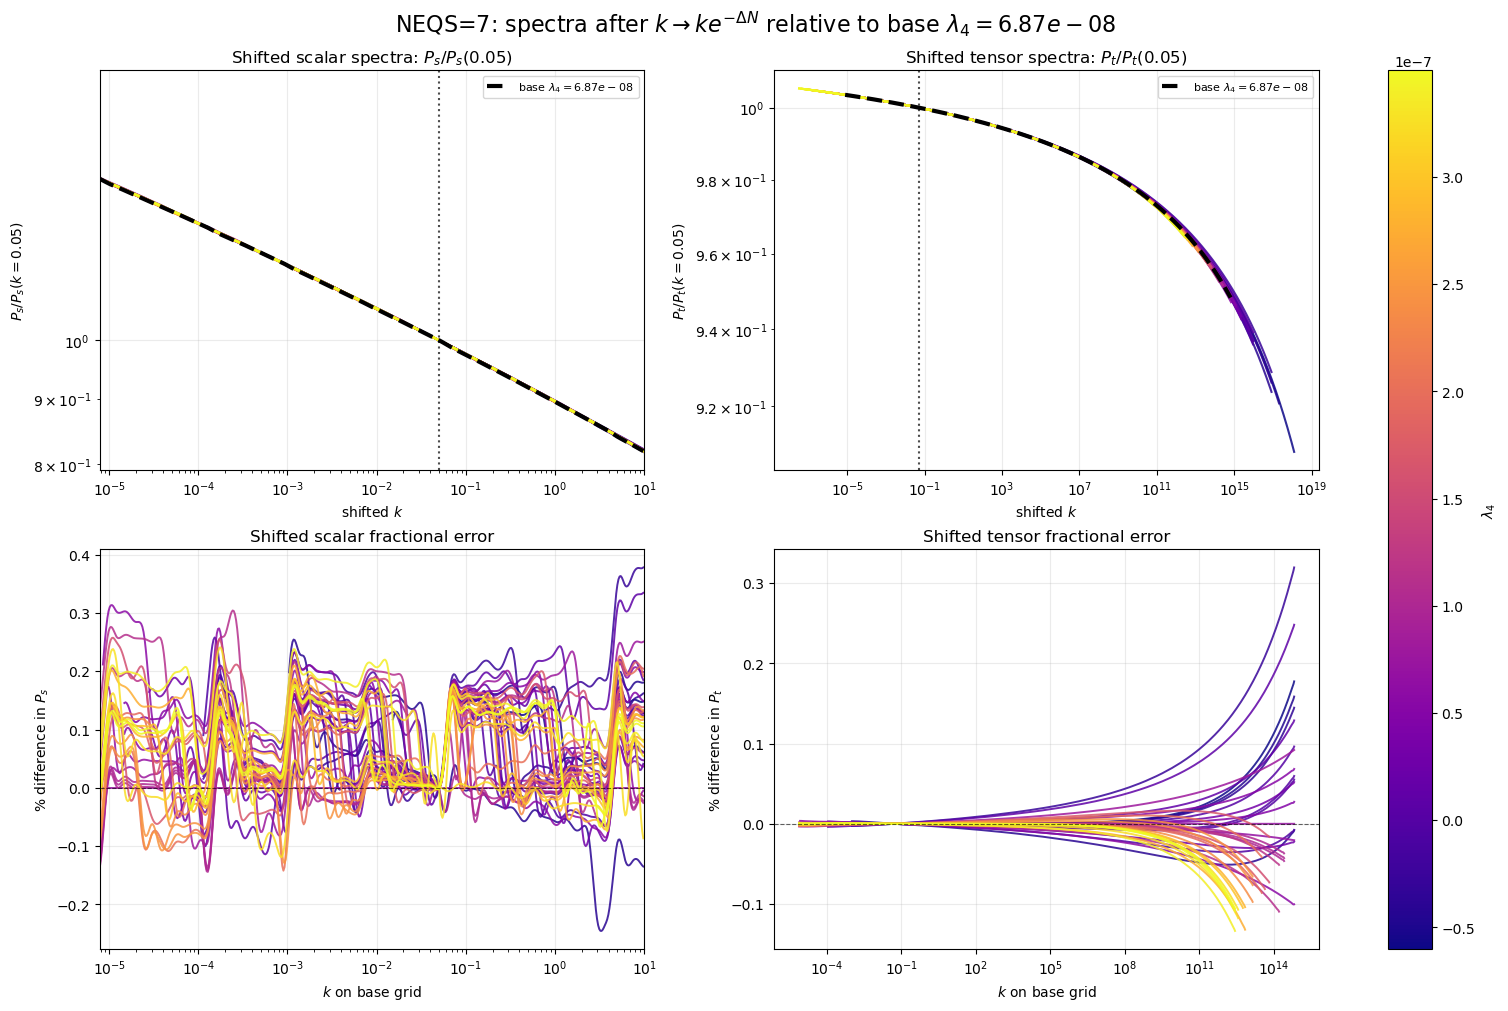


=== Shifted spectra fractional-error summary ===
         lam4  deltaN_from_base  mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct
-6.014230e-08         -7.564990      0.092615     0.172078      0.019255     0.177553
-4.595628e-08         -5.770491      0.129540     0.199254      0.016404     0.158623
-4.105247e-08         -4.869607     -0.004081     0.254241     -0.022420     0.051018
-3.562833e-08         -4.869607      0.063945     0.180646      0.014595     0.144766
-2.835396e-08         -4.869607      0.128069     0.377902      0.057258     0.319608
-5.952929e-09         -2.673499      0.090411     0.257827     -0.014678     0.035390
-2.418550e-09         -2.673499      0.066659     0.193788     -0.000317     0.055209
-2.163669e-09         -2.673499      0.061649     0.189519      0.000693     0.059613
 0.000000e+00         -2.673499      0.054625     0.186841      0.009128     0.096362
 9.679052e-09         -2.673499      0.104692     0.334349      0.044034     0.248156
 1.2

In [34]:
kshift7_df = plot_k_shift_equivalence_scan_2x2(
    NEQS=7,
    lamX_values=lam4_values,
    baseX=6.87065e-8,
    base_path_root=base_path_root,
    k_norm=0.05,
    k_max_scalar=10.0,
    save_name="neqs7_lam4_all_kshifted_spectra_2x2.png",
)


## LAM5


Summary for NEQS=8, parameter=lam5
Total models found: 40
Parameter range: -8.560e-07 to 0.000e+00


=== All models summary ===
Total loaded: 40
Base ns: 0.969485
Models in ns window [0.963, 0.969]: 25

=== Filtered models by ns cut ===
         lamX       ns  delta_ns_from_base  mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct
-7.315125e-07 0.963452           -0.006033      1.197602     4.727883      0.566989     2.366584
-7.078250e-07 0.964063           -0.005422      0.964247     4.183459      0.564308     2.356593
-7.026396e-07 0.964196           -0.005290      0.943234     4.046624      0.563707     2.354348
-6.983146e-07 0.964306           -0.005180      0.939548     3.942357      0.563201     2.352460
-6.938809e-07 0.964418           -0.005067      0.924953     3.829291      0.562680     2.350509
-6.601490e-07 0.965259           -0.004227      0.823559     3.219868      0.558582     2.335120
-6.593038e-07 0.965279           -0.004206      0.819530     3.199477      0.558476

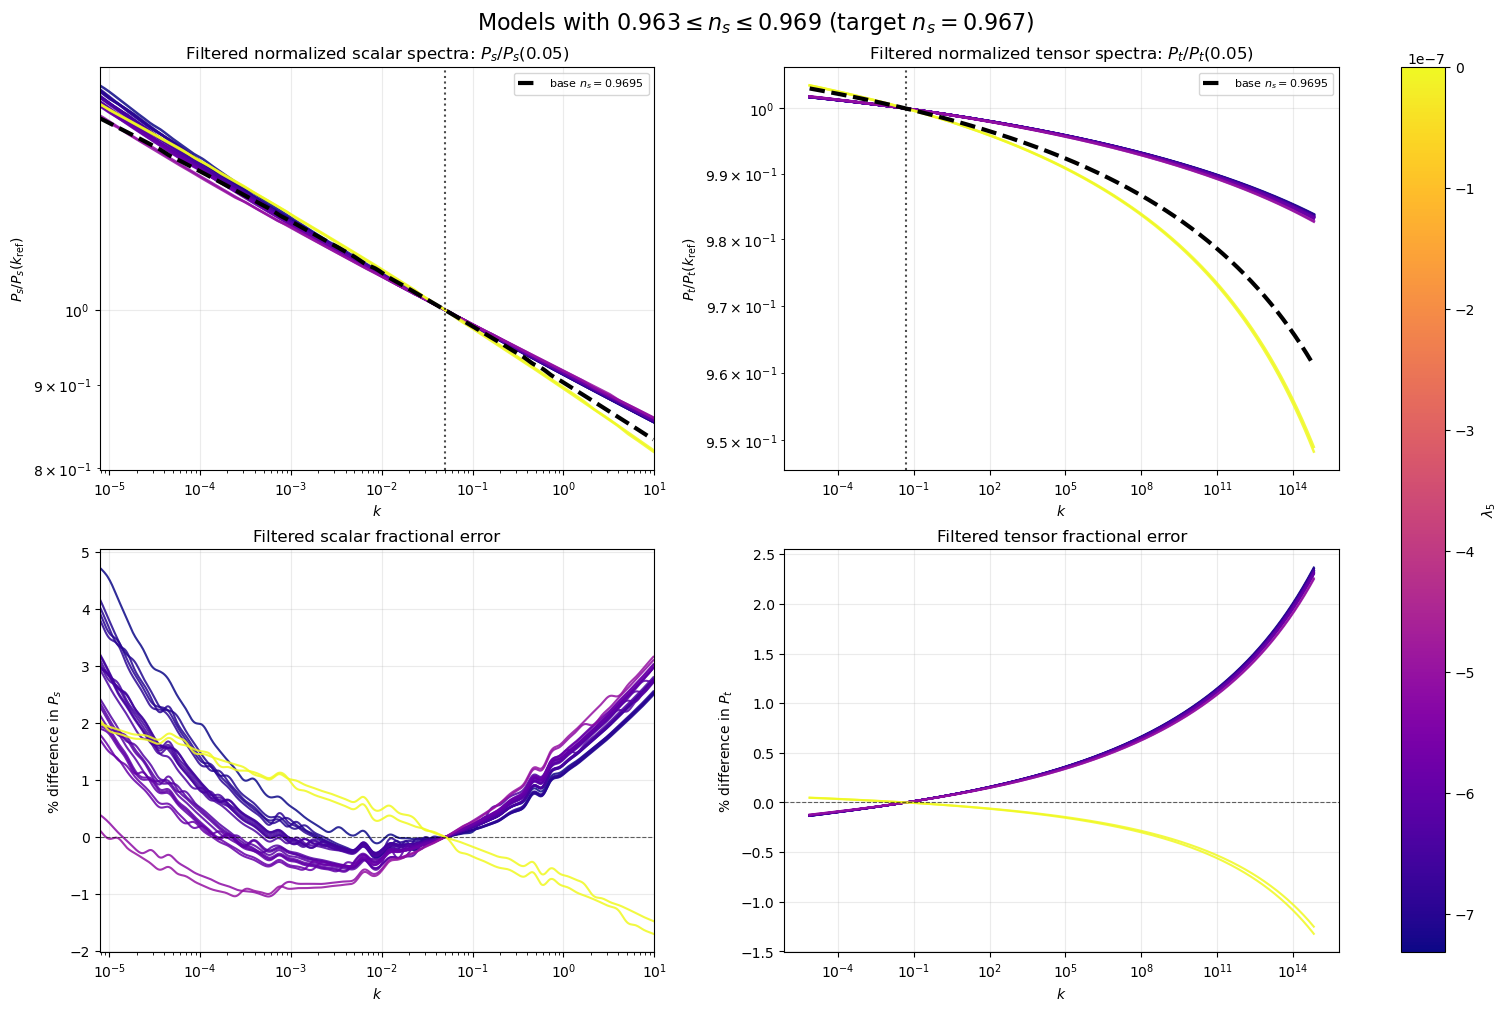

In [35]:
base_path_root = "/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests"
lam5_values = get_param_values_from_dirs(8, "lam5", base_path_root)

stats_df, kept_df = plot_filtered_spectra_by_ns(
    NEQS=8,
    lamX_values=lam5_values,
    baseX= -8.92461e-9,
    base_path_root="/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests",
    ns_min=0.963,
    ns_max=0.969,
    ns_target=0.967,
    k_ref=0.05,
    k_max_scalar=10.0,
    save_name="neqs8_lam5_filtered_ns_spectra.png"
)


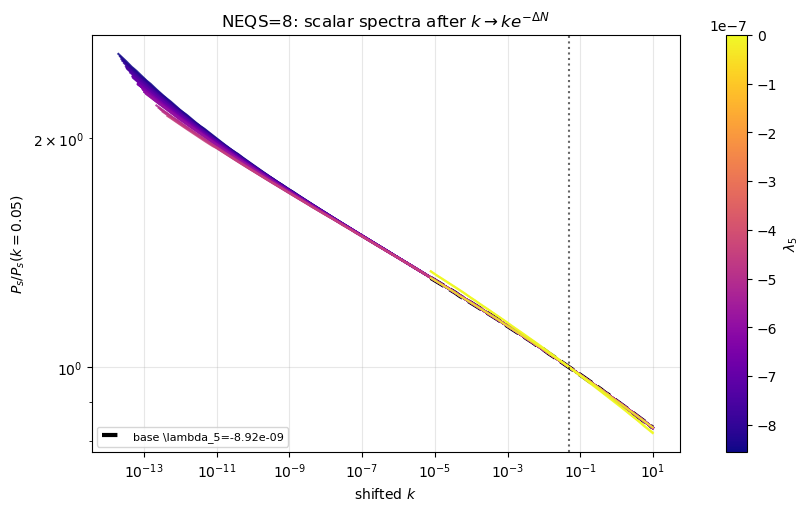

In [36]:
kshift8_df_scalar = plot_k_shift_equivalence_scan(
    NEQS=8,
    lamX_values=lam5_values,
    baseX=-8.92461e-9,
    base_path_root=base_path_root,
    k_norm=0.05,
    k_max_scalar=10.0,
    save_name="neqs8_lam5_all_kshifted_scalar.png",
)



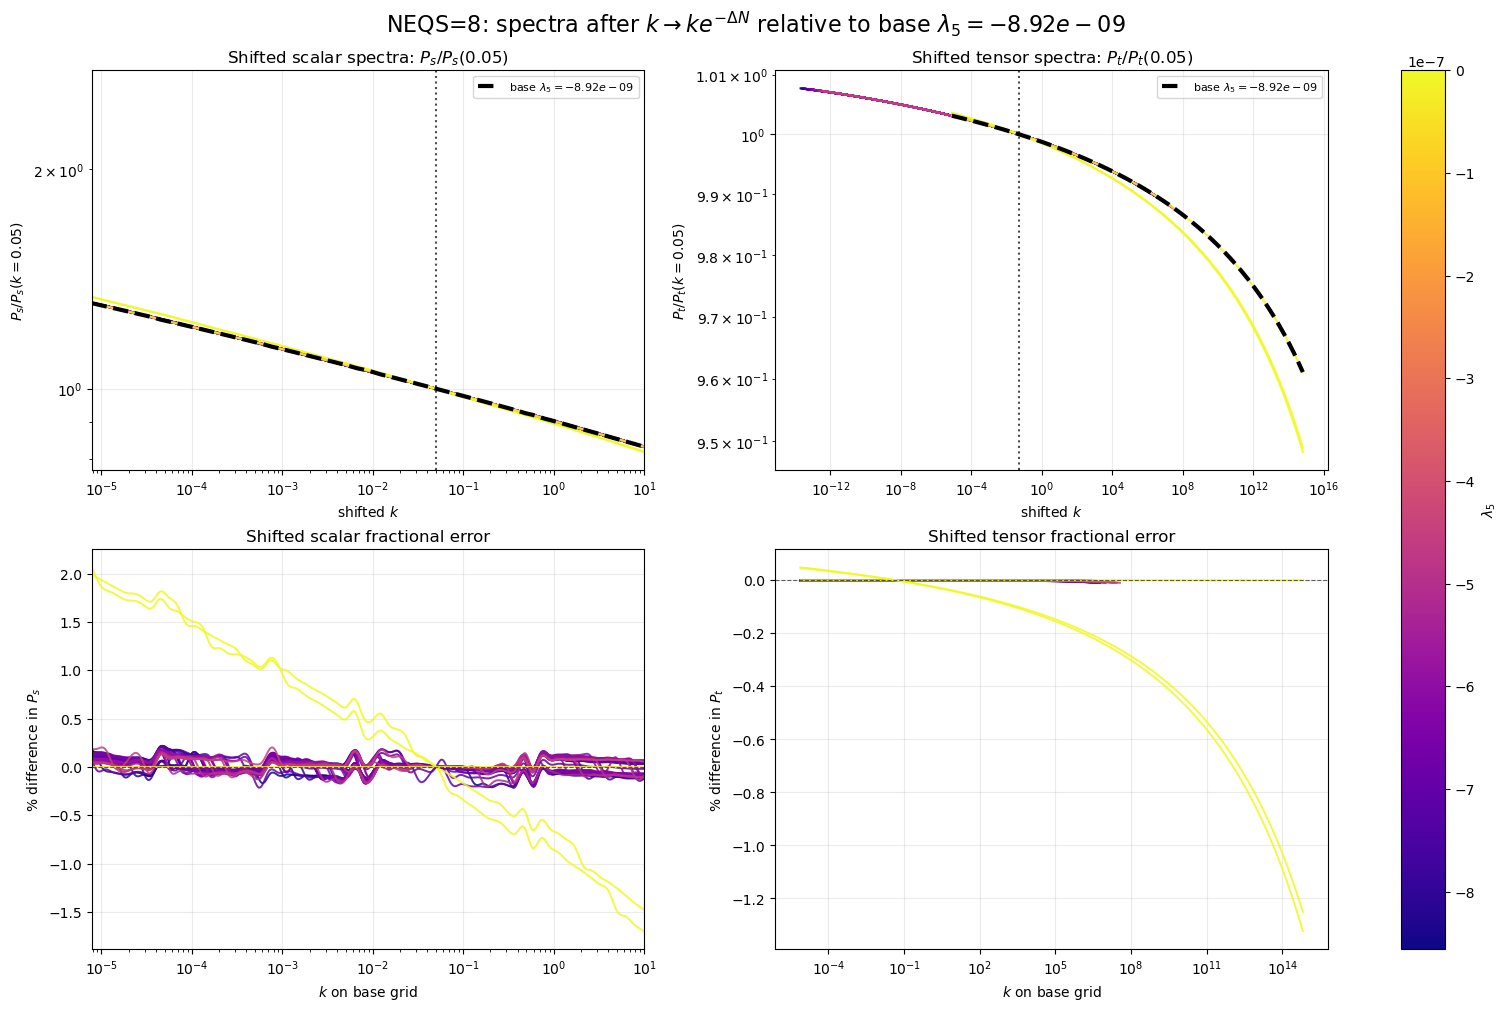


=== Shifted spectra fractional-error summary ===
         lam5  deltaN_from_base  mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct
-8.560253e-07         19.779945     -0.057157     0.210259     -0.000426     0.005183
-8.372135e-07         19.674367     -0.033600     0.217054     -0.000429     0.005206
-8.215964e-07         19.584812     -0.027949     0.208464     -0.000438     0.005306
-8.107768e-07         19.521714     -0.010410     0.145841     -0.000453     0.005516
-7.930381e-07         19.416334      0.003293     0.170638     -0.000460     0.005540
-7.738834e-07         19.299735      0.018378     0.214543     -0.000473     0.005682
-7.638593e-07         19.237508      0.028630     0.205082     -0.000479     0.005739
-7.634459e-07         19.237508      0.028701     0.205836     -0.000505     0.005849
-7.599305e-07         19.237508      0.034887     0.212503     -0.000723     0.006790
-7.572777e-07         19.237508      0.035757     0.217440     -0.000888     0.007504
-7.4

In [37]:
kshift7_df = plot_k_shift_equivalence_scan_2x2(
    NEQS=8,
    lamX_values=lam5_values,
    baseX=-8.92461e-9,
    base_path_root=base_path_root,
    k_norm=0.05,
    k_max_scalar=10.0,
    save_name="neqs8_lam5_all_kshifted_spectra_2x2.png",
)

## LAM6/NEQS = 9


Summary for NEQS=9, parameter=lam6
Total models found: 5
Parameter range: 0.000e+00 to 6.746e-10


=== All models summary ===
Total loaded: 5
Base ns: 0.970677
Models in ns window [0.963, 0.974]: 5

=== Filtered models by ns cut ===
        lamX       ns  delta_ns_from_base  mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct
0.000000e+00 0.969485           -0.001192      0.183985     1.080002     -0.125491     0.567393
6.100000e-10 0.970677            0.000000      0.000000     0.000000      0.000000     0.000000
6.246441e-10 0.970696            0.000019     -0.012132     0.167657      0.001875     0.008275
6.408290e-10 0.970717            0.000040     -0.025880     0.183938      0.003909     0.017257
6.745568e-10 0.970759            0.000081     -0.059707     0.243082      0.008058     0.035526

=== Error shrink check (in percentages) ===
All models:
      mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct
mean      0.017253     0.334936     -0.022330     0.125690
max       0.183

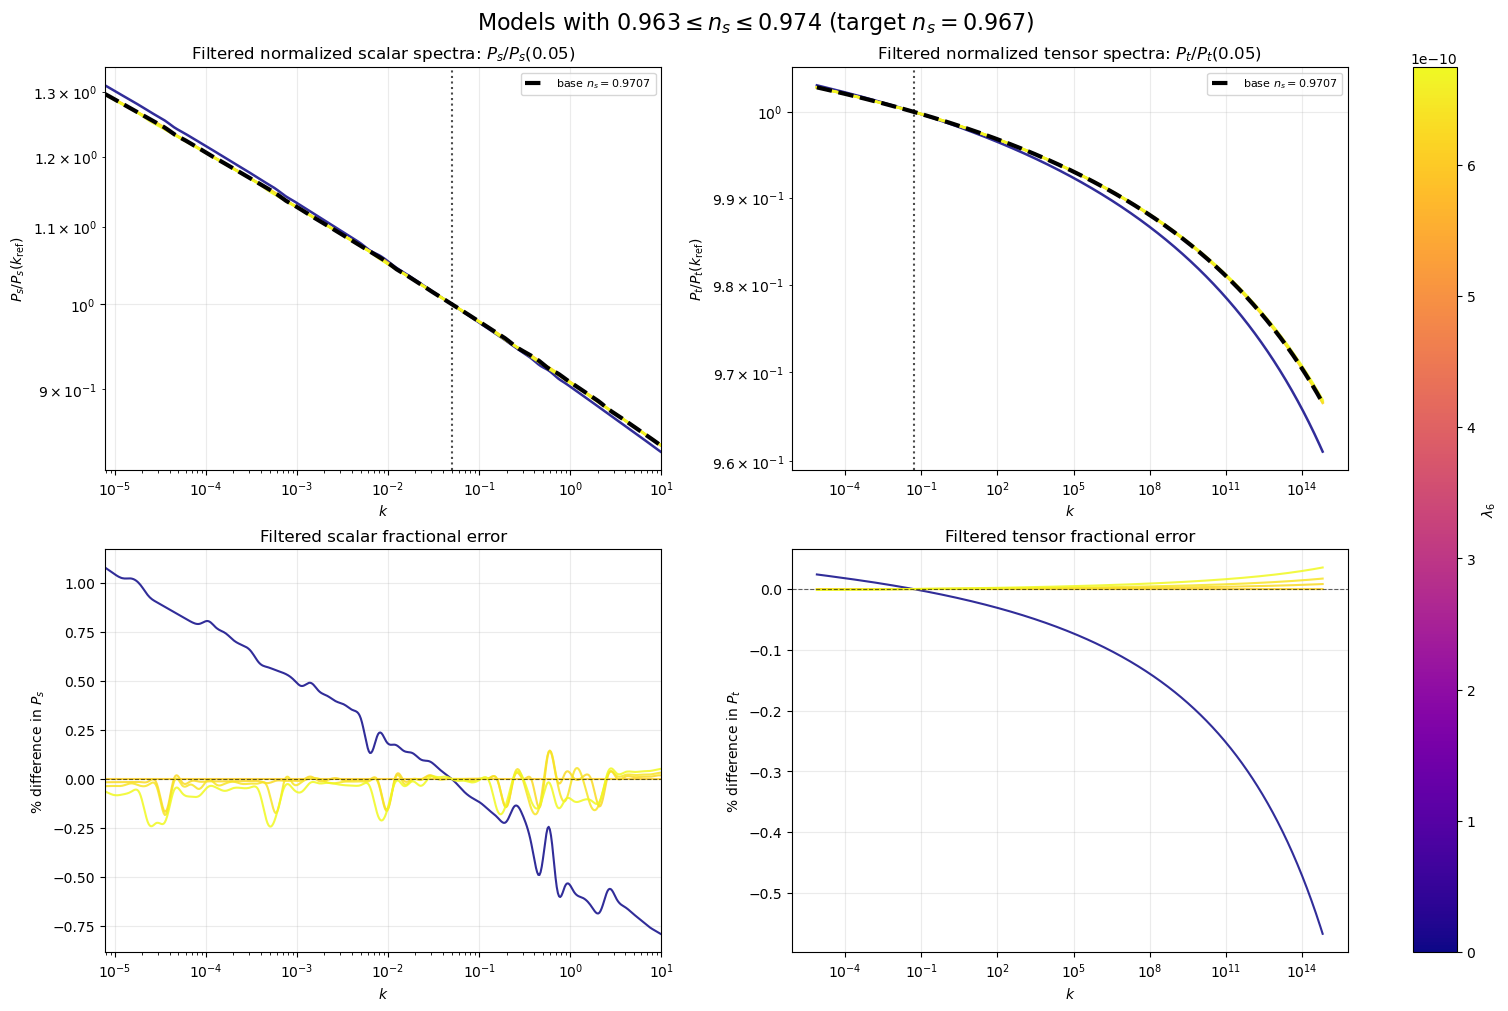

In [15]:
base_path_root = "/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests"
lam6_values = get_param_values_from_dirs(9, "lam6", base_path_root)

stats_df, kept_df = plot_filtered_spectra_by_ns(
    NEQS=9,
    lamX_values=lam6_values,
    baseX= 6.1e-10,
    base_path_root="/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests",
    ns_min=0.963,
    ns_max=0.974,
    ns_target=0.967,
    k_ref=0.05,
    k_max_scalar=10.0,
    save_name="neqs9_lam6_filtered_ns_spectra.png"
)

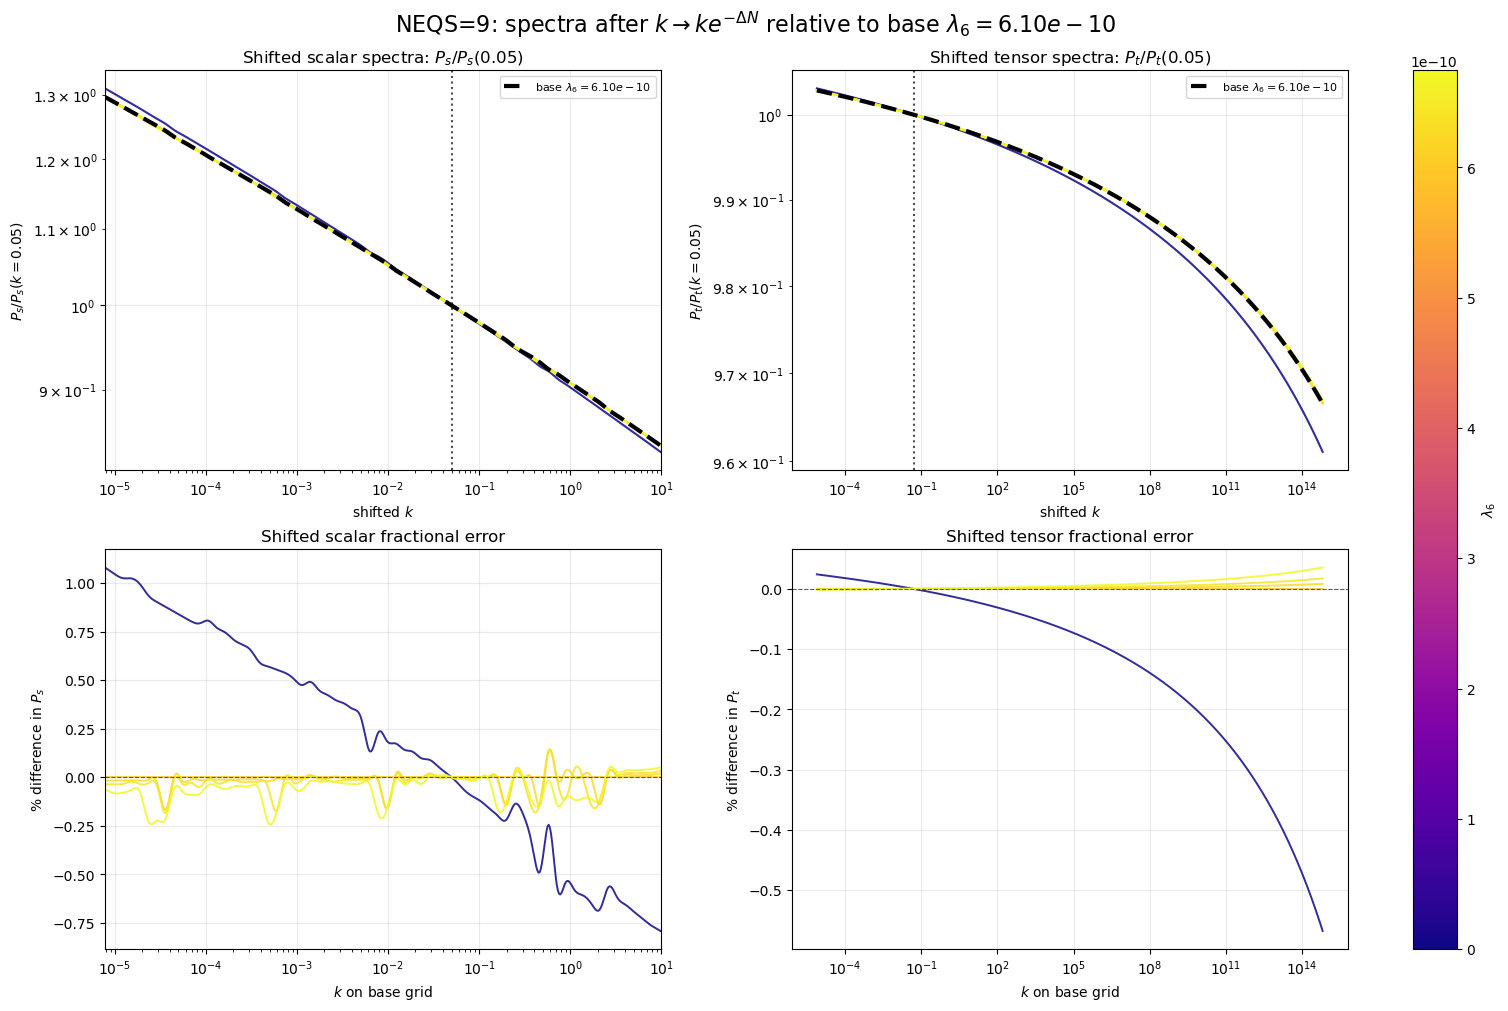


=== Shifted spectra fractional-error summary ===
        lam6  deltaN_from_base  mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct
0.000000e+00               0.0      0.183985     1.080002     -0.125491     0.567393
6.100000e-10               0.0      0.000000     0.000000      0.000000     0.000000
6.246441e-10               0.0     -0.012132     0.167657      0.001875     0.008275
6.408290e-10               0.0     -0.025880     0.183938      0.003909     0.017257
6.745568e-10               0.0     -0.059707     0.243082      0.008058     0.035526


In [16]:
kshift7_df = plot_k_shift_equivalence_scan_2x2(
    NEQS=9,
    lamX_values=lam6_values,
    baseX=6.1e-10,
    base_path_root=base_path_root,
    k_norm=0.05,
    k_max_scalar=10.0,
    save_name="neqs6_lam6_all_kshifted_spectra_2x2.png",
)

## Compare all NEQs 6-8 PS

Across neqs 6-8 I am comparing all of them to neqs6 base. I find delaN, shifted spectrum and normalizes at pivot and overlay shifted spectra on top of neqs=6 base spec.

In [23]:
def plot_all_neqs_kshift_to_lam3_base(
    base_path_root,
    lam_values_by_neqs,
    ref_NEQS=6,
    ref_param="lam3",
    ref_value=-4.6097100000e-6,
    k_norm=0.05,
    k_max_scalar=10.0,
    skip_zero=True,
    zero_tol=1e-30,
    save_name=None,
):


#     colors_by_neqs = {
#         6: "green",
#         7: "blue",
#         8: "orange",
#     }
    
    
#     colors_by_neqs = {
#     5: "pink",
#     6: "turquoise",
#     7: "plum",
#     8: "mediumslateblue",
        
# }
    
    colors_by_neqs = {
    5: "pink",
    6: "turquoise",
    7: "plum",
    9: "blue",
        
}


    def folder_for(NEQS, param_name, value):
        val_str = f"{value:.10e}"
        return os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"{param_name}_{val_str}",
        )

    def load_scalar_spec(NEQS, param_name, value):
        folder = folder_for(NEQS, param_name, value)
        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))

        k = s[:, 0]
        Ps = np.abs(s[:, 1])

        order = np.argsort(k)
        return k[order], Ps[order]

    def get_original_N_end(NEQS, param_name, value):
        summary_file = os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"neqs{NEQS}_summary.csv",
        )

        summary_df = pd.read_csv(summary_file)

        matches = summary_df.loc[
            np.isclose(summary_df[param_name], value)
        ]

        if len(matches) == 0:
            raise ValueError(
                f"No summary row found for NEQS={NEQS}, "
                f"{param_name}={value:.10e}"
            )

        return float(matches.iloc[0]["original_N_end"])

    # -------------------------------------------------
    # Reference: NEQS=6 lam3 base
    # -------------------------------------------------

    ref_N_end = get_original_N_end(
        ref_NEQS,
        ref_param,
        ref_value,
    )

    k_ref_grid, Ps_ref = load_scalar_spec(
        ref_NEQS,
        ref_param,
        ref_value,
    )

    Ps_ref_norm = Ps_ref / np.interp(
        k_norm,
        k_ref_grid,
        Ps_ref,
    )

    mask_ref = k_ref_grid <= k_max_scalar

    plt.figure(figsize=(8, 5))

    plt.loglog(
        k_ref_grid[mask_ref],
        Ps_ref_norm[mask_ref],
        color="black",
        lw=3,
        ls="-",
        label=rf"NEQS={ref_NEQS} base",
    )

    rows = []

    # -------------------------------------------------
    # Loop over all NEQS scans
    # -------------------------------------------------

    for NEQS, lam_values in lam_values_by_neqs.items():

        param_name, _ = SCAN_INFO[NEQS]
        color = colors_by_neqs.get(NEQS, None)

        for item in lam_values:

            value = item[0] if isinstance(item, tuple) else item
            value = float(value)

            if skip_zero and np.isclose(value, 0.0, atol=zero_tol):
                continue

            try:
                model_N_end = get_original_N_end(
                    NEQS,
                    param_name,
                    value,
                )

                deltaN = model_N_end - ref_N_end

                k, Ps = load_scalar_spec(
                    NEQS,
                    param_name,
                    value,
                )

                k_shifted = k * np.exp(-deltaN)

                Ps_norm = Ps / np.interp(
                    k_norm,
                    k_shifted,
                    Ps,
                )

                mask = k_shifted <= k_max_scalar

                plt.loglog(
                    k_shifted[mask],
                    Ps_norm[mask],
                    color=color,
                    lw=1.2,
                    alpha=0.6,
                    ls="--",
                )

                rows.append({
                    "NEQS": NEQS,
                    "param_name": param_name,
                    "value": value,
                    "original_N_end": model_N_end,
                    "deltaN_from_NEQS6_base": deltaN,
                    "exp_minus_deltaN": np.exp(-deltaN),
                })

            except FileNotFoundError:
                print(
                    f"Missing files for NEQS={NEQS}, "
                    f"{param_name}={value:.5e}"
                )

            except ValueError as e:
                print(
                    f"Skipping NEQS={NEQS}, "
                    f"{param_name}={value:.5e}: {e}"
                )

    plt.axvline(k_norm, color="black", ls=":", alpha=0.6)

    # legend proxies
    for NEQS, color in colors_by_neqs.items():
        if NEQS in lam_values_by_neqs:
            plt.plot(
                [],
                [],
                color=color,
                ls="--",
                lw=2,
                label=rf"NEQS={NEQS} shifted models",
            )

    plt.xlabel(r"shifted $k$")
    plt.ylabel(rf"$P_s/P_s(k={k_norm})$")
    plt.title(
        rf"All lam3/lam4/lam5 models shifted to NEQS=6 base: "
        rf"$k \to k e^{{-\Delta N}}$"
    )

    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)

    if save_name is None:
        save_name = "all_neqs_lamX_shifted_to_neqs6_base_scalar.png"

#     plt.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()

    return pd.DataFrame(rows)


Summary for NEQS=5, parameter=lam2
Total models found: 40
Parameter range: 2.738e-04 to 4.653e-03


Summary for NEQS=6, parameter=lam3
Total models found: 39
Parameter range: -5.385e-05 to -4.124e-07


Summary for NEQS=7, parameter=lam4
Total models found: 40
Parameter range: -6.014e-08 to 3.499e-07


Summary for NEQS=9, parameter=lam6
Total models found: 5
Parameter range: 6.100e-10 to 3.257e-09



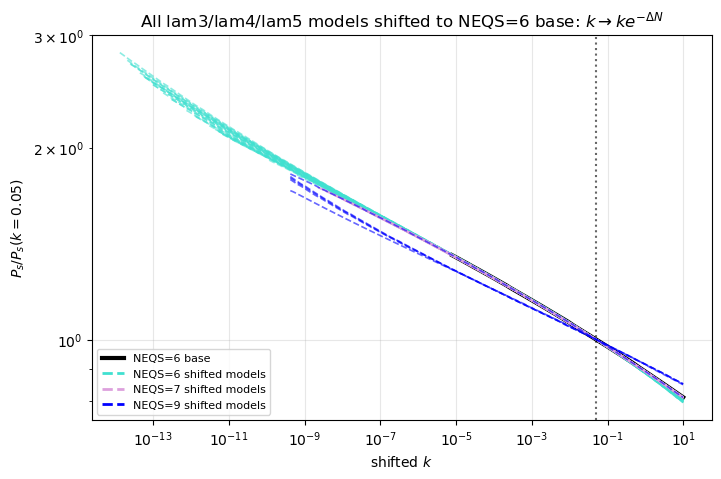

 NEQS param_name         value  original_N_end  deltaN_from_NEQS6_base  exp_minus_deltaN
    6       lam3 -5.385109e-05      959.351017            2.018744e+01      1.708851e-09
    6       lam3 -5.116411e-05      958.894825            1.973125e+01      2.696658e-09
    6       lam3 -5.020221e-05      958.725415            1.956184e+01      3.194477e-09
    6       lam3 -4.995717e-05      958.681719            1.951815e+01      3.337156e-09
    6       lam3 -4.699539e-05      958.135266            1.897169e+01      5.763659e-09
    6       lam3 -4.578533e-05      957.901692            1.873812e+01      7.280114e-09
    6       lam3 -4.554858e-05      957.855250            1.869168e+01      7.626186e-09
    6       lam3 -4.533016e-05      957.812184            1.864861e+01      7.961789e-09
    6       lam3 -4.302045e-05      957.343294            1.817972e+01      1.272469e-08
    6       lam3 -4.293461e-05      957.325373            1.816180e+01      1.295478e-08
    6       lam3 -4.0

In [24]:
# lam_values_by_neqs = {
#     5: lam2_values,
#     6: lam3_values,
#     7: lam4_values,
#     8: lam5_values,
# }
lam2_values = get_param_values_from_dirs(5, "lam2", base_path_root)
lam3_values = get_param_values_from_dirs(6, "lam3", base_path_root)
lam4_values = get_param_values_from_dirs(7, "lam4", base_path_root)
lam6_values = get_param_values_from_dirs(9, "lam6", base_path_root)

lam_values_by_neqs = {
    5: lam2_values,
    6: lam3_values,
    7: lam4_values,
    9: lam6_values,
}

lam_values_by_neqs = {
    6: lam3_values,
    7: lam4_values,
    9: lam6_values,
}

all_shift_df = plot_all_neqs_kshift_to_lam3_base(
    base_path_root=base_path_root,
    lam_values_by_neqs=lam_values_by_neqs,
    ref_NEQS=6,
    ref_param="lam3",
    ref_value=-4.6097100000e-6,
    k_norm=0.05,
    k_max_scalar=10.0,
    skip_zero=True,
    save_name="all_neqs_lamX_shifted_to_neqs6_base_scalar.png",
)

print(all_shift_df.to_string(index=False))

Now if I extend what I have done before and examine this so I am seeing:

    -Normalized shifted scalar spectra
    -Normalized shifted tensor spectra
    -Scalar fractional residual relative to ref base
    -Scalar fractional residfual relative to ref base
    
If shifting no longer contains pivot point it gets trashed and disregarded cause I cannot normalize properly.

In [29]:
def plot_all_neqs_kshift_to_lam3_base_2x2(
    base_path_root,
    lam_values_by_neqs,
    ref_NEQS=6,
    ref_param="lam3",
    ref_value=-4.6097100000e-6,
    k_norm=0.05,
    k_max_scalar=10.0,
    skip_zero=True,
    zero_tol=1e-30,
    frac_ylim=(-0.6, 0.6),
    scalar_ylim=None,
    tensor_ylim=None,
    save_name=None,
):

    # -------------------------------------------------
    # Publication-style plotting
    # -------------------------------------------------
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": [
            "Computer Modern Roman",
            "Times New Roman",
            "DejaVu Serif",
        ],
        "mathtext.fontset": "cm",
        "axes.labelsize": 16,
        "axes.titlesize": 15,
        "figure.titlesize": 18,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "legend.fontsize": 11,
        "axes.linewidth": 1.2,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
        "xtick.major.size": 6,
        "ytick.major.size": 6,
        "xtick.minor.size": 3,
        "ytick.minor.size": 3,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
    })

    colors_by_neqs = {
        5: "pink",
        6: "turquoise",
        7: "plum",
        9: "mediumslateblue",
    }

    def folder_for(NEQS, param_name, value):
        val_str = f"{value:.10e}"
        return os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"{param_name}_{val_str}",
        )

    def load_specs_local(NEQS, param_name, value):
        folder = folder_for(NEQS, param_name, value)

        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

        k_s = s[:, 0]
        Ps = np.abs(s[:, 1])

        k_t = t[:, 0]
        Pt = np.abs(t[:, 1])

        k_s, Ps = prepare_increasing(k_s, Ps)
        k_t, Pt = prepare_increasing(k_t, Pt)

        return k_s, Ps, k_t, Pt

    def get_original_N_end(NEQS, param_name, value):
        summary_file = os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"neqs{NEQS}_summary.csv",
        )

        summary_df = pd.read_csv(summary_file)

        matches = summary_df.loc[
            np.isclose(summary_df[param_name], value)
        ]

        if len(matches) == 0:
            raise ValueError(
                f"No summary row found for "
                f"NEQS={NEQS}, "
                f"{param_name}={value:.10e}"
            )

        return float(matches.iloc[0]["original_N_end"])

    def normalize_at_k(k, P, k_ref):
        k, P = prepare_increasing(k, P)

        if not (k.min() <= k_ref <= k.max()):
            raise ValueError(
                f"k_ref={k_ref} outside shifted k range "
                f"[{k.min():.3e}, {k.max():.3e}]"
            )

        P_ref = np.interp(k_ref, k, P)

        if np.abs(P_ref) < 1e-30:
            raise ValueError(
                f"Reference spectrum too small at k={k_ref}"
            )

        return k, P / P_ref

    def frac_on_ref_grid(
        k_ref_grid,
        P_ref_norm,
        k_cmp,
        P_cmp_norm,
        kmax=None,
    ):

        k_ref_grid, P_ref_norm = prepare_increasing(
            k_ref_grid,
            P_ref_norm,
        )

        k_cmp, P_cmp_norm = prepare_increasing(
            k_cmp,
            P_cmp_norm,
        )

        xmin = max(k_ref_grid.min(), k_cmp.min())
        xmax = min(k_ref_grid.max(), k_cmp.max())

        if kmax is not None:
            xmax = min(xmax, kmax)

        mask = (
            (k_ref_grid >= xmin)
            &
            (k_ref_grid <= xmax)
        )

        k_use = k_ref_grid[mask]
        P_ref_use = P_ref_norm[mask]

        P_cmp_interp = np.interp(
            k_use,
            k_cmp,
            P_cmp_norm,
        )

        frac = (P_cmp_interp - P_ref_use) / P_ref_use

        return k_use, frac

    # -------------------------------------------------
    # Reference: NEQS=6 lam3 base
    # -------------------------------------------------

    ref_N_end = get_original_N_end(
        ref_NEQS,
        ref_param,
        ref_value,
    )

    k_s_ref_raw, Ps_ref_raw, k_t_ref_raw, Pt_ref_raw = load_specs_local(
        ref_NEQS,
        ref_param,
        ref_value,
    )

    k_s_ref, Ps_ref_norm = normalize_at_k(
        k_s_ref_raw,
        Ps_ref_raw,
        k_norm,
    )

    k_t_ref, Pt_ref_norm = normalize_at_k(
        k_t_ref_raw,
        Pt_ref_raw,
        k_norm,
    )

    # -------------------------------------------------
    # Figure
    # -------------------------------------------------

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(13.5, 9.5),
        constrained_layout=True,
    )

    ax_ps, ax_pt = axes[0]
    ax_ps_err, ax_pt_err = axes[1]

    # -------------------------------------------------
    # Reference overlays
    # -------------------------------------------------

    mask_ref_s = k_s_ref <= k_max_scalar

    ax_ps.loglog(
        k_s_ref[mask_ref_s],
        Ps_ref_norm[mask_ref_s],
        color="black",
        lw=2.4,
        ls="-",
        label=rf"NEQS={ref_NEQS} reference",
    )

    ax_pt.loglog(
        k_t_ref,
        Pt_ref_norm,
        color="black",
        lw=2.4,
        ls="-",
        label=rf"NEQS={ref_NEQS} reference",
    )

    rows = []

    # -------------------------------------------------
    # Loop over all NEQS scans
    # -------------------------------------------------

    for NEQS, lam_values in lam_values_by_neqs.items():

        param_name, _ = SCAN_INFO[NEQS]
        color = colors_by_neqs.get(NEQS, None)

        for item in lam_values:

            value = item[0] if isinstance(item, tuple) else item
            value = float(value)

            if skip_zero and np.isclose(value, 0.0, atol=zero_tol):
                continue

            try:
                model_N_end = get_original_N_end(
                    NEQS,
                    param_name,
                    value,
                )

                deltaN = model_N_end - ref_N_end

                k_s_raw, Ps_raw, k_t_raw, Pt_raw = load_specs_local(
                    NEQS,
                    param_name,
                    value,
                )

                k_s_shifted = k_s_raw * np.exp(-deltaN)
                k_t_shifted = k_t_raw * np.exp(-deltaN)

                k_s, Ps_norm = normalize_at_k(
                    k_s_shifted,
                    Ps_raw,
                    k_norm,
                )

                k_t, Pt_norm = normalize_at_k(
                    k_t_shifted,
                    Pt_raw,
                    k_norm,
                )

                # fractional errors
                k_ps_err, frac_ps = frac_on_ref_grid(
                    k_s_ref,
                    Ps_ref_norm,
                    k_s,
                    Ps_norm,
                    kmax=k_max_scalar,
                )

                k_pt_err, frac_pt = frac_on_ref_grid(
                    k_t_ref,
                    Pt_ref_norm,
                    k_t,
                    Pt_norm,
                    kmax=None,
                )

                mask_s = k_s <= k_max_scalar

                # scalar spectra
                ax_ps.loglog(
                    k_s[mask_s],
                    Ps_norm[mask_s],
                    color=color,
                    lw=1.25,
                    alpha=0.65,
                    ls="--",
                )

                # tensor spectra
                ax_pt.loglog(
                    k_t,
                    Pt_norm,
                    color=color,
                    lw=1.25,
                    alpha=0.65,
                    ls="--",
                )

                # scalar fractional error
                ax_ps_err.semilogx(
                    k_ps_err,
                    100.0 * frac_ps,
                    color=color,
                    lw=1.1,
                    alpha=0.65,
                    ls="--",
                )

                # tensor fractional error
                ax_pt_err.semilogx(
                    k_pt_err,
                    100.0 * frac_pt,
                    color=color,
                    lw=1.1,
                    alpha=0.65,
                    ls="--",
                )

                rows.append({
                    "NEQS": NEQS,
                    "param_name": param_name,
                    "value": value,

                    "original_N_end": model_N_end,
                    "deltaN_from_ref_base": deltaN,
                    "exp_minus_deltaN": np.exp(-deltaN),

                    "mean_dPs_pct": 100.0 * np.nanmean(frac_ps),
                    "max_dPs_pct": 100.0 * np.nanmax(np.abs(frac_ps)),

                    "mean_dPt_pct": 100.0 * np.nanmean(frac_pt),
                    "max_dPt_pct": 100.0 * np.nanmax(np.abs(frac_pt)),
                })

            except FileNotFoundError:
                print(
                    f"Missing files for "
                    f"NEQS={NEQS}, "
                    f"{param_name}={value:.5e}"
                )

            except ValueError as e:
                print(
                    f"Skipping "
                    f"NEQS={NEQS}, "
                    f"{param_name}={value:.5e}: {e}"
                )

    # -------------------------------------------------
    # Styling
    # -------------------------------------------------

    for ax in [ax_ps_err, ax_pt_err]:
        ax.axhline(
            0.0,
            color="black",
            ls="--",
            lw=1.0,
            alpha=0.6,
        )

    ax_ps.axvline(
        k_norm,
        color="black",
        ls=":",
        alpha=0.6,
    )

    ax_pt.axvline(
        k_norm,
        color="black",
        ls=":",
        alpha=0.6,
    )

    # legend proxies
    for NEQS, color in colors_by_neqs.items():

        if NEQS in lam_values_by_neqs:

            ax_ps.plot(
                [],
                [],
                color=color,
                ls="--",
                lw=2,
                label=rf"NEQS={NEQS}",
            )

    # -------------------------------------------------
    # Titles
    # -------------------------------------------------

    ax_ps.set_title(r"Scalar spectra")
    ax_pt.set_title(r"Tensor spectra")

    ax_ps_err.set_title(r"Scalar fractional differences")
    ax_pt_err.set_title(r"Tensor fractional differences")

    # -------------------------------------------------
    # Labels
    # -------------------------------------------------

    ax_ps.set_xlabel(r"$k$")
    ax_pt.set_xlabel(r"$k$")

    ax_ps_err.set_xlabel(r"$k$")
    ax_pt_err.set_xlabel(r"$k$")

    ax_ps.set_ylabel(rf"$P_s/P_s(k={k_norm})$")
    ax_pt.set_ylabel(rf"$P_t/P_t(k={k_norm})$")

    ax_ps_err.set_ylabel(r"$100 \times \Delta P_s/P_s \; (\%)$")
    ax_pt_err.set_ylabel(r"$100 \times \Delta P_t/P_t \; (\%)$")

    # -------------------------------------------------
    # Limits
    # -------------------------------------------------

    # Same horizontal scale for scalar spectrum and scalar residual
    ax_ps.set_xlim(
        k_s_ref.min(),
        k_max_scalar,
    )

    ax_ps_err.set_xlim(
        k_s_ref.min(),
        k_max_scalar,
    )

    # Same horizontal scale for tensor spectrum and tensor residual
    ax_pt.set_xlim(
        k_t_ref.min(),
        k_t_ref.max(),
    )

    ax_pt_err.set_xlim(
        k_t_ref.min(),
        k_t_ref.max(),
    )

    # Same vertical scale for both fractional-error plots
    ax_ps_err.set_ylim(*frac_ylim)
    ax_pt_err.set_ylim(*frac_ylim)

    # Optional fixed spectra vertical limits
    if scalar_ylim is not None:
        ax_ps.set_ylim(*scalar_ylim)

    if tensor_ylim is not None:
        ax_pt.set_ylim(*tensor_ylim)

    # -------------------------------------------------
    # Final axis styling
    # -------------------------------------------------

    for ax in axes.ravel():

        ax.minorticks_on()

        ax.grid(
            True,
            which="major",
            alpha=0.25,
            lw=0.8,
        )

        ax.grid(
            True,
            which="minor",
            alpha=0.12,
            lw=0.5,
        )

        ax.tick_params(
            which="both",
            direction="in",
            top=True,
            right=True,
        )

        handles, labels = ax.get_legend_handles_labels()

        if len(handles) > 0:

            ax.legend(
                frameon=False,
                loc="best",
                handlelength=2.6,
                borderpad=0.4,
            )

    fig.suptitle(
        rf"Spectra shifted to NEQS={ref_NEQS} reference model",
        y=1.02,
    )

    # -------------------------------------------------
    # Save
    # -------------------------------------------------

    if save_name is None:

        save_name = (
            f"all_neqs_lamX_shifted_to_neqs"
            f"{ref_NEQS}_base_spectra_2x2.png"
        )

    # plt.savefig(save_name)

    plt.show()

    stats_df = pd.DataFrame(rows)

    if not stats_df.empty:

        print("\n=== Cross-NEQS shifted spectra summary ===")

        print(
            stats_df[[
                "NEQS",
                "param_name",
                "value",
                "deltaN_from_ref_base",
                "mean_dPs_pct",
                "max_dPs_pct",
                "mean_dPt_pct",
                "max_dPt_pct",
            ]].to_string(index=False)
        )

    return stats_df

If I compare everything to neqs=6 base:

Skipping NEQS=5, lam2=2.73792e-04: k_ref=0.05 outside shifted k range [2.138e-01, 1.776e+19]
Skipping NEQS=5, lam2=2.78972e-04: k_ref=0.05 outside shifted k range [1.478e-01, 1.227e+19]
Skipping NEQS=5, lam2=2.84902e-04: k_ref=0.05 outside shifted k range [9.765e-02, 8.109e+18]
Skipping NEQS=5, lam2=2.88641e-04: k_ref=0.05 outside shifted k range [7.553e-02, 6.272e+18]
Skipping NEQS=5, lam2=2.91669e-04: k_ref=0.05 outside shifted k range [6.150e-02, 5.107e+18]


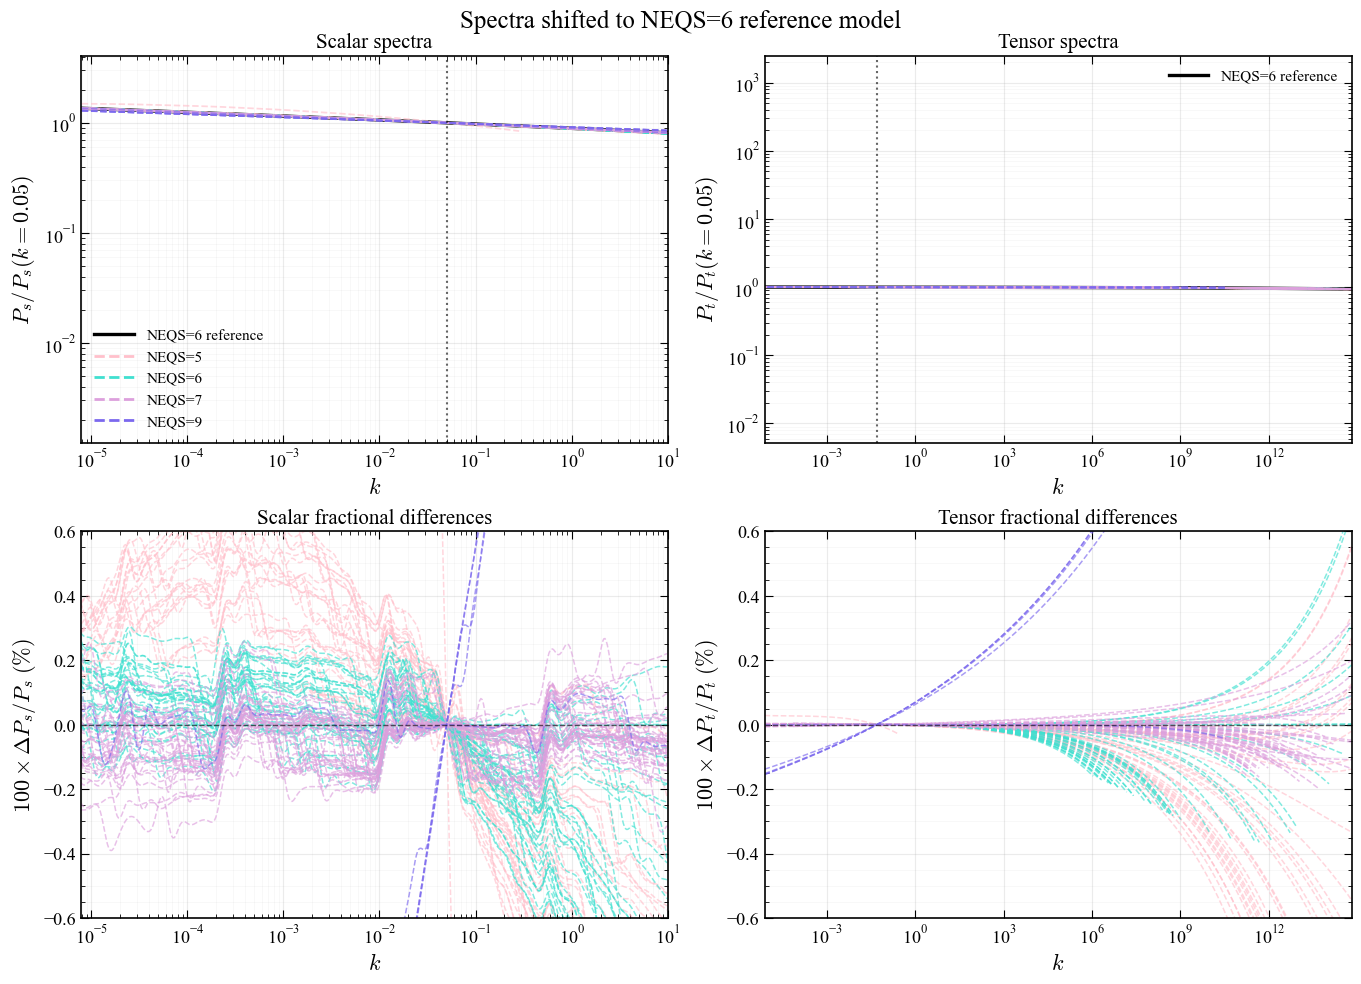


=== Cross-NEQS shifted spectra summary ===
 NEQS param_name         value  deltaN_from_ref_base  mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct
    5       lam2  3.009832e-04         -8.354988e+00      0.020931     0.164824      0.068590     0.555336
    5       lam2  3.015384e-04         -8.318725e+00      0.023772     0.169815      0.067659     0.550428
    5       lam2  3.247394e-04         -6.861771e+00     -0.070845     0.223393      0.029623     0.339949
    5       lam2  3.322299e-04         -6.414345e+00     -0.099534     0.379806      0.017615     0.269338
    5       lam2  3.338463e-04         -6.319176e+00     -0.106870     0.413679      0.015038     0.253928
    5       lam2  3.468609e-04         -5.570040e+00     -0.143637     0.524930     -0.005519     0.127657
    5       lam2  3.478838e-04         -5.512418e+00     -0.144130     0.522458     -0.007122     0.117553
    5       lam2  3.514106e-04         -5.315102e+00     -0.160448     0.561702     -0.012630     0.

In [30]:
lam_values_by_neqs = {
    5: lam2_values,
    6: lam3_values,
    7: lam4_values,
    9: lam6_values,
}

all_shift_2x2_df = plot_all_neqs_kshift_to_lam3_base_2x2(
    base_path_root=base_path_root,
    lam_values_by_neqs=lam_values_by_neqs,
    ref_NEQS=6,
    ref_param="lam3",
    ref_value=-4.6097100000e-6,
    k_norm=0.05,
    k_max_scalar=10.0,
    skip_zero=True,
    save_name="all_neqs_lamX_shifted_to_neqs6_base_spectra_2x2.png",
)


If I compare everything to neqs=7 base:

Skipping NEQS=5, lam2=2.73792e-04: k_ref=0.05 outside shifted k range [3.099e+00, 2.573e+20]
Skipping NEQS=5, lam2=2.78972e-04: k_ref=0.05 outside shifted k range [2.142e+00, 1.778e+20]
Skipping NEQS=5, lam2=2.84902e-04: k_ref=0.05 outside shifted k range [1.415e+00, 1.175e+20]
Skipping NEQS=5, lam2=2.88641e-04: k_ref=0.05 outside shifted k range [1.095e+00, 9.089e+19]
Skipping NEQS=5, lam2=2.91669e-04: k_ref=0.05 outside shifted k range [8.912e-01, 7.400e+19]
Skipping NEQS=5, lam2=3.00983e-04: k_ref=0.05 outside shifted k range [4.800e-01, 3.986e+19]
Skipping NEQS=5, lam2=3.01538e-04: k_ref=0.05 outside shifted k range [4.629e-01, 3.844e+19]
Skipping NEQS=5, lam2=3.24739e-04: k_ref=0.05 outside shifted k range [1.078e-01, 8.954e+18]
Skipping NEQS=5, lam2=3.32230e-04: k_ref=0.05 outside shifted k range [6.893e-02, 5.724e+18]
Skipping NEQS=5, lam2=3.33846e-04: k_ref=0.05 outside shifted k range [6.267e-02, 5.204e+18]
Skipping NEQS=6, lam3=-5.95293e-07: k_ref=0.05 outside shifted k range

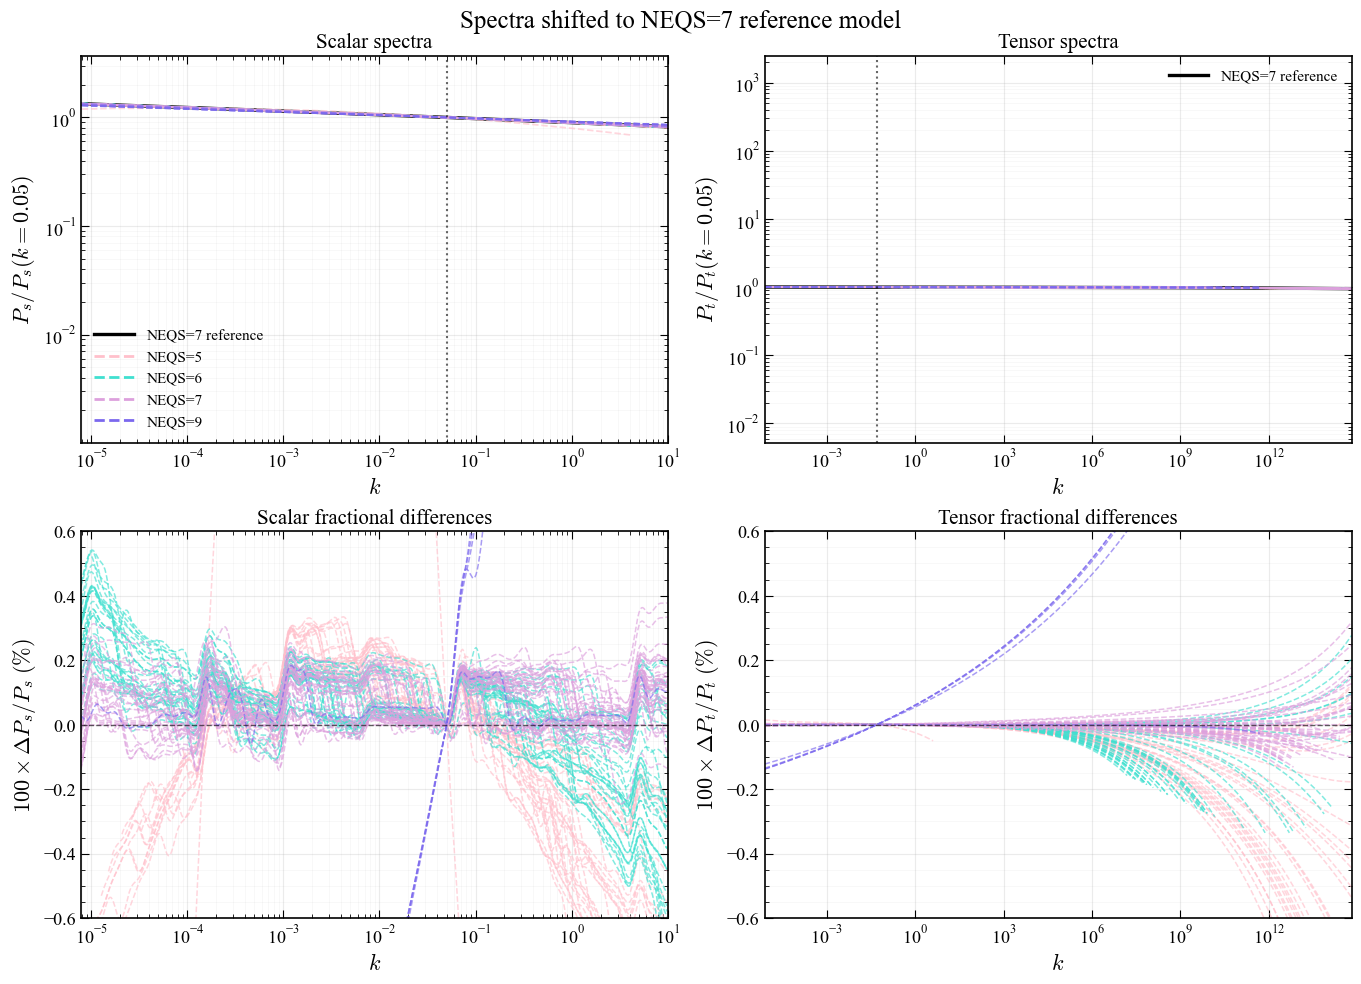


=== Cross-NEQS shifted spectra summary ===
 NEQS param_name         value  deltaN_from_ref_base  mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct
    5       lam2  3.468609e-04             -8.243538     -0.074849     0.311214     -0.001289     0.125276
    5       lam2  3.478838e-04             -8.185917     -0.082807     0.309557     -0.002411     0.118599
    5       lam2  3.514106e-04             -7.988601     -0.093672     0.332144     -0.006264     0.095446
    5       lam2  3.527820e-04             -7.912438     -0.093647     0.339749     -0.007759     0.086399
    5       lam2  3.615049e-04             -7.435197     -0.100167     0.344649     -0.017231     0.047059
    5       lam2  3.697305e-04             -6.996209     -0.006027     0.269675     -0.026066     0.070442
    5       lam2  3.728333e-04             -6.833310     -0.033734     0.313652     -0.029360     0.081327
    5       lam2  3.910163e-04             -5.906860     -0.055046     0.453917     -0.048596     0.

In [31]:
lam_values_by_neqs = {
    5: lam2_values,
    6: lam3_values,
    7: lam4_values,
    9: lam6_values,
}

all_shift_2x2_df = plot_all_neqs_kshift_to_lam3_base_2x2(
    base_path_root=base_path_root,
    lam_values_by_neqs=lam_values_by_neqs,
    ref_NEQS=7,
    ref_param="lam4",
    ref_value=6.87065e-8,
    k_norm=0.05,
    k_max_scalar=10.0,
    skip_zero=True,
    save_name="all_neqs_lamX_shifted_to_neqs7_base_spectra_2x2.png",
)



If I compare everything to neqs=8 base:

Skipping NEQS=5, lam2=2.73792e-04: k_ref=0.05 outside shifted k range [2.825e+02, 2.346e+22]
Skipping NEQS=5, lam2=2.78972e-04: k_ref=0.05 outside shifted k range [1.952e+02, 1.621e+22]
Skipping NEQS=5, lam2=2.84902e-04: k_ref=0.05 outside shifted k range [1.290e+02, 1.071e+22]
Skipping NEQS=5, lam2=2.88641e-04: k_ref=0.05 outside shifted k range [9.978e+01, 8.286e+21]
Skipping NEQS=5, lam2=2.91669e-04: k_ref=0.05 outside shifted k range [8.124e+01, 6.747e+21]
Skipping NEQS=5, lam2=3.00983e-04: k_ref=0.05 outside shifted k range [4.376e+01, 3.634e+21]
Skipping NEQS=5, lam2=3.01538e-04: k_ref=0.05 outside shifted k range [4.220e+01, 3.504e+21]
Skipping NEQS=5, lam2=3.24739e-04: k_ref=0.05 outside shifted k range [9.830e+00, 8.163e+20]
Skipping NEQS=5, lam2=3.32230e-04: k_ref=0.05 outside shifted k range [6.284e+00, 5.218e+20]
Skipping NEQS=5, lam2=3.33846e-04: k_ref=0.05 outside shifted k range [5.714e+00, 4.745e+20]
Skipping NEQS=5, lam2=3.46861e-04: k_ref=0.05 outside shifted k range 

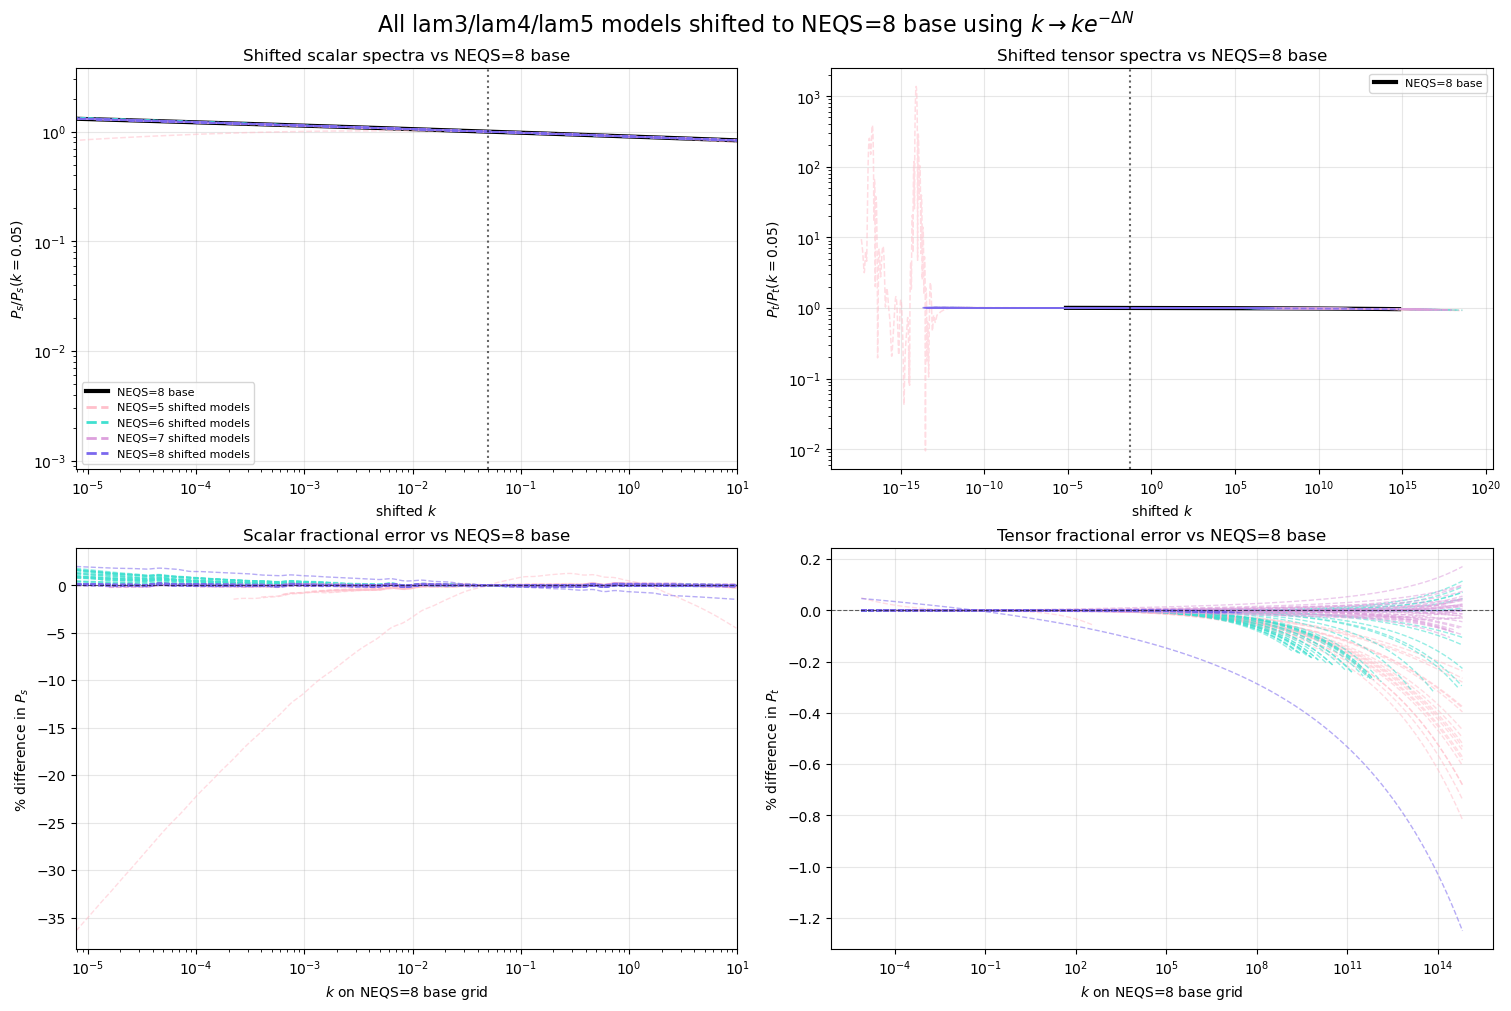


=== Cross-NEQS shifted spectra summary ===
 NEQS param_name         value  deltaN_from_ref_base  mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct
    5       lam2  4.269022e-04             -8.719940     -0.035961     0.228625     -0.050109     0.235908
    5       lam2  4.346050e-04             -8.375349      0.064993     0.228867     -0.054098     0.264643
    5       lam2  4.386324e-04             -8.197824      0.085807     0.269817     -0.056267     0.279905
    5       lam2  4.633163e-04             -7.147371      0.019716     0.249805     -0.069253     0.375475
    5       lam2  4.646192e-04             -7.093646      0.023620     0.274276     -0.069925     0.380630
    5       lam2  4.685373e-04             -6.933073      0.013808     0.273596     -0.071950     0.396184
    5       lam2  4.858729e-04             -6.240027     -0.036459     0.360999     -0.081015     0.466070
    5       lam2  4.932264e-04             -5.954286     -0.058764     0.427105     -0.084811     0.

In [43]:
lam_values_by_neqs = {
    5: lam2_values,
    6: lam3_values,
    7: lam4_values,
    8: lam5_values,
}

all_shift_2x2_df = plot_all_neqs_kshift_to_lam3_base_2x2(
    base_path_root=base_path_root,
    lam_values_by_neqs=lam_values_by_neqs,
    ref_NEQS=8,
    ref_param="lam5",
    ref_value=-8.92461e-9,
    k_norm=0.05,
    k_max_scalar=10.0,
    skip_zero=True,
    save_name="all_neqs_lamX_shifted_to_neqs8_base_spectra_2x2.png",
)

Now, I am going to apply a filter check here to see variance for models we give a fuck about:

In [46]:
def plot_all_neqs_kshift_to_ref_base_2x2_ns_filtered(
    base_path_root,
    lam_values_by_neqs,
    ref_NEQS=7,
    ref_param="lam4",
    ref_value=6.87065e-8,
    ns_min=0.963,
    ns_max=0.970,
    k_norm=0.05,
    k_max_scalar=10.0,
    skip_zero=True,
    zero_tol=1e-30,
    save_name=None,
):
 
    colors_by_neqs = {
    6: "turquoise",
    7: "plum",
    8: "mediumslateblue",
}
  
    

    def folder_for(NEQS, param_name, value):
        val_str = f"{value:.10e}"
        return os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"{param_name}_{val_str}",
        )

    def load_specs_local(NEQS, param_name, value):
        folder = folder_for(NEQS, param_name, value)

        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

        k_s, Ps = prepare_increasing(s[:, 0], np.abs(s[:, 1]))
        k_t, Pt = prepare_increasing(t[:, 0], np.abs(t[:, 1]))

        return k_s, Ps, k_t, Pt

    def load_observables(NEQS, param_name, value):
        folder = folder_for(NEQS, param_name, value)
        arr = np.loadtxt(os.path.join(folder, f"test_nr_neqs{NEQS}.dat"))
        arr = np.atleast_1d(arr)
        r, ns, alpha_s = arr[0], arr[1], arr[2]
        return r, ns, alpha_s

    def get_original_N_end(NEQS, param_name, value):
        summary_file = os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"neqs{NEQS}_summary.csv",
        )

        summary_df = pd.read_csv(summary_file)

        matches = summary_df.loc[
            np.isclose(summary_df[param_name], value)
        ]

        if len(matches) == 0:
            raise ValueError(
                f"No summary row found for NEQS={NEQS}, "
                f"{param_name}={value:.10e}"
            )

        return float(matches.iloc[0]["original_N_end"])

    def normalize_at_k(k, P, k_ref):
        k, P = prepare_increasing(k, P)

        if not (k.min() <= k_ref <= k.max()):
            raise ValueError(
                f"k_ref={k_ref} outside shifted k range "
                f"[{k.min():.3e}, {k.max():.3e}]"
            )

        P_ref = np.interp(k_ref, k, P)

        if np.abs(P_ref) < 1e-30:
            raise ValueError(f"Reference spectrum too small at k={k_ref}")

        return k, P / P_ref

    def frac_on_ref_grid(k_ref_grid, P_ref_norm, k_cmp, P_cmp_norm, kmax=None):
        k_ref_grid, P_ref_norm = prepare_increasing(k_ref_grid, P_ref_norm)
        k_cmp, P_cmp_norm = prepare_increasing(k_cmp, P_cmp_norm)

        xmin = max(k_ref_grid.min(), k_cmp.min())
        xmax = min(k_ref_grid.max(), k_cmp.max())

        if kmax is not None:
            xmax = min(xmax, kmax)

        mask = (k_ref_grid >= xmin) & (k_ref_grid <= xmax)

        k_use = k_ref_grid[mask]
        P_ref_use = P_ref_norm[mask]
        P_cmp_interp = np.interp(k_use, k_cmp, P_cmp_norm)

        frac = (P_cmp_interp - P_ref_use) / P_ref_use

        return k_use, frac

    # Reference model
    ref_N_end = get_original_N_end(ref_NEQS, ref_param, ref_value)

    k_s_ref_raw, Ps_ref_raw, k_t_ref_raw, Pt_ref_raw = load_specs_local(
        ref_NEQS,
        ref_param,
        ref_value,
    )

    k_s_ref, Ps_ref_norm = normalize_at_k(k_s_ref_raw, Ps_ref_raw, k_norm)
    k_t_ref, Pt_ref_norm = normalize_at_k(k_t_ref_raw, Pt_ref_raw, k_norm)

    fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)

    ax_ps, ax_pt = axes[0]
    ax_ps_err, ax_pt_err = axes[1]

    mask_ref_s = k_s_ref <= k_max_scalar

    ax_ps.loglog(
        k_s_ref[mask_ref_s],
        Ps_ref_norm[mask_ref_s],
        color="black",
        lw=3,
        ls="-",
        label=rf"NEQS={ref_NEQS} base",
    )

    ax_pt.loglog(
        k_t_ref,
        Pt_ref_norm,
        color="black",
        lw=3,
        ls="-",
        label=rf"NEQS={ref_NEQS} base",
    )

    rows = []

    for NEQS, lam_values in lam_values_by_neqs.items():

        param_name, _ = SCAN_INFO[NEQS]
        color = colors_by_neqs.get(NEQS, None)

        for item in lam_values:

            value = item[0] if isinstance(item, tuple) else item
            value = float(value)

            if skip_zero and np.isclose(value, 0.0, atol=zero_tol):
                continue

            try:
                r, ns, alpha_s = load_observables(NEQS, param_name, value)

                if not (ns_min <= ns <= ns_max):
                    continue

                model_N_end = get_original_N_end(NEQS, param_name, value)
                deltaN = model_N_end - ref_N_end

                k_s_raw, Ps_raw, k_t_raw, Pt_raw = load_specs_local(
                    NEQS,
                    param_name,
                    value,
                )

                k_s_shifted = k_s_raw * np.exp(-deltaN)
                k_t_shifted = k_t_raw * np.exp(-deltaN)

                k_s, Ps_norm = normalize_at_k(k_s_shifted, Ps_raw, k_norm)
                k_t, Pt_norm = normalize_at_k(k_t_shifted, Pt_raw, k_norm)

                k_ps_err, frac_ps = frac_on_ref_grid(
                    k_s_ref,
                    Ps_ref_norm,
                    k_s,
                    Ps_norm,
                    kmax=k_max_scalar,
                )

                k_pt_err, frac_pt = frac_on_ref_grid(
                    k_t_ref,
                    Pt_ref_norm,
                    k_t,
                    Pt_norm,
                    kmax=None,
                )

                mask_s = k_s <= k_max_scalar

                ax_ps.loglog(
                    k_s[mask_s],
                    Ps_norm[mask_s],
                    color=color,
                    lw=1.1,
                    alpha=0.6,
                    ls="--",
                )

                ax_pt.loglog(
                    k_t,
                    Pt_norm,
                    color=color,
                    lw=1.1,
                    alpha=0.6,
                    ls="--",
                )

                ax_ps_err.semilogx(
                    k_ps_err,
                    100.0 * frac_ps,
                    color=color,
                    lw=1.0,
                    alpha=0.6,
                    ls="--",
                )

                ax_pt_err.semilogx(
                    k_pt_err,
                    100.0 * frac_pt,
                    color=color,
                    lw=1.0,
                    alpha=0.6,
                    ls="--",
                )

                rows.append({
                    "NEQS": NEQS,
                    "param_name": param_name,
                    "value": value,
                    "r": r,
                    "ns": ns,
                    "alpha_s": alpha_s,
                    "original_N_end": model_N_end,
                    "deltaN_from_ref_base": deltaN,
                    "mean_dPs_pct": 100.0 * np.nanmean(frac_ps),
                    "max_dPs_pct": 100.0 * np.nanmax(np.abs(frac_ps)),
                    "mean_dPt_pct": 100.0 * np.nanmean(frac_pt),
                    "max_dPt_pct": 100.0 * np.nanmax(np.abs(frac_pt)),
                })

            except FileNotFoundError:
                print(
                    f"Missing files for NEQS={NEQS}, "
                    f"{param_name}={value:.5e}"
                )

            except ValueError as e:
                print(
                    f"Skipping NEQS={NEQS}, "
                    f"{param_name}={value:.5e}: {e}"
                )

    for ax in [ax_ps_err, ax_pt_err]:
        ax.axhline(0.0, color="black", ls="--", lw=0.8, alpha=0.6)

    ax_ps.axvline(k_norm, color="black", ls=":", alpha=0.6)
    ax_pt.axvline(k_norm, color="black", ls=":", alpha=0.6)

    for NEQS, color in colors_by_neqs.items():
        if NEQS in lam_values_by_neqs:
            ax_ps.plot(
                [],
                [],
                color=color,
                ls="--",
                lw=2,
                label=rf"NEQS={NEQS}, valid $n_s$",
            )

    ax_ps.set_title(rf"Shifted scalar spectra, ${ns_min}<n_s<{ns_max}$")
    ax_pt.set_title(rf"Shifted tensor spectra, ${ns_min}<n_s<{ns_max}$")
    ax_ps_err.set_title(r"Scalar fractional error vs reference")
    ax_pt_err.set_title(r"Tensor fractional error vs reference")

    ax_ps.set_xlabel(r"shifted $k$")
    ax_pt.set_xlabel(r"shifted $k$")
    ax_ps_err.set_xlabel(r"$k$ on reference grid")
    ax_pt_err.set_xlabel(r"$k$ on reference grid")

    ax_ps.set_ylabel(rf"$P_s/P_s(k={k_norm})$")
    ax_pt.set_ylabel(rf"$P_t/P_t(k={k_norm})$")
    ax_ps_err.set_ylabel(r"% difference in $P_s$")
    ax_pt_err.set_ylabel(r"% difference in $P_t$")

    ax_ps.set_xlim(k_s_ref.min(), k_max_scalar)
    ax_ps_err.set_xlim(k_s_ref.min(), k_max_scalar)

    for ax in axes.ravel():
        ax.grid(True, alpha=0.3)

        handles, labels = ax.get_legend_handles_labels()

        if len(handles) > 0:
            ax.legend(fontsize=8)

    fig.suptitle(
        rf"All valid-$n_s$ lam3/lam4/lam5 models shifted to "
        rf"NEQS={ref_NEQS} base using $k \to k e^{{-\Delta N}}$",
        fontsize=16,
    )

    if save_name is None:
        save_name = (
            f"all_neqs_valid_ns_shifted_to_neqs{ref_NEQS}_base_spectra_2x2.png"
        )

    plt.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()

    stats_df = pd.DataFrame(rows)

    if not stats_df.empty:
        print("\n=== Valid-ns cross-NEQS shifted spectra summary ===")
        print(
            stats_df[[
                "NEQS",
                "param_name",
                "value",
                "ns",
                "deltaN_from_ref_base",
                "mean_dPs_pct",
                "max_dPs_pct",
                "mean_dPt_pct",
                "max_dPt_pct",
            ]].to_string(index=False)
        )

    return stats_df

NEQS=7 CHECK:

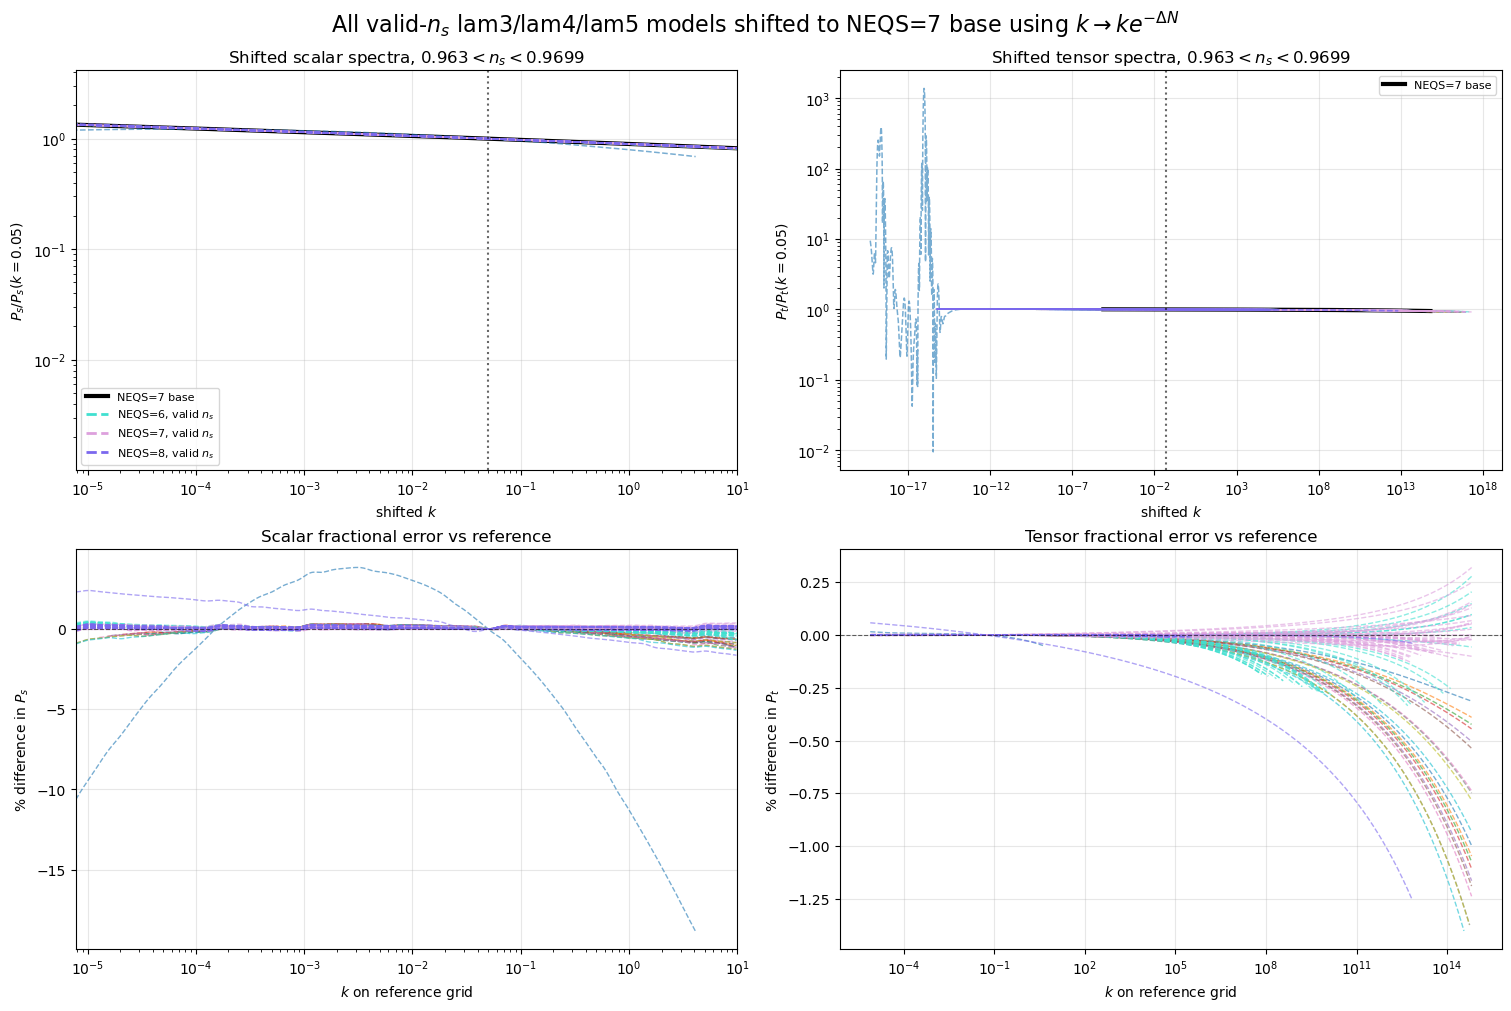


=== Valid-ns cross-NEQS shifted spectra summary ===
 NEQS param_name         value       ns  deltaN_from_ref_base  mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct
    5       lam2  4.096659e-04 0.963605             -5.003495     -0.061652     0.549012     -0.068117     0.313266
    5       lam2  4.197753e-04 0.963986             -4.532190     -0.089131     0.610389     -0.078810     0.389673
    5       lam2  4.241409e-04 0.964151             -4.332461     -0.103453     0.639166     -0.083332     0.423124
    5       lam2  4.269022e-04 0.964257             -4.207278     -0.102384     0.652610     -0.086213     0.444451
    5       lam2  4.346050e-04 0.964552             -3.862687     -0.127906     0.697064     -0.094169     0.504625
    5       lam2  4.386324e-04 0.964708             -3.685162     -0.053343     0.651913     -0.098335     0.536478
    5       lam2  4.633163e-04 0.965675             -2.634709     -0.055542     0.829342     -0.123788     0.738091
    5       lam2  4

In [47]:
lam_values_by_neqs = {
    5: lam2_values,
    6: lam3_values,
    7: lam4_values,
    8: lam5_values,
}

valid_ns_shift_df = plot_all_neqs_kshift_to_ref_base_2x2_ns_filtered(
    base_path_root=base_path_root,
    lam_values_by_neqs=lam_values_by_neqs,
    ref_NEQS=7,
    ref_param="lam4",
    ref_value=6.87065e-8,
    ns_min=0.963,
    ns_max=0.9699,
    k_norm=0.05,
    k_max_scalar=10.0,
    skip_zero=True,
    save_name="all_neqs_valid_ns_shifted_to_neqs7_base_spectra_2x2.png",
)



NEQS=6 CHECK:

In [48]:
# valid_ns_shift_df = plot_all_neqs_kshift_to_ref_base_2x2_ns_filtered(
#     base_path_root=base_path_root,
#     lam_values_by_neqs=lam_values_by_neqs,
#     ref_NEQS=6,
#     ref_param="lam3",
#     ref_value=-4.6097100000e-6,
#     ns_min=0.963,
#     ns_max=0.970,
#     k_norm=0.05,
#     k_max_scalar=10.0,
#     skip_zero=True,
#     save_name="all_neqs_valid_ns_shifted_to_neqs6_base_spectra_2x2.png",
# )

NEQS=8 CHECK:

In [49]:
# valid_ns_shift_df = plot_all_neqs_kshift_to_ref_base_2x2_ns_filtered(
#     base_path_root=base_path_root,
#     lam_values_by_neqs=lam_values_by_neqs,
#     ref_NEQS=8,
#     ref_param="lam5",
#     ref_value=-8.92461e-9,
#     ns_min=0.963,
#     ns_max=0.970,
#     k_norm=0.05,
#     k_max_scalar=10.0,
#     skip_zero=True,
#     save_name="all_neqs_valid_ns_shifted_to_neqs8_base_spectra_2x2.png",
# )

From what I am seeing NEQS=6 is probably not enough if you want sub-percent scalar-spectrum stability. NEQS=7 looks like the minimum viable truncation...

Now we can look at for all models in previous cell ns range, what are the shifted scalar and tensor stats as a function of their deltaN.

 NEQS  n_models  rms_dPs_pct  median_max_dPs_pct  max_dPs_pct  rms_dPt_pct  median_max_dPt_pct  max_dPt_pct  median_deltaN  max_abs_deltaN
    5        21     0.611669            0.967729    18.821736     0.142850            0.932229     1.401736      -1.441624       32.687856
    6        32     0.065412            0.282842     0.676261     0.029057            0.244600     0.335405      11.273478       16.064621
    7        35     0.076417            0.199254     0.377902     0.016352            0.073108     0.319608       0.930149        5.770491
    8        28     0.139157            0.243765     2.400424     0.050882            0.007815     1.256006      22.698430       23.543390


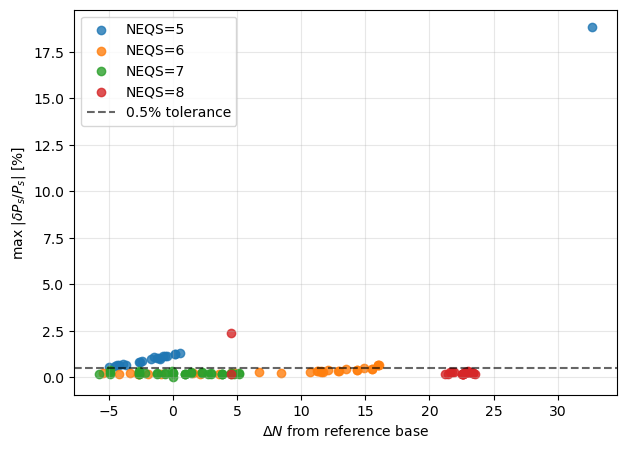

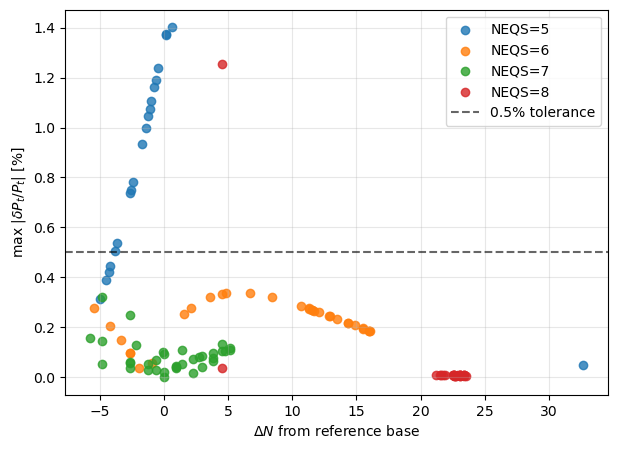

In [50]:
def summarize_shifted_stability(df):
    summary = (
        df.groupby("NEQS")
        .agg(
            n_models=("NEQS", "count"),

            rms_dPs_pct=("mean_dPs_pct", lambda x: np.sqrt(np.nanmean(x**2))),
            median_max_dPs_pct=("max_dPs_pct", "median"),
            max_dPs_pct=("max_dPs_pct", "max"),

            rms_dPt_pct=("mean_dPt_pct", lambda x: np.sqrt(np.nanmean(x**2))),
            median_max_dPt_pct=("max_dPt_pct", "median"),
            max_dPt_pct=("max_dPt_pct", "max"),

            median_deltaN=("deltaN_from_ref_base", "median"),
            max_abs_deltaN=("deltaN_from_ref_base", lambda x: np.nanmax(np.abs(x))),
        )
        .reset_index()
    )

    return summary

stability_df = summarize_shifted_stability(valid_ns_shift_df)
print(stability_df.to_string(index=False))


# Ps_tol = 0.5   # percent
# Pt_tol = 0.2   # percent

# stability_df["passes_Ps"] = stability_df["max_dPs_pct"] < Ps_tol
# stability_df["passes_Pt"] = stability_df["max_dPt_pct"] < Pt_tol
# stability_df["passes_both"] = stability_df["passes_Ps"] & stability_df["passes_Pt"]

# print(stability_df.to_string(index=False))



plt.figure(figsize=(7,5))

for NEQS, group in valid_ns_shift_df.groupby("NEQS"):
    plt.scatter(
        group["deltaN_from_ref_base"],
        group["max_dPs_pct"],
        label=f"NEQS={NEQS}",
        alpha=0.8
    )

plt.axhline(0.5, color="black", ls="--", alpha=0.6, label="0.5% tolerance")
plt.xlabel(r"$\Delta N$ from reference base")
plt.ylabel(r"max $|\delta P_s/P_s|$ [%]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


plt.figure(figsize=(7,5))

for NEQS, group in valid_ns_shift_df.groupby("NEQS"):
    plt.scatter(
        group["deltaN_from_ref_base"],
        group["max_dPt_pct"],
        label=f"NEQS={NEQS}",
        alpha=0.8
    )

plt.axhline(0.5, color="black", ls="--", alpha=0.6, label="0.5% tolerance")
plt.xlabel(r"$\Delta N$ from reference base")
plt.ylabel(r"max $|\delta P_t/P_t|$ [%]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## What is a good way to represent this?

This is next plot should take all valid ns models from NEQs 6-8, and compare them ALL to one chosen referfence base (below i choose neqs7 base) and it computes residual spectra before and after deltaN shift and summaries.

In [51]:
def plot_valid_ns_before_after_kshift_envelopes(
    base_path_root,
    lam_values_by_neqs,
    ref_NEQS=7,
    ref_param="lam4",
    ref_value=6.87065e-8,
    ns_min=0.963,
    ns_max=0.970,
    k_norm=0.05,
    k_max_scalar=10.0,
    skip_zero=True,
    zero_tol=1e-30,
    save_name=None,
):


    colors_by_neqs = {
        6: "turquoise",
        7: "plum",
        8: "mediumslateblue",
    }

    def folder_for(NEQS, param_name, value):
        val_str = f"{value:.10e}"
        return os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"{param_name}_{val_str}",
        )

    def load_specs(NEQS, param_name, value):
        folder = folder_for(NEQS, param_name, value)

        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

        k_s, Ps = prepare_increasing(s[:, 0], np.abs(s[:, 1]))
        k_t, Pt = prepare_increasing(t[:, 0], np.abs(t[:, 1]))

        return k_s, Ps, k_t, Pt

    def load_observables(NEQS, param_name, value):
        folder = folder_for(NEQS, param_name, value)
        arr = np.loadtxt(os.path.join(folder, f"test_nr_neqs{NEQS}.dat"))
        arr = np.atleast_1d(arr)
        return arr[0], arr[1], arr[2]  # r, ns, alpha_s

    def get_original_N_end(NEQS, param_name, value):
        summary_file = os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"neqs{NEQS}_summary.csv",
        )

        summary_df = pd.read_csv(summary_file)

        matches = summary_df.loc[
            np.isclose(summary_df[param_name], value)
        ]

        if len(matches) == 0:
            raise ValueError(
                f"No summary row found for NEQS={NEQS}, "
                f"{param_name}={value:.10e}"
            )

        return float(matches.iloc[0]["original_N_end"])

    def normalize_at_k(k, P, k_ref):
        k, P = prepare_increasing(k, P)

        if not (k.min() <= k_ref <= k.max()):
            raise ValueError(
                f"k_ref={k_ref} outside range [{k.min():.3e}, {k.max():.3e}]"
            )

        P_ref = np.interp(k_ref, k, P)

        if np.abs(P_ref) < 1e-30:
            raise ValueError(f"Reference spectrum too small at k={k_ref}")

        return k, P / P_ref

    def frac_on_ref_grid(k_ref_grid, P_ref_norm, k_cmp, P_cmp_norm, kmax=None):
        k_ref_grid, P_ref_norm = prepare_increasing(k_ref_grid, P_ref_norm)
        k_cmp, P_cmp_norm = prepare_increasing(k_cmp, P_cmp_norm)

        xmin = max(k_ref_grid.min(), k_cmp.min())
        xmax = min(k_ref_grid.max(), k_cmp.max())

        if kmax is not None:
            xmax = min(xmax, kmax)

        mask = (k_ref_grid >= xmin) & (k_ref_grid <= xmax)

        k_use = k_ref_grid[mask]
        P_ref_use = P_ref_norm[mask]
        P_cmp_interp = np.interp(k_use, k_cmp, P_cmp_norm)

        frac = (P_cmp_interp - P_ref_use) / P_ref_use

        return k_use, frac

    def collect_envelope(frac_curves, k_ref_grid):

        if len(frac_curves) == 0:
            return None, None, None

        k_env = k_ref_grid.copy()
        frac_stack = []

        for k_curve, frac_curve in frac_curves:

            if len(k_curve) < 2:
                continue

            interp = np.interp(
                k_env,
                k_curve,
                frac_curve,
                left=np.nan,
                right=np.nan,
            )

            # keep only curves with SOME valid overlap
            if np.all(~np.isfinite(interp)):
                continue

            frac_stack.append(interp)

        if len(frac_stack) == 0:
            return None, None, None

        frac_stack = np.array(frac_stack)

        # require at least one finite entry at each k
        valid_cols = np.any(np.isfinite(frac_stack), axis=0)

        frac_stack = frac_stack[:, valid_cols]
        k_env = k_env[valid_cols]

        abs_stack = np.abs(frac_stack)

        mean_abs = 100.0 * np.nanmean(abs_stack, axis=0)
        max_abs = 100.0 * np.nanmax(abs_stack, axis=0)

        return k_env, mean_abs, max_abs
        # ------------------------------------------------------------
    # Reference spectra
    # ------------------------------------------------------------
    ref_N_end = get_original_N_end(ref_NEQS, ref_param, ref_value)

    k_s_ref_raw, Ps_ref_raw, k_t_ref_raw, Pt_ref_raw = load_specs(
        ref_NEQS,
        ref_param,
        ref_value,
    )

    k_s_ref, Ps_ref_norm = normalize_at_k(
        k_s_ref_raw,
        Ps_ref_raw,
        k_norm,
    )

    k_t_ref, Pt_ref_norm = normalize_at_k(
        k_t_ref_raw,
        Pt_ref_raw,
        k_norm,
    )

    scalar_ref_mask = k_s_ref <= k_max_scalar
    k_s_ref_plot = k_s_ref[scalar_ref_mask]

    # ------------------------------------------------------------
    # Collect curves
    # ------------------------------------------------------------
    curves = {
        NEQS: {
            "Ps_unshift": [],
            "Ps_shift": [],
            "Pt_unshift": [],
            "Pt_shift": [],
            "rows": [],
        }
        for NEQS in lam_values_by_neqs.keys()
    }

    for NEQS, lam_values in lam_values_by_neqs.items():

        param_name, _ = SCAN_INFO[NEQS]

        for item in lam_values:

            value = item[0] if isinstance(item, tuple) else item
            value = float(value)

            if skip_zero and np.isclose(value, 0.0, atol=zero_tol):
                continue

            try:
                r, ns, alpha_s = load_observables(NEQS, param_name, value)

                if not (ns_min <= ns <= ns_max):
                    continue

                model_N_end = get_original_N_end(NEQS, param_name, value)
                deltaN = model_N_end - ref_N_end

                k_s_raw, Ps_raw, k_t_raw, Pt_raw = load_specs(
                    NEQS,
                    param_name,
                    value,
                )

                # -----------------------
                # Unshifted comparison
                # -----------------------
                k_s_un, Ps_un = normalize_at_k(k_s_raw, Ps_raw, k_norm)
                k_t_un, Pt_un = normalize_at_k(k_t_raw, Pt_raw, k_norm)

                k_ps_un, frac_ps_un = frac_on_ref_grid(
                    k_s_ref,
                    Ps_ref_norm,
                    k_s_un,
                    Ps_un,
                    kmax=k_max_scalar,
                )

                k_pt_un, frac_pt_un = frac_on_ref_grid(
                    k_t_ref,
                    Pt_ref_norm,
                    k_t_un,
                    Pt_un,
                    kmax=None,
                )

                # -----------------------
                # Shifted comparison
                # -----------------------
                k_s_shifted = k_s_raw * np.exp(-deltaN)
                k_t_shifted = k_t_raw * np.exp(-deltaN)

                k_s_sh, Ps_sh = normalize_at_k(k_s_shifted, Ps_raw, k_norm)
                k_t_sh, Pt_sh = normalize_at_k(k_t_shifted, Pt_raw, k_norm)

                k_ps_sh, frac_ps_sh = frac_on_ref_grid(
                    k_s_ref,
                    Ps_ref_norm,
                    k_s_sh,
                    Ps_sh,
                    kmax=k_max_scalar,
                )

                k_pt_sh, frac_pt_sh = frac_on_ref_grid(
                    k_t_ref,
                    Pt_ref_norm,
                    k_t_sh,
                    Pt_sh,
                    kmax=None,
                )

                curves[NEQS]["Ps_unshift"].append((k_ps_un, frac_ps_un))
                curves[NEQS]["Ps_shift"].append((k_ps_sh, frac_ps_sh))
                curves[NEQS]["Pt_unshift"].append((k_pt_un, frac_pt_un))
                curves[NEQS]["Pt_shift"].append((k_pt_sh, frac_pt_sh))

                curves[NEQS]["rows"].append({
                    "NEQS": NEQS,
                    "param_name": param_name,
                    "value": value,
                    "r": r,
                    "ns": ns,
                    "alpha_s": alpha_s,
                    "deltaN_from_ref_base": deltaN,

                    "max_Ps_unshift_pct": 100.0 * np.nanmax(np.abs(frac_ps_un)),
                    "max_Ps_shift_pct": 100.0 * np.nanmax(np.abs(frac_ps_sh)),
                    "max_Pt_unshift_pct": 100.0 * np.nanmax(np.abs(frac_pt_un)),
                    "max_Pt_shift_pct": 100.0 * np.nanmax(np.abs(frac_pt_sh)),
                })

            except FileNotFoundError:
                print(
                    f"Missing files for NEQS={NEQS}, "
                    f"{param_name}={value:.5e}"
                )

            except ValueError as e:
                print(
                    f"Skipping NEQS={NEQS}, "
                    f"{param_name}={value:.5e}: {e}"
                )

    # ------------------------------------------------------------
    # Plot envelopes
    # ------------------------------------------------------------
    fig, axes = plt.subplots(
        2,
        2,
        figsize=(15, 10),
        constrained_layout=True,
    )

    ax_ps_un, ax_ps_sh = axes[0]
    ax_pt_un, ax_pt_sh = axes[1]

    plot_specs = [
        ("Ps_unshift", ax_ps_un, k_s_ref, k_max_scalar, r"$P_s$", "Before $k$-shift"),
        ("Ps_shift",   ax_ps_sh, k_s_ref, k_max_scalar, r"$P_s$", "After $k \\to k e^{-\\Delta N}$"),
        ("Pt_unshift", ax_pt_un, k_t_ref, None,         r"$P_t$", "Before $k$-shift"),
        ("Pt_shift",   ax_pt_sh, k_t_ref, None,         r"$P_t$", "After $k \\to k e^{-\\Delta N}$"),
    ]

    envelope_rows = []

    for key, ax, k_ref_grid, kmax, quantity_label, title_suffix in plot_specs:

        for NEQS in lam_values_by_neqs.keys():

            color = colors_by_neqs.get(NEQS, None)

            k_env, mean_abs, max_abs = collect_envelope(
                curves[NEQS][key],
                k_ref_grid,
            )

            if k_env is None:
                continue

            if kmax is not None:
                mask = k_env <= kmax
                k_env = k_env[mask]
                mean_abs = mean_abs[mask]
                max_abs = max_abs[mask]

            ax.plot(
                k_env,
                mean_abs,
                color=color,
                lw=2.0,
                label=rf"NEQS={NEQS} mean",
            )

            ax.fill_between(
                k_env,
                0.0,
                max_abs,
                color=color,
                alpha=0.18,
                label=rf"NEQS={NEQS} max envelope",
            )

            envelope_rows.append({
                "NEQS": NEQS,
                "case": key,
                "n_models": len(curves[NEQS][key]),
                "median_mean_abs_pct": np.nanmedian(mean_abs),
                "max_envelope_pct": np.nanmax(max_abs),
            })

        ax.set_xscale("log")
        ax.grid(True, alpha=0.25)
        ax.minorticks_on()
        ax.set_title(rf"{quantity_label} error envelope: {title_suffix}")
        ax.set_xlabel(r"$k$")
        ax.set_ylabel(rf"$|\Delta {quantity_label}/{quantity_label}|$ [%]")

        if kmax is not None:
            ax.set_xlim(k_ref_grid.min(), kmax)

        ax.legend(fontsize=7)

    fig.suptitle(
        rf"Valid-$n_s$ spectral-error envelopes relative to NEQS={ref_NEQS} base "
        rf"(${ns_min}<n_s<{ns_max}$)",
        fontsize=16,
    )

    if save_name is None:
        save_name = (
            f"valid_ns_error_envelopes_before_after_shift_"
            f"ref_neqs{ref_NEQS}.png"
        )

    plt.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()

    # ------------------------------------------------------------
    # Return summaries
    # ------------------------------------------------------------
    model_rows = []
    for NEQS in lam_values_by_neqs.keys():
        model_rows.extend(curves[NEQS]["rows"])

    model_df = pd.DataFrame(model_rows)
    envelope_df = pd.DataFrame(envelope_rows)

    print("\n=== Envelope summary ===")
    if not envelope_df.empty:
        print(envelope_df.to_string(index=False))

    print("\n=== Model-level summary ===")
    if not model_df.empty:
        print(model_df.to_string(index=False))

    return model_df, envelope_df

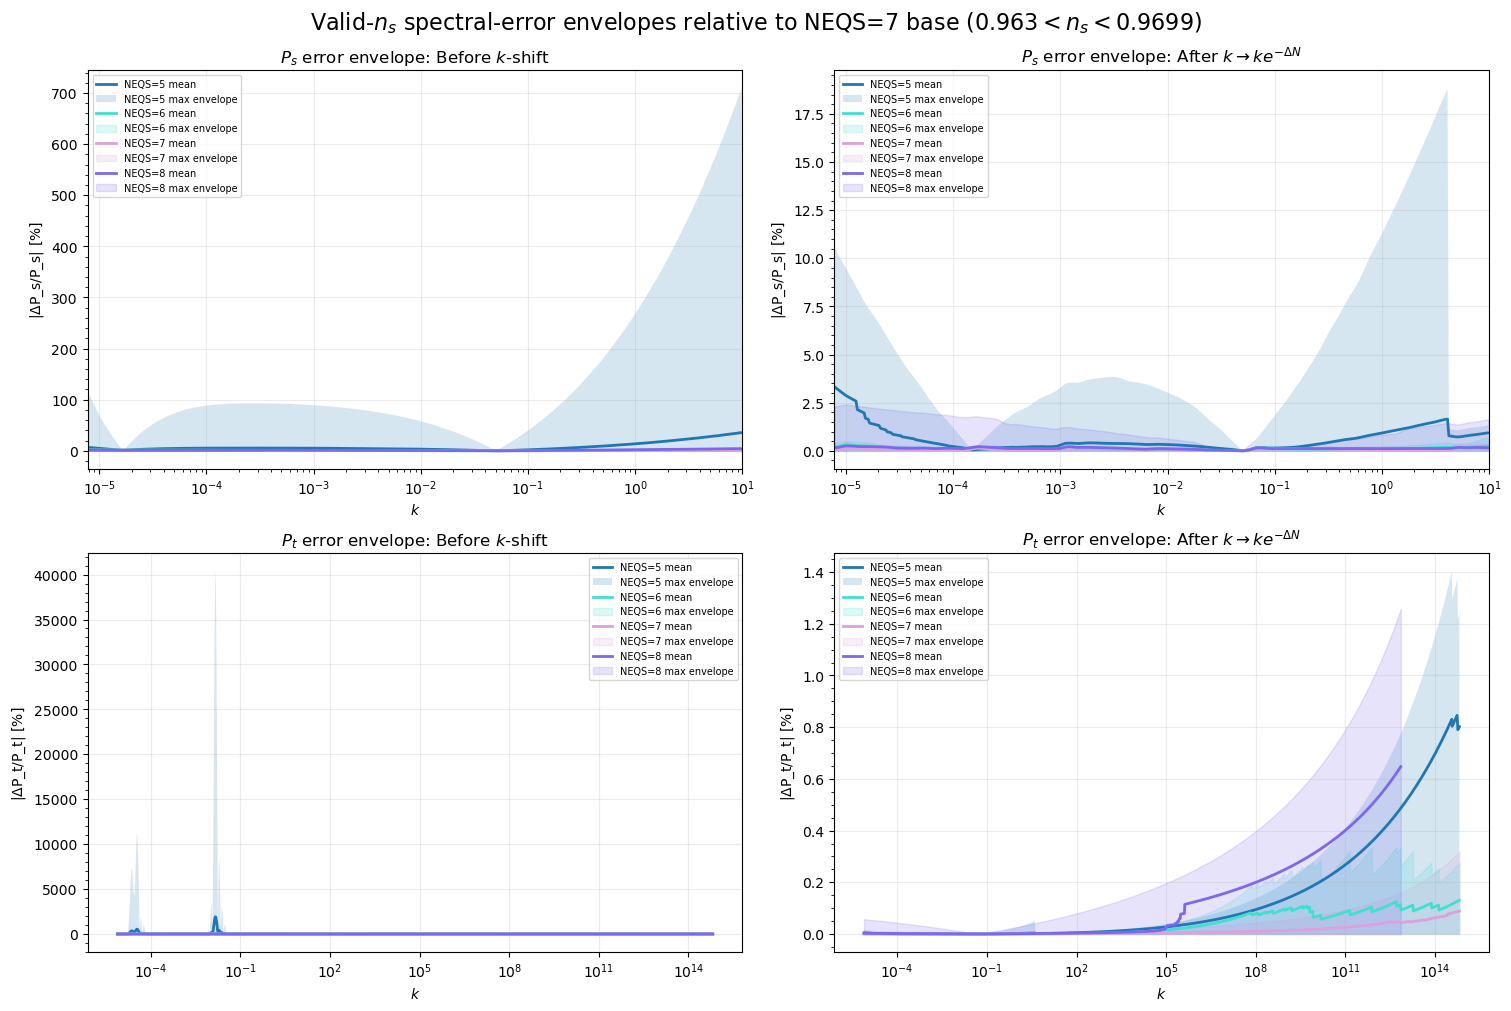


=== Envelope summary ===
 NEQS       case  n_models  median_mean_abs_pct  max_envelope_pct
    5 Ps_unshift        21             5.076528        708.992959
    6 Ps_unshift        32             0.923570          3.294755
    7 Ps_unshift        35             0.597313          3.206053
    8 Ps_unshift        28             1.023596          5.061729
    5   Ps_shift        21             0.380924         18.821736
    6   Ps_shift        32             0.096239          0.676261
    7   Ps_shift        35             0.073163          0.377902
    8   Ps_shift        28             0.120739          2.400424
    5 Pt_unshift        21             3.616503      40332.680504
    6 Pt_unshift        32             0.258144          2.974676
    7 Pt_unshift        35             0.099094          2.614080
    8 Pt_unshift        28             0.459244          3.739084
    5   Pt_shift        21             0.025536          1.401736
    6   Pt_shift        32             0.014239   

In [52]:
lam_values_by_neqs = {
    5: lam2_values,
    6: lam3_values,
    7: lam4_values,
    8: lam5_values,
}

model_df, envelope_df = plot_valid_ns_before_after_kshift_envelopes(
    base_path_root=base_path_root,
    lam_values_by_neqs=lam_values_by_neqs,
    ref_NEQS=7,
    ref_param="lam4",
    ref_value=6.87065e-8,
    ns_min=0.963,
    ns_max=0.9699,
    k_norm=0.05,
    k_max_scalar=10.0,
    skip_zero=True,
    save_name="valid_ns_before_after_kshift_envelopes_ref_neqs7.png",
)

In [53]:
def print_shifted_k_ranges_for_valid_models(
    valid_ns_shift_df,
    base_path_root,
):


    for _, row in valid_ns_shift_df.iterrows():
        NEQS = int(row["NEQS"])
        param_name = row["param_name"]
        value = float(row["value"])
        deltaN = float(row["deltaN_from_ref_base"])

        val_str = f"{value:.10e}"
        folder = os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"{param_name}_{val_str}",
        )

        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        k = s[:, 0]

        k_shifted = k * np.exp(-deltaN)

        print(
            f"NEQS={NEQS}, {param_name}={value:.3e}, "
            f"deltaN={deltaN:.2f}, "
            f"k_shifted range=({k_shifted.min():.3e}, {k_shifted.max():.3e})"
        )
        
print_shifted_k_ranges_for_valid_models(
    valid_ns_shift_df=model_df,
    base_path_root=base_path_root,
)



NEQS=5, lam2=4.097e-04, deltaN=-5.00, k_shifted range=(1.160e-03, 9.636e+16)
NEQS=5, lam2=4.198e-04, deltaN=-4.53, k_shifted range=(7.243e-04, 6.015e+16)
NEQS=5, lam2=4.241e-04, deltaN=-4.33, k_shifted range=(5.932e-04, 4.926e+16)
NEQS=5, lam2=4.269e-04, deltaN=-4.21, k_shifted range=(5.234e-04, 4.346e+16)
NEQS=5, lam2=4.346e-04, deltaN=-3.86, k_shifted range=(3.708e-04, 3.079e+16)
NEQS=5, lam2=4.386e-04, deltaN=-3.69, k_shifted range=(3.105e-04, 2.578e+16)
NEQS=5, lam2=4.633e-04, deltaN=-2.63, k_shifted range=(1.086e-04, 9.019e+15)
NEQS=5, lam2=4.646e-04, deltaN=-2.58, k_shifted range=(1.029e-04, 8.547e+15)
NEQS=5, lam2=4.685e-04, deltaN=-2.42, k_shifted range=(8.766e-05, 7.279e+15)
NEQS=5, lam2=4.859e-04, deltaN=-1.73, k_shifted range=(4.383e-05, 3.640e+15)
NEQS=5, lam2=4.932e-04, deltaN=-1.44, k_shifted range=(3.294e-05, 2.735e+15)
NEQS=5, lam2=4.987e-04, deltaN=-1.23, k_shifted range=(2.672e-05, 2.219e+15)
NEQS=5, lam2=5.017e-04, deltaN=-1.12, k_shifted range=(2.384e-05, 1.980e+15)

Fractional-error envelopes for normalized scalar and tensor power spectra relative to the NEQS$=7$ base model, using only models satisfying $0.963 < n_s < 0.970$. 

The top row shows scalar-spectrum residuals, while the bottom row shows tensor-spectrum residuals. The left column gives the raw comparison before applying any correction for displacement in e-fold space. The right column shows the same comparison after applying the effective horizontal shift $k -> k e^{-\Delta N}$,
where $\Delta N = N_{\epsilon=1}^{\rm model} - N_{\epsilon=1}^{\rm ref}$.

Solid curves denote the mean absolute fractional difference across all models within a given truncation order, while shaded regions indicate the maximum absolute deviation envelope. Green, blue, and orange correspond to NEQS$=6$, 7, and 8 respectively.

Before the shift correction, scalar spectra exhibit percent-level variation and tensor spectra show comparable spread. After accounting for the effective $\Delta N$ displacement, the envelopes collapse substantially, with scalar residuals reduced to sub-percent levels and tensor residuals typically below $0.1\%$. This demonstrates that much of the apparent variation between truncation orders is attributable to an effective displacement along a common inflationary trajectory rather than fundamentally different dynamics.

The remaining residuals indicate that NEQS$=7$ provides a stable truncation of the slow-roll hierarchy, but may need more to confirm.


## Observables 

We look at value of observables for all valid ns model, as we vary NEQs. Each dot is a model and we make three panels. Does not apply any deltaN shift.

In [55]:
def plot_observable_convergence_by_neqs(
    base_path_root,
    lam_values_by_neqs,
    ns_min=0.963,
    ns_max=0.970,
    skip_zero=True,
    zero_tol=1e-30,
    save_name=None,
):

    colors_by_neqs = {
        5: "pink",
        6: "turquoise",
        7: "plum",
        8: "mediumslateblue",
    }

    def folder_for(NEQS, param_name, value):
        val_str = f"{value:.10e}"
        return os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"{param_name}_{val_str}",
        )

    def load_observables(NEQS, param_name, value):
        folder = folder_for(NEQS, param_name, value)
        arr = np.loadtxt(os.path.join(folder, f"test_nr_neqs{NEQS}.dat"))
        arr = np.atleast_1d(arr)
        return arr[0], arr[1], arr[2]  # r, ns, alpha_s

    rows = []

    for NEQS, lam_values in lam_values_by_neqs.items():
        param_name, _ = SCAN_INFO[NEQS]

        for item in lam_values:
            value = item[0] if isinstance(item, tuple) else item
            value = float(value)

            if skip_zero and np.isclose(value, 0.0, atol=zero_tol):
                continue

            try:
                r, ns, alpha_s = load_observables(NEQS, param_name, value)

                if not (ns_min <= ns <= ns_max):
                    continue

                rows.append({
                    "NEQS": NEQS,
                    "param_name": param_name,
                    "value": value,
                    "r": r,
                    "n_s": ns,
                    "alpha_s": alpha_s,
                })

            except FileNotFoundError:
                print(f"Missing observables for NEQS={NEQS}, {param_name}={value:.5e}")

    df = pd.DataFrame(rows)

    if df.empty:
        print("No valid models found.")
        return df, None

    summary = (
        df.groupby("NEQS")
        .agg(
            n_models=("NEQS", "count"),

            ns_mean=("n_s", "mean"),
            ns_std=("n_s", "std"),
            ns_min=("n_s", "min"),
            ns_max=("n_s", "max"),

            r_mean=("r", "mean"),
            r_std=("r", "std"),
            r_min=("r", "min"),
            r_max=("r", "max"),

            alpha_mean=("alpha_s", "mean"),
            alpha_std=("alpha_s", "std"),
            alpha_min=("alpha_s", "min"),
            alpha_max=("alpha_s", "max"),
        )
        .reset_index()
    )

    fig, axes = plt.subplots(
        1, 3,
        figsize=(16, 4.8),
        constrained_layout=True,
    )

    obs_info = [
        ("n_s", r"$n_s$", axes[0]),
        ("r", r"$r$", axes[1]),
        ("alpha_s", r"$\alpha_s$", axes[2]),
    ]

    for obs, ylabel, ax in obs_info:
        for NEQS, group in df.groupby("NEQS"):
            x = np.full(len(group), NEQS)

            ax.scatter(
                x,
                group[obs],
                color=colors_by_neqs.get(NEQS),
                alpha=0.65,
                s=45,
                label=f"NEQS={NEQS}" if obs == "n_s" else None,
            )

        means = df.groupby("NEQS")[obs].mean()
        stds = df.groupby("NEQS")[obs].std()

        ax.errorbar(
            means.index,
            means.values,
            yerr=stds.values,
            color="black",
            marker="o",
            lw=2,
            capsize=4,
            label="mean ± std" if obs == "n_s" else None,
        )

        ax.plot(
            means.index,
            means.values,
            color="black",
            lw=1.5,
            alpha=0.8,
        )

        ax.set_xlabel("NEQS")
        ax.set_ylabel(ylabel)
        ax.set_xticks(sorted(df["NEQS"].unique()))
        ax.grid(True, alpha=0.3)

    axes[0].axhspan(ns_min, ns_max, color="gray", alpha=0.12, label="valid $n_s$ window")
    axes[0].legend(fontsize=8)

    fig.suptitle(
        rf"Observable convergence across truncation order "
        rf"for ${ns_min}<n_s<{ns_max}$",
        fontsize=15,
    )

    if save_name is None:
        save_name = "observable_convergence_by_neqs.png"

    plt.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()

    print("\n=== Observable convergence summary ===")
    print(summary.to_string(index=False))

    return df, summary

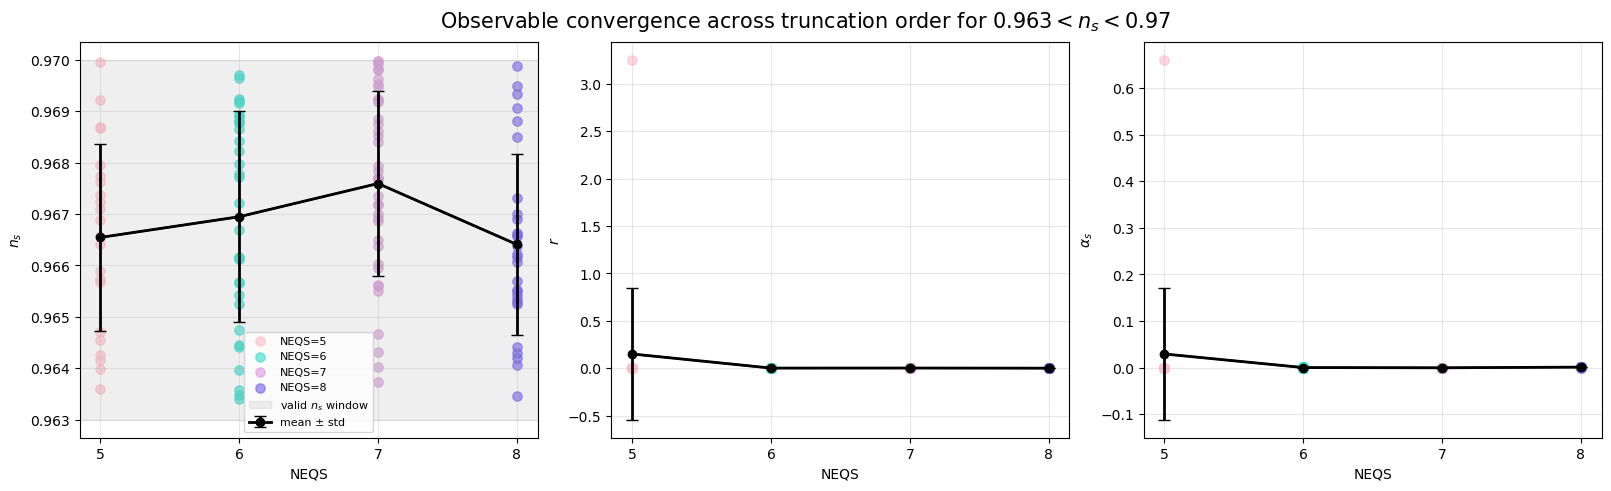


=== Observable convergence summary ===
 NEQS  n_models  ns_mean   ns_std   ns_min   ns_max   r_mean    r_std    r_min    r_max  alpha_mean  alpha_std  alpha_min  alpha_max
    5        22 0.966544 0.001818 0.963605 0.969960 0.151163 0.693194 0.003048 3.254741    0.029103   0.141152  -0.001095   0.661071
    6        32 0.966946 0.002047 0.963399 0.969701 0.002522 0.000616 0.001857 0.003807   -0.000033   0.000447  -0.000647   0.000648
    7        38 0.967592 0.001803 0.963727 0.969978 0.003094 0.000342 0.002658 0.003854   -0.000537   0.000056  -0.000665  -0.000471
    8        28 0.966407 0.001757 0.963452 0.969881 0.001694 0.000358 0.001537 0.003137    0.000893   0.000445  -0.000541   0.001334


In [56]:
lam_values_by_neqs = {
    5: lam2_values,
    6: lam3_values,
    7: lam4_values,
    8: lam5_values,
}

obs_df, obs_summary = plot_observable_convergence_by_neqs(
    base_path_root=base_path_root,
    lam_values_by_neqs=lam_values_by_neqs,
    ns_min=0.963,
    ns_max=0.970,
    skip_zero=True,
    save_name="observable_convergence_valid_ns_neqs6_8.png",
)



The next plot is like a summary of the big envelople plot. It groups by NEQs and for NEQs for all the models in valid ns range, it finds the mean of each models max shifted scalar error, as well as median, and also the worst scalar model. and does the same for tensors.

This plot is like a summary of the big envelople plot. It groups by NEQs and for NEQs for all the models in valid ns range, it finds the mean of each models max shifted scalar error, as well as median, and also the worst scalar model. and does the same for tensors.

So it takes the max error after shifting for every single model in neqs 6, neqs7, neqs8. It computes mean of all model max errors, the middle, and the the LARGEST max error among all models in an neqs group.


In [57]:
def plot_shifted_spectrum_error_vs_NEQS(
    model_df,
    as_percent=True,
    save_name="shifted_Ps_Pt_error_vs_NEQS.png",
):
 
    summary = (
        model_df.groupby("NEQS")
        .agg(
            n_models=("NEQS", "count"),

            Ps_mean_shift=("max_Ps_shift_pct", "mean"),
            Ps_median_shift=("max_Ps_shift_pct", "median"),
            Ps_max_shift=("max_Ps_shift_pct", "max"),

            Pt_mean_shift=("max_Pt_shift_pct", "mean"),
            Pt_median_shift=("max_Pt_shift_pct", "median"),
            Pt_max_shift=("max_Pt_shift_pct", "max"),
        )
        .reset_index()
    )

    fig, axes = plt.subplots(
        1, 2,
        figsize=(12, 4.8),
        constrained_layout=True
    )

    ax_ps, ax_pt = axes

    # Scalar
    ax_ps.plot(
        summary["NEQS"],
        summary["Ps_mean_shift"],
        marker="o",
        lw=2,
        label="mean of model max errors",
    )

    ax_ps.plot(
        summary["NEQS"],
        summary["Ps_median_shift"],
        marker="s",
        lw=2,
        label="median of model max errors",
    )

    ax_ps.plot(
        summary["NEQS"],
        summary["Ps_max_shift"],
        marker="^",
        lw=2,
        label="worst model",
    )

    # Tensor
    ax_pt.plot(
        summary["NEQS"],
        summary["Pt_mean_shift"],
        marker="o",
        lw=2,
        label="mean of model max errors",
    )

    ax_pt.plot(
        summary["NEQS"],
        summary["Pt_median_shift"],
        marker="s",
        lw=2,
        label="median of model max errors",
    )

    ax_pt.plot(
        summary["NEQS"],
        summary["Pt_max_shift"],
        marker="^",
        lw=2,
        label="worst model",
    )

    ax_ps.set_title(r"Shifted scalar-spectrum error vs NEQS")
    ax_pt.set_title(r"Shifted tensor-spectrum error vs NEQS")

    ax_ps.set_ylabel(r"max $|\Delta P_s/P_s|$ per model [\%]")
    ax_pt.set_ylabel(r"max $|\Delta P_t/P_t|$ per model [\%]")

    for ax in axes:
        ax.set_xlabel("NEQS")
        ax.set_xticks(summary["NEQS"])
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)

    fig.suptitle(
        r"Residual spectrum error after $k \rightarrow k e^{-\Delta N}$",
        fontsize=15,
    )

#     plt.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()

    print("\n=== Shifted spectrum error vs NEQS ===")
    print(summary.to_string(index=False))

    return summary

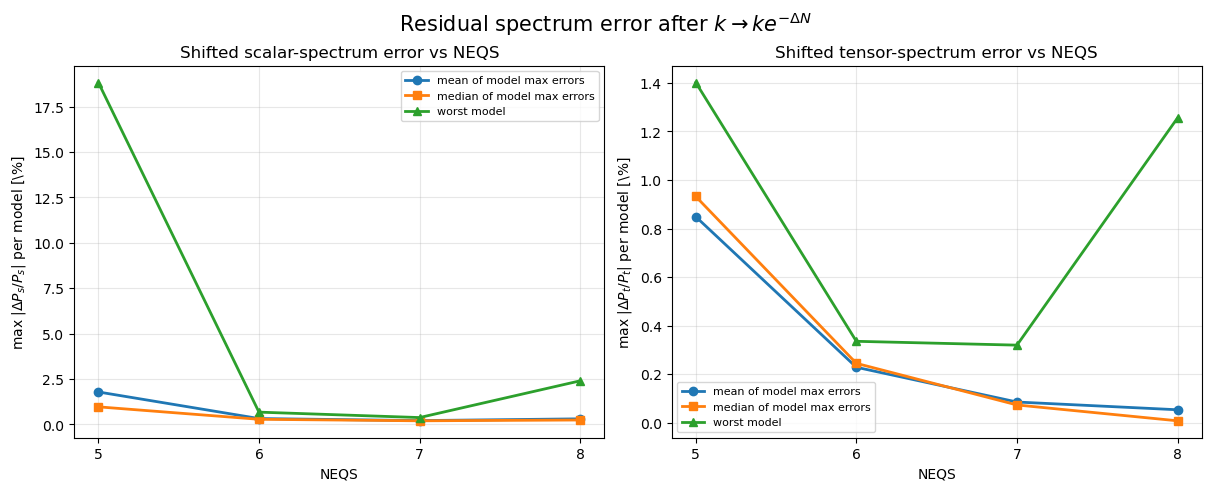


=== Shifted spectrum error vs NEQS ===
 NEQS  n_models  Ps_mean_shift  Ps_median_shift  Ps_max_shift  Pt_mean_shift  Pt_median_shift  Pt_max_shift
    5        21       1.787139         0.967729     18.821736       0.848876         0.932229      1.401736
    6        32       0.323139         0.282842      0.676261       0.228422         0.244600      0.335405
    7        35       0.210611         0.199254      0.377902       0.085221         0.073108      0.319608
    8        28       0.307587         0.243765      2.400424       0.053304         0.007815      1.256006


In [59]:
shifted_error_summary = plot_shifted_spectrum_error_vs_NEQS(
    model_df,
    save_name="shifted_Ps_Pt_error_vs_NEQS.png",
)



The left side is for every model we are looking at the fractional error relative to the base neqs=6.

NEQS=8 does NOT improve **scalar** stability relative to 7, even though tensor convergence continues improving. NEQS=7 appears to be the point where adding higher-order slow-roll terms no longer significantly improves the scalar spectra. “After removing the dominant ΔN effect, the residual scalar-spectrum error reaches a minimum near NEQS=7 and does not substantially improve at higher order.

In [60]:
def plot_before_after_shift_error_bars(
    model_df,
    metric="max",   # "max", "mean", or "median"
    save_name="before_after_shift_error_bars.png",
):

    if metric == "max":
        agg_func = "max"
        label = "worst-case"
    elif metric == "mean":
        agg_func = "mean"
        label = "mean"
    elif metric == "median":
        agg_func = "median"
        label = "median"
    else:
        raise ValueError("metric must be 'max', 'mean', or 'median'")

    summary = (
        model_df.groupby("NEQS")
        .agg(
            Ps_unshift=("max_Ps_unshift_pct", agg_func),
            Ps_shift=("max_Ps_shift_pct", agg_func),
            Pt_unshift=("max_Pt_unshift_pct", agg_func),
            Pt_shift=("max_Pt_shift_pct", agg_func),
        )
        .reset_index()
    )

    summary["Ps_reduction_pct"] = 100.0 * (
        1.0 - summary["Ps_shift"] / summary["Ps_unshift"]
    )

    summary["Pt_reduction_pct"] = 100.0 * (
        1.0 - summary["Pt_shift"] / summary["Pt_unshift"]
    )

    x = np.arange(len(summary))
    width = 0.35

    fig, axes = plt.subplots(
        1, 2,
        figsize=(12, 4.8),
        constrained_layout=True
    )

    ax_ps, ax_pt = axes

    ax_ps.bar(
        x - width / 2,
        summary["Ps_unshift"],
        width,
        label="before shift",
        alpha=0.75,
    )

    ax_ps.bar(
        x + width / 2,
        summary["Ps_shift"],
        width,
        label=r"after $k\to k e^{-\Delta N}$",
        alpha=0.75,
    )

    ax_pt.bar(
        x - width / 2,
        summary["Pt_unshift"],
        width,
        label="before shift",
        alpha=0.75,
    )

    ax_pt.bar(
        x + width / 2,
        summary["Pt_shift"],
        width,
        label=r"after $k\to k e^{-\Delta N}$",
        alpha=0.75,
    )

    ax_ps.set_title(rf"Scalar spectra: {label} residual")
    ax_pt.set_title(rf"Tensor spectra: {label} residual")

    ax_ps.set_ylabel(r"$|\Delta P_s/P_s|$ [%]")
    ax_pt.set_ylabel(r"$|\Delta P_t/P_t|$ [%]")

    for ax in axes:
        ax.set_xticks(x)
        ax.set_xticklabels(summary["NEQS"])
        ax.set_xlabel("NEQS")
        ax.grid(True, axis="y", alpha=0.3)
        ax.legend(fontsize=8)

    fig.suptitle(
        rf"Spectral residuals before and after $\Delta N$ correction ({label})",
        fontsize=15,
    )

#     plt.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()

    print("\n=== Before/after shift residual summary ===")
    print(summary.to_string(index=False))

    return summary

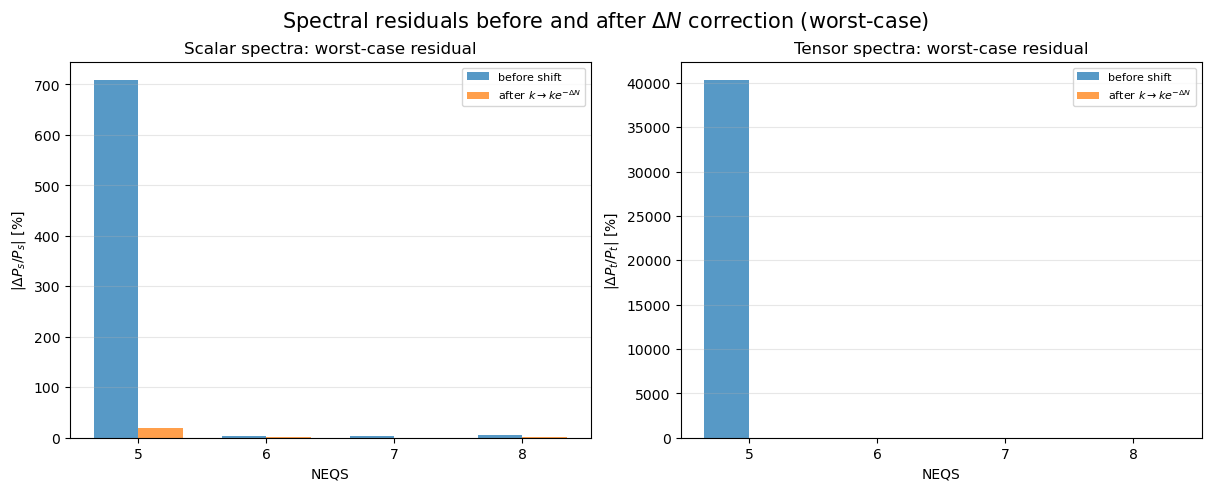


=== Before/after shift residual summary ===
 NEQS  Ps_unshift  Ps_shift   Pt_unshift  Pt_shift  Ps_reduction_pct  Pt_reduction_pct
    5  708.992959 18.821736 40332.680504  1.401736         97.345286         99.996525
    6    3.294755  0.676261     2.974676  0.335405         79.474625         88.724662
    7    3.206053  0.377902     2.614080  0.319608         88.212849         87.773605
    8    5.061729  2.400424     3.739084  1.256006         52.576995         66.408710


In [61]:
bar_summary = plot_before_after_shift_error_bars(
    model_df,
    metric="max",
    save_name="before_after_shift_error_bars_max.png",
)

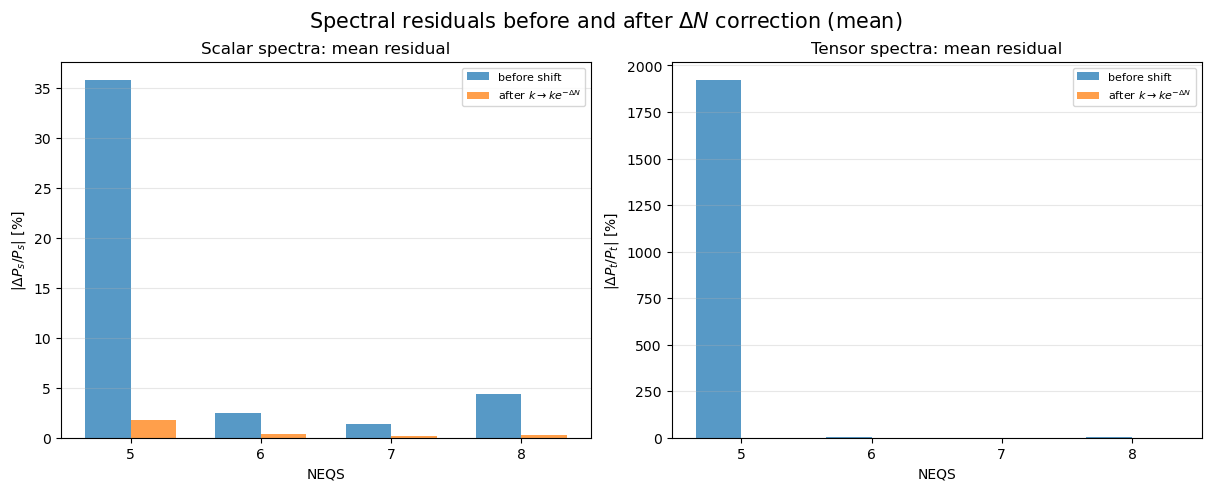


=== Before/after shift residual summary ===
 NEQS  Ps_unshift  Ps_shift  Pt_unshift  Pt_shift  Ps_reduction_pct  Pt_reduction_pct
    5   35.804101  1.787139 1922.527886  0.848876         95.008562         99.955846
    6    2.475671  0.323139    1.959553  0.228422         86.947409         88.343149
    7    1.349222  0.210611    0.896322  0.085221         84.390213         90.492189
    8    4.364832  0.307587    3.469419  0.053304         92.953052         98.463612


In [62]:
bar_summary_mean = plot_before_after_shift_error_bars(
    model_df,
    metric="mean",
    save_name="before_after_shift_error_bars_mean.png",
)

# NEQS=7 gives the smallest residual scalar mismatch!!!!! 

neqs=8 obviously improves this BUT it would seem neqs=7 would be enough. after removing the dominant change in N effect, it is neqs=7 that has the smallest residual. The scalar sector probably is what sets the truncation value and is more sensitive.


So I do plot the background trajectories, where Nunshifted = Nrecon. Nshifted = Nrecon + deltaN. and deltaN = Nmodel_end - Nref_end

In [64]:
def plot_background_trajectories_before_after_deltaN(
    base_path_root,
    lam_values_by_neqs,
    ref_NEQS=7,
    ref_param="lam4",
    ref_value=6.87065e-8,
    ns_min=0.963,
    ns_max=0.970,
    N_ref=60.0,
    skip_zero=True,
    zero_tol=1e-30,
    normalize_H=True,
    normalize_V=True,
    save_name=None,
):


    colors_by_neqs = {
        6: "green",
        7: "blue",
        8: "orange",
    }

    def folder_for(NEQS, param_name, value):
        val_str = f"{value:.10e}"
        return os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"{param_name}_{val_str}",
        )

    def load_observables(NEQS, param_name, value):
        folder = folder_for(NEQS, param_name, value)
        arr = np.loadtxt(os.path.join(folder, f"test_nr_neqs{NEQS}.dat"))
        arr = np.atleast_1d(arr)
        return arr[0], arr[1], arr[2]

    def load_path(NEQS, param_name, value):
        val_str = f"{value:.10e}"
        folder = folder_for(NEQS, param_name, value)
        file_path = os.path.join(
            folder,
            f"path_neqs{NEQS}_{param_name}_{val_str}.dat",
        )
        return pd.read_csv(file_path, sep=r"\s+", header=None).values

    def get_original_N_end(NEQS, param_name, value):
        summary_file = os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"neqs{NEQS}_summary.csv",
        )

        summary_df = pd.read_csv(summary_file)

        matches = summary_df.loc[
            np.isclose(summary_df[param_name], value)
        ]

        if len(matches) == 0:
            raise ValueError(
                f"No summary row found for NEQS={NEQS}, "
                f"{param_name}={value:.10e}"
            )

        return float(matches.iloc[0]["original_N_end"])

    def extract_background_cols(path_data, NEQS):
        phi = path_data[:, 0]
        H = path_data[:, 1]
        eps = path_data[:, 2]
        sigma = path_data[:, 3]
        lam2 = path_data[:, 4]
        lam3 = path_data[:, 5]
        N = path_data[:, NEQS]
        V = path_data[:, NEQS + 1]

        return phi, H, V, eps, sigma, lam2, lam3, N

    def safe_prepare(x, y):
        x = np.asarray(x)
        y = np.asarray(y)
        order = np.argsort(x)
        return x[order], y[order]

    def normalize_y_at_xref(x, y, x_ref, floor=1e-30):
        x_use, y_use = safe_prepare(x, y)

        if not (x_use.min() <= x_ref <= x_use.max()):
            return x_use, y_use, np.nan

        y_ref = np.interp(x_ref, x_use, y_use)

        if np.abs(y_ref) < floor:
            return x_use, y_use, np.nan

        return x_use, y_use / y_ref, y_ref

    # ------------------------------------------------------------
    # Reference model
    # ------------------------------------------------------------
    ref_N_end = get_original_N_end(ref_NEQS, ref_param, ref_value)

    ref_path = load_path(ref_NEQS, ref_param, ref_value)
    (
        phi_ref,
        H_ref,
        V_ref,
        eps_ref,
        sigma_ref,
        lam2_ref,
        lam3_ref,
        N_ref_raw,
    ) = extract_background_cols(ref_path, ref_NEQS)

    # Reference unshifted and shifted are the same because deltaN=0.
    if normalize_H:
        N_ref_H, H_ref_plot, _ = normalize_y_at_xref(N_ref_raw, H_ref, N_ref)
    else:
        N_ref_H, H_ref_plot = safe_prepare(N_ref_raw, H_ref)

    if normalize_V:
        N_ref_V, V_ref_N_plot, _ = normalize_y_at_xref(N_ref_raw, V_ref, N_ref)
    else:
        N_ref_V, V_ref_N_plot = safe_prepare(N_ref_raw, V_ref)

    phi_ref_H, H_ref_phi = safe_prepare(phi_ref, H_ref)
    phi_ref_V, V_ref_phi = safe_prepare(phi_ref, V_ref)

    if normalize_H:
        H_phi_norm_factor = np.interp(N_ref, *safe_prepare(N_ref_raw, H_ref))
        H_ref_phi = H_ref_phi / H_phi_norm_factor

    if normalize_V:
        V_phi_norm_factor = np.interp(N_ref, *safe_prepare(N_ref_raw, V_ref))
        V_ref_phi = V_ref_phi / V_phi_norm_factor

    N_ref_eps, eps_ref_plot = safe_prepare(N_ref_raw, eps_ref)
    N_ref_sig, sigma_ref_plot = safe_prepare(N_ref_raw, sigma_ref)
    N_ref_lam2, lam2_ref_plot = safe_prepare(N_ref_raw, lam2_ref)
    N_ref_lam3, lam3_ref_plot = safe_prepare(N_ref_raw, lam3_ref)

    # ------------------------------------------------------------
    # Figure setup
    # ------------------------------------------------------------
    plot_rows = [
        ("H_N", r"$H(N)/H(N_{\rm ref})$" if normalize_H else r"$H(N)$"),
        ("V_N", r"$V(N)/V(N_{\rm ref})$" if normalize_V else r"$V(N)$"),
        ("eps_N", r"$\epsilon(N)$"),
        ("sigma_N", r"$\sigma(N)$"),
        ("lam2_N", r"$\lambda_2(N)$"),
        ("lam3_N", r"$\lambda_3(N)$"),
        ("H_phi", r"$H(\phi)/H(N_{\rm ref})$" if normalize_H else r"$H(\phi)$"),
        ("V_phi", r"$V(\phi)/V(N_{\rm ref})$" if normalize_V else r"$V(\phi)$"),
    ]

    fig, axes = plt.subplots(
        len(plot_rows),
        2,
        figsize=(15, 24),
        constrained_layout=True,
    )

    # Reference curves
    ref_curves = {
        "H_N": (N_ref_H, H_ref_plot),
        "V_N": (N_ref_V, V_ref_N_plot),
        "eps_N": (N_ref_eps, eps_ref_plot),
        "sigma_N": (N_ref_sig, sigma_ref_plot),
        "lam2_N": (N_ref_lam2, lam2_ref_plot),
        "lam3_N": (N_ref_lam3, lam3_ref_plot),
        "H_phi": (phi_ref_H, H_ref_phi),
        "V_phi": (phi_ref_V, V_ref_phi),
    }

    for i, (key, ylabel) in enumerate(plot_rows):
        for j in range(2):
            x_ref, y_ref = ref_curves[key]
            axes[i, j].plot(
                x_ref,
                y_ref,
                color="black",
                lw=2.8,
                ls="-",
                label=rf"NEQS={ref_NEQS} base",
            )

    rows = []

    # ------------------------------------------------------------
    # Model loop
    # ------------------------------------------------------------
    for NEQS, lam_values in lam_values_by_neqs.items():

        param_name, _ = SCAN_INFO[NEQS]
        color = colors_by_neqs.get(NEQS, None)

        for item in lam_values:

            value = item[0] if isinstance(item, tuple) else item
            value = float(value)

            if skip_zero and np.isclose(value, 0.0, atol=zero_tol):
                continue

            try:
                r, ns, alpha_s = load_observables(NEQS, param_name, value)

                if not (ns_min <= ns <= ns_max):
                    continue

                model_N_end = get_original_N_end(NEQS, param_name, value)
                deltaN = model_N_end - ref_N_end

                path_data = load_path(NEQS, param_name, value)

                phi, H, V, eps, sigma, lam2, lam3, N_raw = extract_background_cols(
                    path_data,
                    NEQS,
                )

                # Before shift: use reconstructed N directly.
                N_un = N_raw

                # After shift: align to the reference original-end coordinate.
                # This is consistent with k -> k exp(-deltaN), since k ~ exp(-N).
                N_sh = N_raw + deltaN

                # Normalize H/V on the plotted N-coordinate when possible.
                if normalize_H:
                    N_H_un, H_un, _ = normalize_y_at_xref(N_un, H, N_ref)
                    N_H_sh, H_sh, _ = normalize_y_at_xref(N_sh, H, N_ref)
                else:
                    N_H_un, H_un = safe_prepare(N_un, H)
                    N_H_sh, H_sh = safe_prepare(N_sh, H)

                if normalize_V:
                    N_V_un, V_N_un, _ = normalize_y_at_xref(N_un, V, N_ref)
                    N_V_sh, V_N_sh, _ = normalize_y_at_xref(N_sh, V, N_ref)
                else:
                    N_V_un, V_N_un = safe_prepare(N_un, V)
                    N_V_sh, V_N_sh = safe_prepare(N_sh, V)

                # SRPs do not get amplitude-normalized.
                N_eps_un, eps_un = safe_prepare(N_un, eps)
                N_eps_sh, eps_sh = safe_prepare(N_sh, eps)

                N_sig_un, sig_un = safe_prepare(N_un, sigma)
                N_sig_sh, sig_sh = safe_prepare(N_sh, sigma)

                N_lam2_un, lam2_un = safe_prepare(N_un, lam2)
                N_lam2_sh, lam2_sh = safe_prepare(N_sh, lam2)

                N_lam3_un, lam3_un = safe_prepare(N_un, lam3)
                N_lam3_sh, lam3_sh = safe_prepare(N_sh, lam3)

                # phi plots do not change under a deltaN horizontal shift.
                phi_H, H_phi = safe_prepare(phi, H)
                phi_V, V_phi = safe_prepare(phi, V)

                if normalize_H:
                    if np.isfinite(np.nanmax(H_sh)):
                        # Use same normalization convention as shifted N plot where possible.
                        _, H_for_norm, H_norm_val = normalize_y_at_xref(N_sh, H, N_ref)
                        if np.isfinite(H_norm_val):
                            H_phi = H_phi / H_norm_val

                if normalize_V:
                    _, V_for_norm, V_norm_val = normalize_y_at_xref(N_sh, V, N_ref)
                    if np.isfinite(V_norm_val):
                        V_phi = V_phi / V_norm_val

                model_curves_un = {
                    "H_N": (N_H_un, H_un),
                    "V_N": (N_V_un, V_N_un),
                    "eps_N": (N_eps_un, eps_un),
                    "sigma_N": (N_sig_un, sig_un),
                    "lam2_N": (N_lam2_un, lam2_un),
                    "lam3_N": (N_lam3_un, lam3_un),
                    "H_phi": (phi_H, H_phi),
                    "V_phi": (phi_V, V_phi),
                }

                model_curves_sh = {
                    "H_N": (N_H_sh, H_sh),
                    "V_N": (N_V_sh, V_N_sh),
                    "eps_N": (N_eps_sh, eps_sh),
                    "sigma_N": (N_sig_sh, sig_sh),
                    "lam2_N": (N_lam2_sh, lam2_sh),
                    "lam3_N": (N_lam3_sh, lam3_sh),
                    "H_phi": (phi_H, H_phi),
                    "V_phi": (phi_V, V_phi),
                }

                for i, (key, ylabel) in enumerate(plot_rows):
                    x_un, y_un = model_curves_un[key]
                    x_sh, y_sh = model_curves_sh[key]

                    axes[i, 0].plot(
                        x_un,
                        y_un,
                        color=color,
                        lw=1.0,
                        alpha=0.45,
                        ls="--",
                    )

                    axes[i, 1].plot(
                        x_sh,
                        y_sh,
                        color=color,
                        lw=1.0,
                        alpha=0.45,
                        ls="--",
                    )

                rows.append({
                    "NEQS": NEQS,
                    "param_name": param_name,
                    "value": value,
                    "r": r,
                    "ns": ns,
                    "alpha_s": alpha_s,
                    "original_N_end": model_N_end,
                    "deltaN_from_ref_base": deltaN,
                })

            except FileNotFoundError:
                print(
                    f"Missing files for NEQS={NEQS}, "
                    f"{param_name}={value:.5e}"
                )

            except ValueError as e:
                print(
                    f"Skipping NEQS={NEQS}, "
                    f"{param_name}={value:.5e}: {e}"
                )

    # ------------------------------------------------------------
    # Styling
    # ------------------------------------------------------------
    for i, (key, ylabel) in enumerate(plot_rows):

        axes[i, 0].set_ylabel(ylabel)

        axes[i, 0].grid(True, alpha=0.25)
        axes[i, 1].grid(True, alpha=0.25)

        if key.endswith("_N"):
            axes[i, 0].invert_xaxis()
            axes[i, 1].invert_xaxis()
            axes[i, 0].set_xlabel(r"$N_{\rm recon}$")
            axes[i, 1].set_xlabel(r"$N_{\rm recon}+\Delta N$")
        else:
            axes[i, 0].set_xlabel(r"$\phi$")
            axes[i, 1].set_xlabel(r"$\phi$")

        if key == "eps_N":
            axes[i, 0].set_yscale("log")
            axes[i, 1].set_yscale("log")

    axes[0, 0].set_title("Before inferred $\\Delta N$ alignment")
    axes[0, 1].set_title("After inferred $\\Delta N$ alignment")

    # Legend proxies
    for NEQS, color in colors_by_neqs.items():
        if NEQS in lam_values_by_neqs:
            axes[0, 0].plot(
                [],
                [],
                color=color,
                ls="--",
                lw=2,
                label=rf"NEQS={NEQS}, valid $n_s$",
            )

    axes[0, 0].legend(fontsize=8)
    axes[0, 1].legend(fontsize=8)

    fig.suptitle(
        rf"Valid-$n_s$ background and slow-roll trajectories relative to "
        rf"NEQS={ref_NEQS} base "
        rf"(${ns_min}<n_s<{ns_max}$)",
        fontsize=16,
    )

    if save_name is None:
        save_name = (
            f"valid_ns_background_before_after_deltaN_ref_neqs{ref_NEQS}.png"
        )

#     plt.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()

    model_df = pd.DataFrame(rows)

    print("\n=== Background trajectory models included ===")
    if not model_df.empty:
        print(model_df.to_string(index=False))

    return model_df

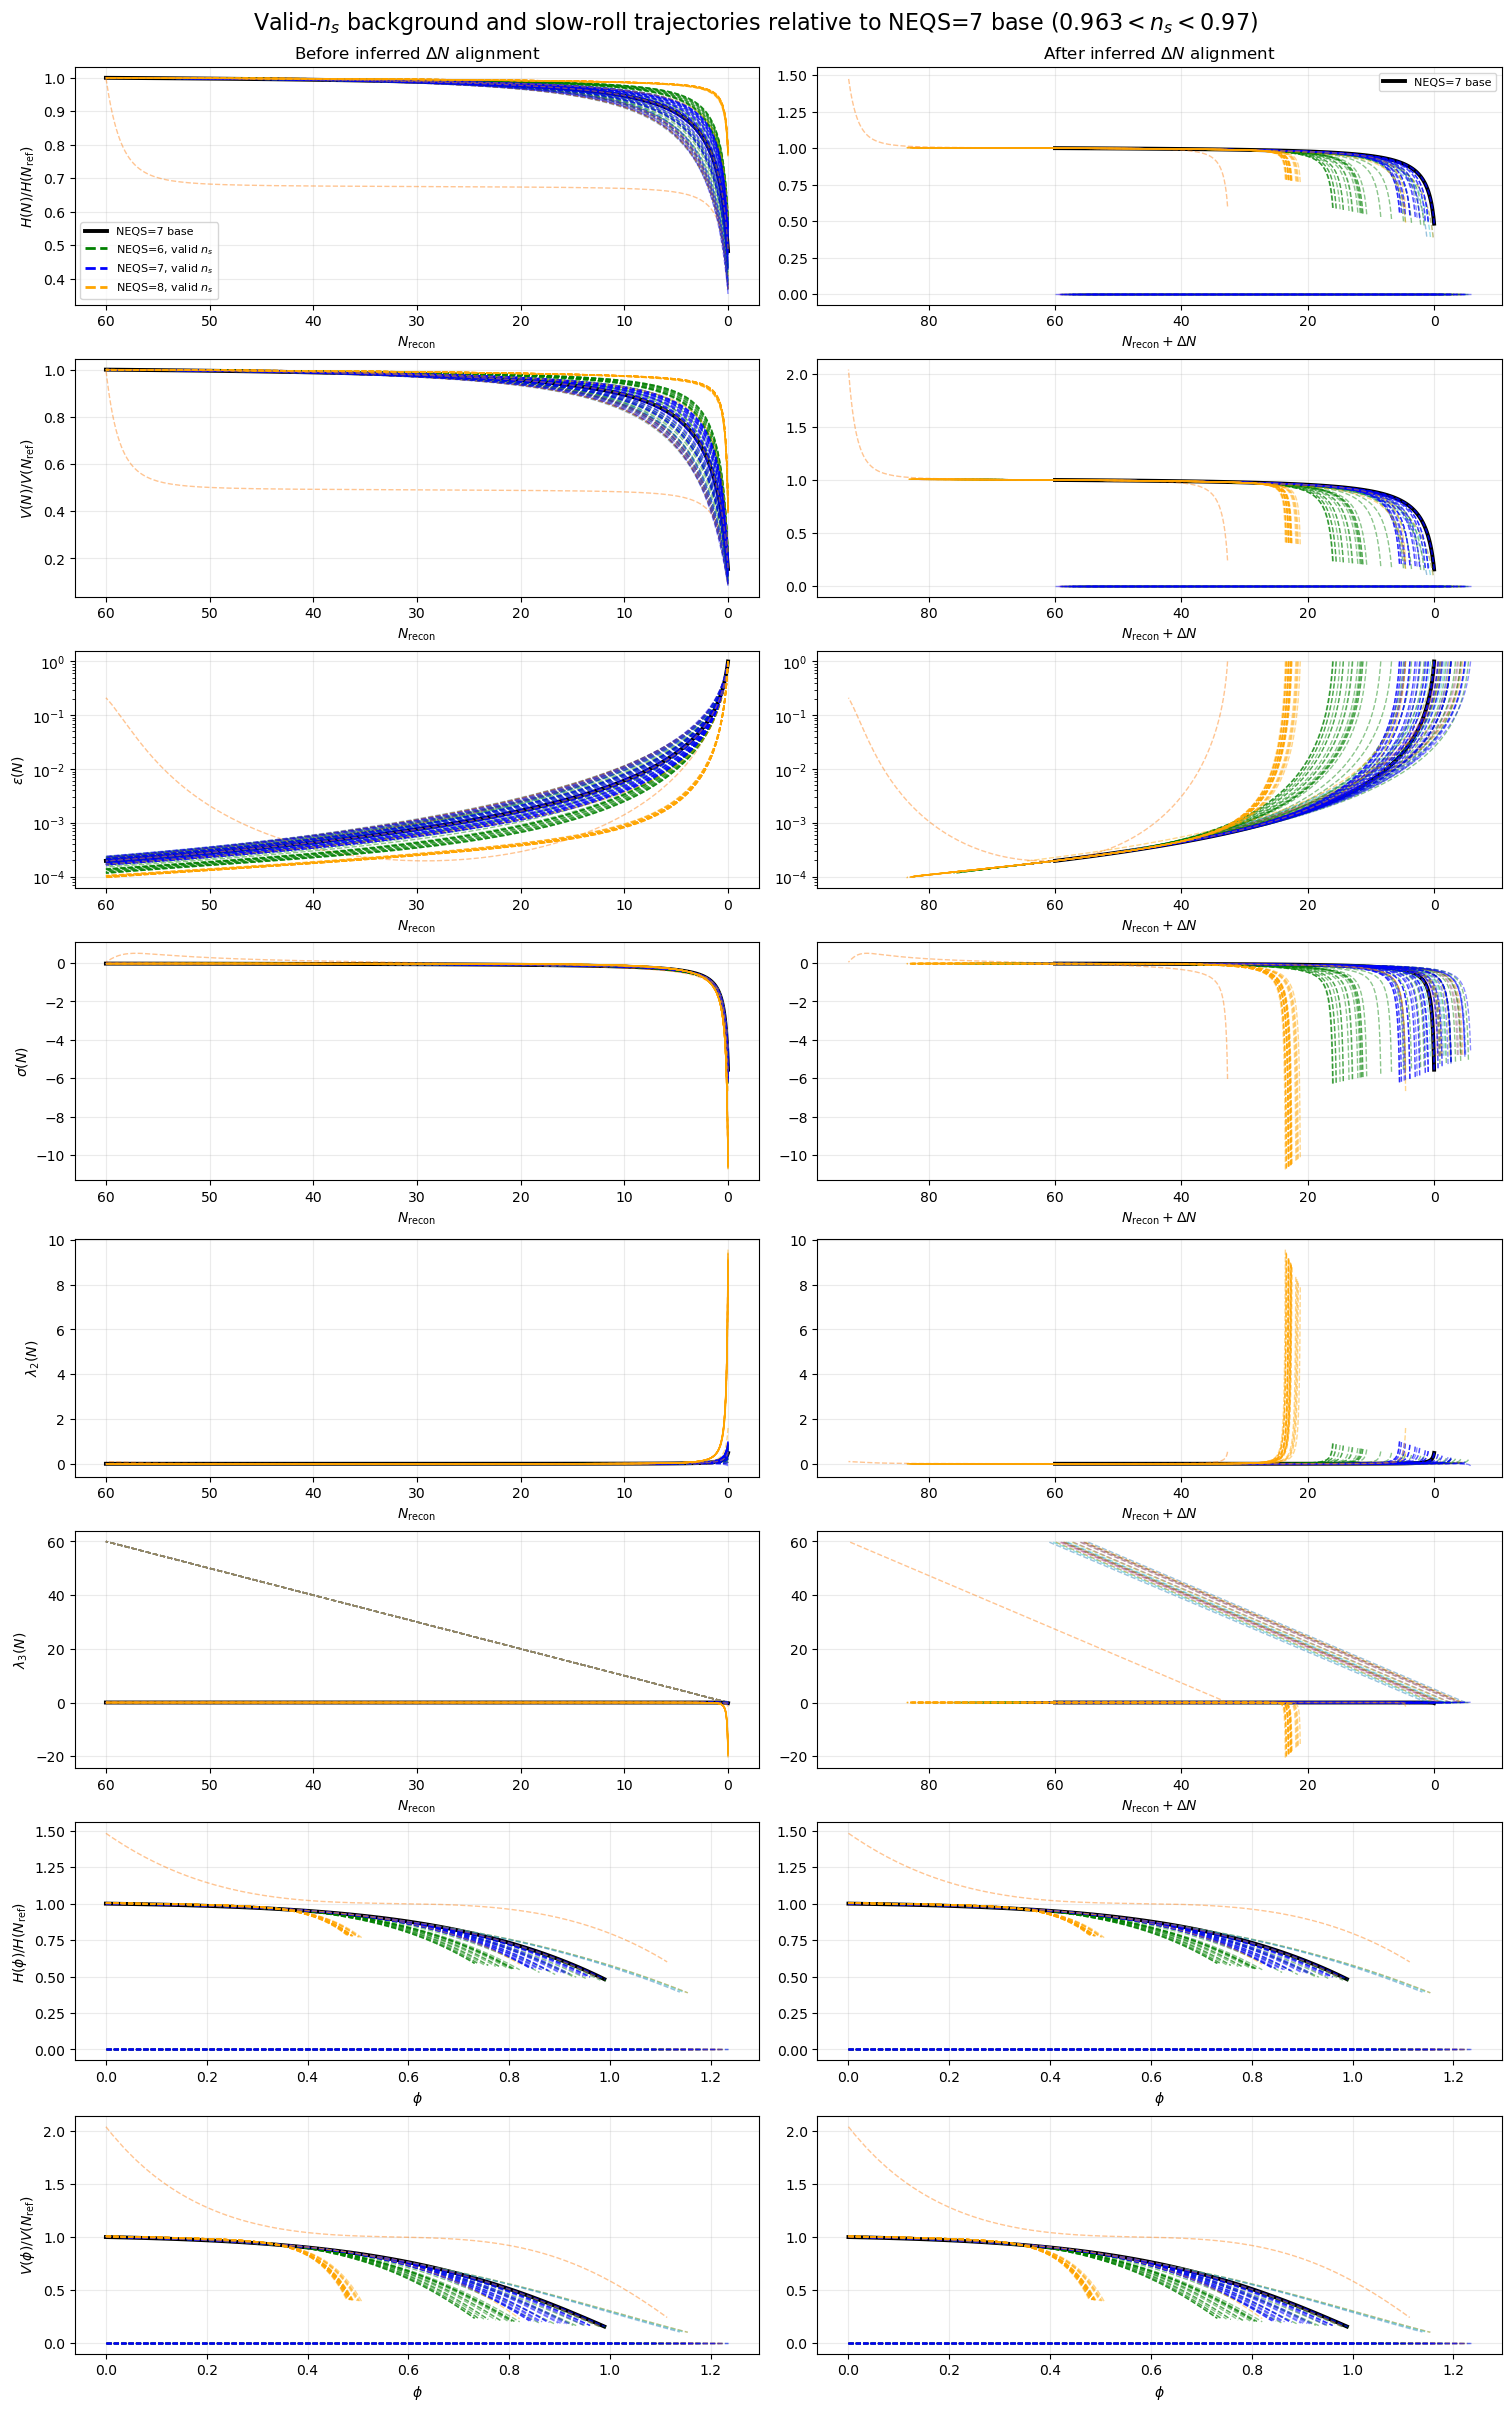


=== Background trajectory models included ===
 NEQS param_name         value        r       ns   alpha_s  original_N_end  deltaN_from_ref_base
    5       lam2  4.096659e-04 0.003753 0.963605 -0.000898      936.833576             -5.003495
    5       lam2  4.197753e-04 0.003690 0.963986 -0.000910      937.304881             -4.532190
    5       lam2  4.241409e-04 0.003663 0.964151 -0.000916      937.504610             -4.332461
    5       lam2  4.269022e-04 0.003647 0.964257 -0.000919      937.629793             -4.207278
    5       lam2  4.346050e-04 0.003602 0.964552 -0.000929      937.974384             -3.862687
    5       lam2  4.386324e-04 0.003580 0.964708 -0.000934      938.151909             -3.685162
    5       lam2  4.633163e-04 0.003450 0.965675 -0.000965      939.202362             -2.634709
    5       lam2  4.646192e-04 0.003444 0.965727 -0.000966      939.256087             -2.580983
    5       lam2  4.685373e-04 0.003425 0.965883 -0.000971      939.416660      

In [65]:
lam_values_by_neqs = {
    5: lam2_values,
    6: lam3_values,
    7: lam4_values,
    8: lam5_values,
}

bg_model_df = plot_background_trajectories_before_after_deltaN(
    base_path_root=base_path_root,
    lam_values_by_neqs=lam_values_by_neqs,
    ref_NEQS=7,
    ref_param="lam4",
    ref_value=6.87065e-8,
    ns_min=0.963,
    ns_max=0.970,
    N_ref=60.0,
    skip_zero=True,
    normalize_H=True,
    normalize_V=True,
    save_name="valid_ns_background_before_after_deltaN_ref_neqs7.png",
)



It would seem that accounting for $\Delta$N fixes the dominant placement problem, but the remaining differences reflect where each reconstructed trajectory departs from the common slow-roll path. The spectra mostly collapse but not perfectly: H and Pt mostly care about the common track, while Ps is more sensitive to the SRP peeling-off behavior since it is proportional to $H^2$/$\epsilon$.

## Arthur Suggested Plot

In [66]:
def plot_shifted_power_ratio_to_reference(
    model_info_df,
    ref_NEQS,
    ref_param,
    ref_value,
    base_path_root,
    k_ref=0.05,
    k_max_scalar=10.0,
    save_name=None,
):

    def folder_for(NEQS, param_name, value):
        val_str = f"{value:.10e}"
        return os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"{param_name}_{val_str}",
        )

    def load_specs(NEQS, param_name, value):
        folder = folder_for(NEQS, param_name, value)

        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

        k_s, Ps = prepare_increasing(s[:, 0], np.abs(s[:, 1]))
        k_t, Pt = prepare_increasing(t[:, 0], np.abs(t[:, 1]))

        return k_s, Ps, k_t, Pt

    def normalize(k, P):
        k, P = prepare_increasing(k, P)
        P_ref = np.interp(k_ref, k, P)
        return k, P / P_ref

    # Reference Higgs spectra
    k_s_ref, Ps_ref, k_t_ref, Pt_ref = load_specs(
        ref_NEQS, ref_param, ref_value
    )

    k_s_ref, Ps_ref = normalize(k_s_ref, Ps_ref)
    k_t_ref, Pt_ref = normalize(k_t_ref, Pt_ref)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
    ax_s, ax_t = axes

    rows = []

    for _, row in model_info_df.iterrows():
        NEQS = int(row["NEQS"])
        param_name = row["param_name"]
        value = float(row["value"])
        
        if "deltaN_from_ref" in model_info_df.columns:
            deltaN = float(row["deltaN_from_ref"])

        elif "deltaN_from_ref_base" in model_info_df.columns:
            deltaN = float(row["deltaN_from_ref_base"])

        else:
            raise KeyError(
                "model_info_df must contain either "
                "'deltaN_from_ref' or "
                "'deltaN_from_ref_base'"
            )

        try:
            k_s, Ps, k_t, Pt = load_specs(NEQS, param_name, value)

            # Delta-N alignment
            k_s_shift = k_s * np.exp(-deltaN)
            k_t_shift = k_t * np.exp(-deltaN)

            k_s_shift, Ps_norm = normalize(k_s_shift, Ps)
            k_t_shift, Pt_norm = normalize(k_t_shift, Pt)

            # Ratio to reference on reference grid
            mask_s = k_s_ref <= k_max_scalar

            Ps_interp = np.interp(k_s_ref[mask_s], k_s_shift, Ps_norm)
            Pt_interp = np.interp(k_t_ref, k_t_shift, Pt_norm)

            ratio_s = Ps_interp / Ps_ref[mask_s]
            ratio_t = Pt_interp / Pt_ref

            ax_s.semilogx(
                k_s_ref[mask_s],
                ratio_s,
                lw=1.0,
                alpha=0.35,
            )

            ax_t.semilogx(
                k_t_ref,
                ratio_t,
                lw=1.0,
                alpha=0.35,
            )

            rows.append({
                "NEQS": NEQS,
                "param_name": param_name,
                "value": value,
                "deltaN_from_ref": deltaN,
                "max_abs_scalar_ratio_minus_1_pct": 100*np.nanmax(np.abs(ratio_s - 1)),
                "max_abs_tensor_ratio_minus_1_pct": 100*np.nanmax(np.abs(ratio_t - 1)),
            })

        except Exception as e:
            print(f"Skipping NEQS={NEQS}, {param_name}={value:.3e}: {e}")

    for ax in axes:
        ax.axhline(1.0, color="black", lw=2, ls="--", label="reference")
        ax.axvline(k_ref, color="black", lw=1, ls=":", alpha=0.6)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
        ax.set_xlabel(r"$k$")

    ax_s.set_title(r"Scalar spectra after $\Delta N$ alignment")
    ax_t.set_title(r"Tensor spectra after $\Delta N$ alignment")

    ax_s.set_ylabel(r"$P_s^{\rm model}(k e^{-\Delta N})/P_s^{\rm ref}(k)$")
    ax_t.set_ylabel(r"$P_t^{\rm model}(k e^{-\Delta N})/P_t^{\rm ref}(k)$")

    fig.suptitle(
        "Effect of random higher-order slow-roll parameters after alignment",
        fontsize=15,
    )

    if save_name is None:
        save_name = "shifted_power_ratio_to_higgs_reference.png"

#     plt.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()

    return pd.DataFrame(rows)



In the plot below each scan gets compared to its own base model. It loads Ps and Pt and finds deltaN. It applies shift and finds ratios instead, like Ps shifted for a model divided by Ps for the original k range.

In [72]:
def plot_higher_order_random_tail_ratio_bundles(
    base_path_root,
    scans,
    ns_min=None,
    ns_max=None,
    k_ref=0.05,
    k_max_scalar=10.0,
    skip_zero=True,
    zero_tol=1e-30,
    alpha=0.35,
    save_name=None,
):
    """
    Plot bundles of shifted power-spectrum ratios for each hierarchy scan.

    For each NEQS scan:
        - reference = that NEQS base model
        - models = varied lamX values in that scan
        - shift each model by k -> k exp(-DeltaN)
        - plot P_model_shifted / P_base

    This is meant to show whether varying the newly-added higher-order
    slow-roll parameter mostly affects small scales after DeltaN alignment.
    """

    colors_by_neqs = {
        5: "red",
        6: "green",
        7: "blue",
        8: "orange",
    }

    def folder_for(NEQS, param_name, value):
        val_str = f"{value:.10e}"
        return os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"{param_name}_{val_str}",
        )

    def load_specs(NEQS, param_name, value):
        folder = folder_for(NEQS, param_name, value)

        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

        k_s, Ps = prepare_increasing(s[:, 0], np.abs(s[:, 1]))
        k_t, Pt = prepare_increasing(t[:, 0], np.abs(t[:, 1]))

        return k_s, Ps, k_t, Pt

    def load_observables(NEQS, param_name, value):
        folder = folder_for(NEQS, param_name, value)
        arr = np.loadtxt(os.path.join(folder, f"test_nr_neqs{NEQS}.dat"))
        arr = np.atleast_1d(arr)

        r = arr[0]
        ns = arr[1]
        alpha_s = arr[2]

        return r, ns, alpha_s

    def get_original_N_end(NEQS, param_name, value):
        summary_file = os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"neqs{NEQS}_summary.csv",
        )

        summary_df = pd.read_csv(summary_file)

        matches = summary_df.loc[
            np.isclose(summary_df[param_name], value)
        ]

        if len(matches) == 0:
            raise ValueError(
                f"No summary row found for NEQS={NEQS}, "
                f"{param_name}={value:.10e}"
            )

        return float(matches.iloc[0]["original_N_end"])

    def normalize_at_k(k, P, k0):
        k, P = prepare_increasing(k, P)

        if not (k.min() <= k0 <= k.max()):
            raise ValueError(
                f"k_ref={k0} outside range [{k.min():.3e}, {k.max():.3e}]"
            )

        P0 = np.interp(k0, k, P)

        if np.abs(P0) < 1e-30:
            raise ValueError(f"Reference normalization too small at k={k0}")

        return k, P / P0

    nrows = len(scans)

    fig, axes = plt.subplots(
        nrows,
        2,
        figsize=(14, 4.2 * nrows),
        constrained_layout=True,
        squeeze=False,
    )

    rows = []

    for row_idx, scan in enumerate(scans):

        NEQS = scan["NEQS"]
        param_name = scan["param_name"]
        base_value = scan["base_value"]
        lam_values = scan["lam_values"]

        color = colors_by_neqs.get(NEQS, None)

        ax_s = axes[row_idx, 0]
        ax_t = axes[row_idx, 1]

        # ----------------------------
        # Base/reference for this NEQS
        # ----------------------------
        base_N_end = get_original_N_end(
            NEQS,
            param_name,
            base_value,
        )

        k_s_base_raw, Ps_base_raw, k_t_base_raw, Pt_base_raw = load_specs(
            NEQS,
            param_name,
            base_value,
        )

        k_s_base, Ps_base_norm = normalize_at_k(
            k_s_base_raw,
            Ps_base_raw,
            k_ref,
        )

        k_t_base, Pt_base_norm = normalize_at_k(
            k_t_base_raw,
            Pt_base_raw,
            k_ref,
        )

        mask_s_base = k_s_base <= k_max_scalar

        # base ratio = 1
        ax_s.axhline(1.0, color="black", lw=2.0, ls="--")
        ax_t.axhline(1.0, color="black", lw=2.0, ls="--")

        model_count = 0

        for item in lam_values:

            value = item[0] if isinstance(item, tuple) else item
            value = float(value)

            if skip_zero and np.isclose(value, 0.0, atol=zero_tol):
                continue

            try:
                r, ns, alpha_s = load_observables(
                    NEQS,
                    param_name,
                    value,
                )

                if ns_min is not None and ns < ns_min:
                    continue

                if ns_max is not None and ns > ns_max:
                    continue

                model_N_end = get_original_N_end(
                    NEQS,
                    param_name,
                    value,
                )

                deltaN = model_N_end - base_N_end

                k_s_raw, Ps_raw, k_t_raw, Pt_raw = load_specs(
                    NEQS,
                    param_name,
                    value,
                )

                # DeltaN alignment
                k_s_shift = k_s_raw * np.exp(-deltaN)
                k_t_shift = k_t_raw * np.exp(-deltaN)

                k_s_shift, Ps_shift_norm = normalize_at_k(
                    k_s_shift,
                    Ps_raw,
                    k_ref,
                )

                k_t_shift, Pt_shift_norm = normalize_at_k(
                    k_t_shift,
                    Pt_raw,
                    k_ref,
                )

                # Ratio on base/reference k-grid
                mask_s = k_s_base <= k_max_scalar

                Ps_interp = np.interp(
                    k_s_base[mask_s],
                    k_s_shift,
                    Ps_shift_norm,
                )

                Pt_interp = np.interp(
                    k_t_base,
                    k_t_shift,
                    Pt_shift_norm,
                )

                ratio_s = Ps_interp / Ps_base_norm[mask_s]
                ratio_t = Pt_interp / Pt_base_norm

                ax_s.semilogx(
                    k_s_base[mask_s],
                    ratio_s,
                    color=color,
                    lw=1.1,
                    alpha=alpha,
                )

                ax_t.semilogx(
                    k_t_base,
                    ratio_t,
                    color=color,
                    lw=1.1,
                    alpha=alpha,
                )

                rows.append({
                    "NEQS": NEQS,
                    "param_name": param_name,
                    "value": value,
                    "r": r,
                    "ns": ns,
                    "alpha_s": alpha_s,
                    "original_N_end": model_N_end,
                    "deltaN_from_scan_base": deltaN,
                    "max_abs_Ps_ratio_minus_1_pct": 100.0 * np.nanmax(np.abs(ratio_s - 1.0)),
                    "max_abs_Pt_ratio_minus_1_pct": 100.0 * np.nanmax(np.abs(ratio_t - 1.0)),
                })

                model_count += 1

            except FileNotFoundError:
                print(
                    f"Missing files for NEQS={NEQS}, "
                    f"{param_name}={value:.5e}"
                )

            except ValueError as e:
                print(
                    f"Skipping NEQS={NEQS}, "
                    f"{param_name}={value:.5e}: {e}"
                )

        ax_s.axvline(k_ref, color="black", ls=":", alpha=0.6)
        ax_t.axvline(k_ref, color="black", ls=":", alpha=0.6)

        ax_s.set_title(
            rf"NEQS={NEQS}: scalar ratios, varying ${param_name}$"
        )

        ax_t.set_title(
            rf"NEQS={NEQS}: tensor ratios, varying ${param_name}$"
        )

        ax_s.set_ylabel(
            rf"$P_s^{{\rm model}}(k e^{{-\Delta N}})/P_s^{{\rm base}}(k)$"
        )

        ax_t.set_ylabel(
            rf"$P_t^{{\rm model}}(k e^{{-\Delta N}})/P_t^{{\rm base}}(k)$"
        )

        ax_s.set_xlabel(r"$k$")
        ax_t.set_xlabel(r"$k$")

        ax_s.grid(True, alpha=0.3)
        ax_t.grid(True, alpha=0.3)

        ax_s.set_xlim(k_s_base.min(), k_max_scalar)

        # Tiny annotation
        ax_s.text(
            0.03,
            0.05,
            rf"$N_{{\rm models}}={model_count}$",
            transform=ax_s.transAxes,
            fontsize=10,
            bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"),
        )

    if ns_min is not None and ns_max is not None:
        ns_label = rf", ${ns_min}<n_s<{ns_max}$"
    else:
        ns_label = ""

    fig.suptitle(
        rf"Power-spectrum ratios after $\Delta N$ alignment{ns_label}",
        fontsize=16,
    )

    if save_name is None:
        save_name = "higher_order_random_tail_ratio_bundles.png"

#     plt.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()

    ratio_df = pd.DataFrame(rows)

    if not ratio_df.empty:
        print("\n=== Ratio bundle summary ===")
        print(
            ratio_df.groupby("NEQS")
            .agg(
                n_models=("NEQS", "count"),
                max_Ps_ratio_pct=("max_abs_Ps_ratio_minus_1_pct", "max"),
                median_Ps_ratio_pct=("max_abs_Ps_ratio_minus_1_pct", "median"),
                max_Pt_ratio_pct=("max_abs_Pt_ratio_minus_1_pct", "max"),
                median_Pt_ratio_pct=("max_abs_Pt_ratio_minus_1_pct", "median"),
                median_deltaN=("deltaN_from_scan_base", "median"),
                max_abs_deltaN=("deltaN_from_scan_base", lambda x: np.nanmax(np.abs(x))),
            )
            .reset_index()
            .to_string(index=False)
        )

    return ratio_df

Skipping NEQS=5, lam2=4.65336e-03: k_ref=0.05 outside range [1.804e-25, 1.498e-05]


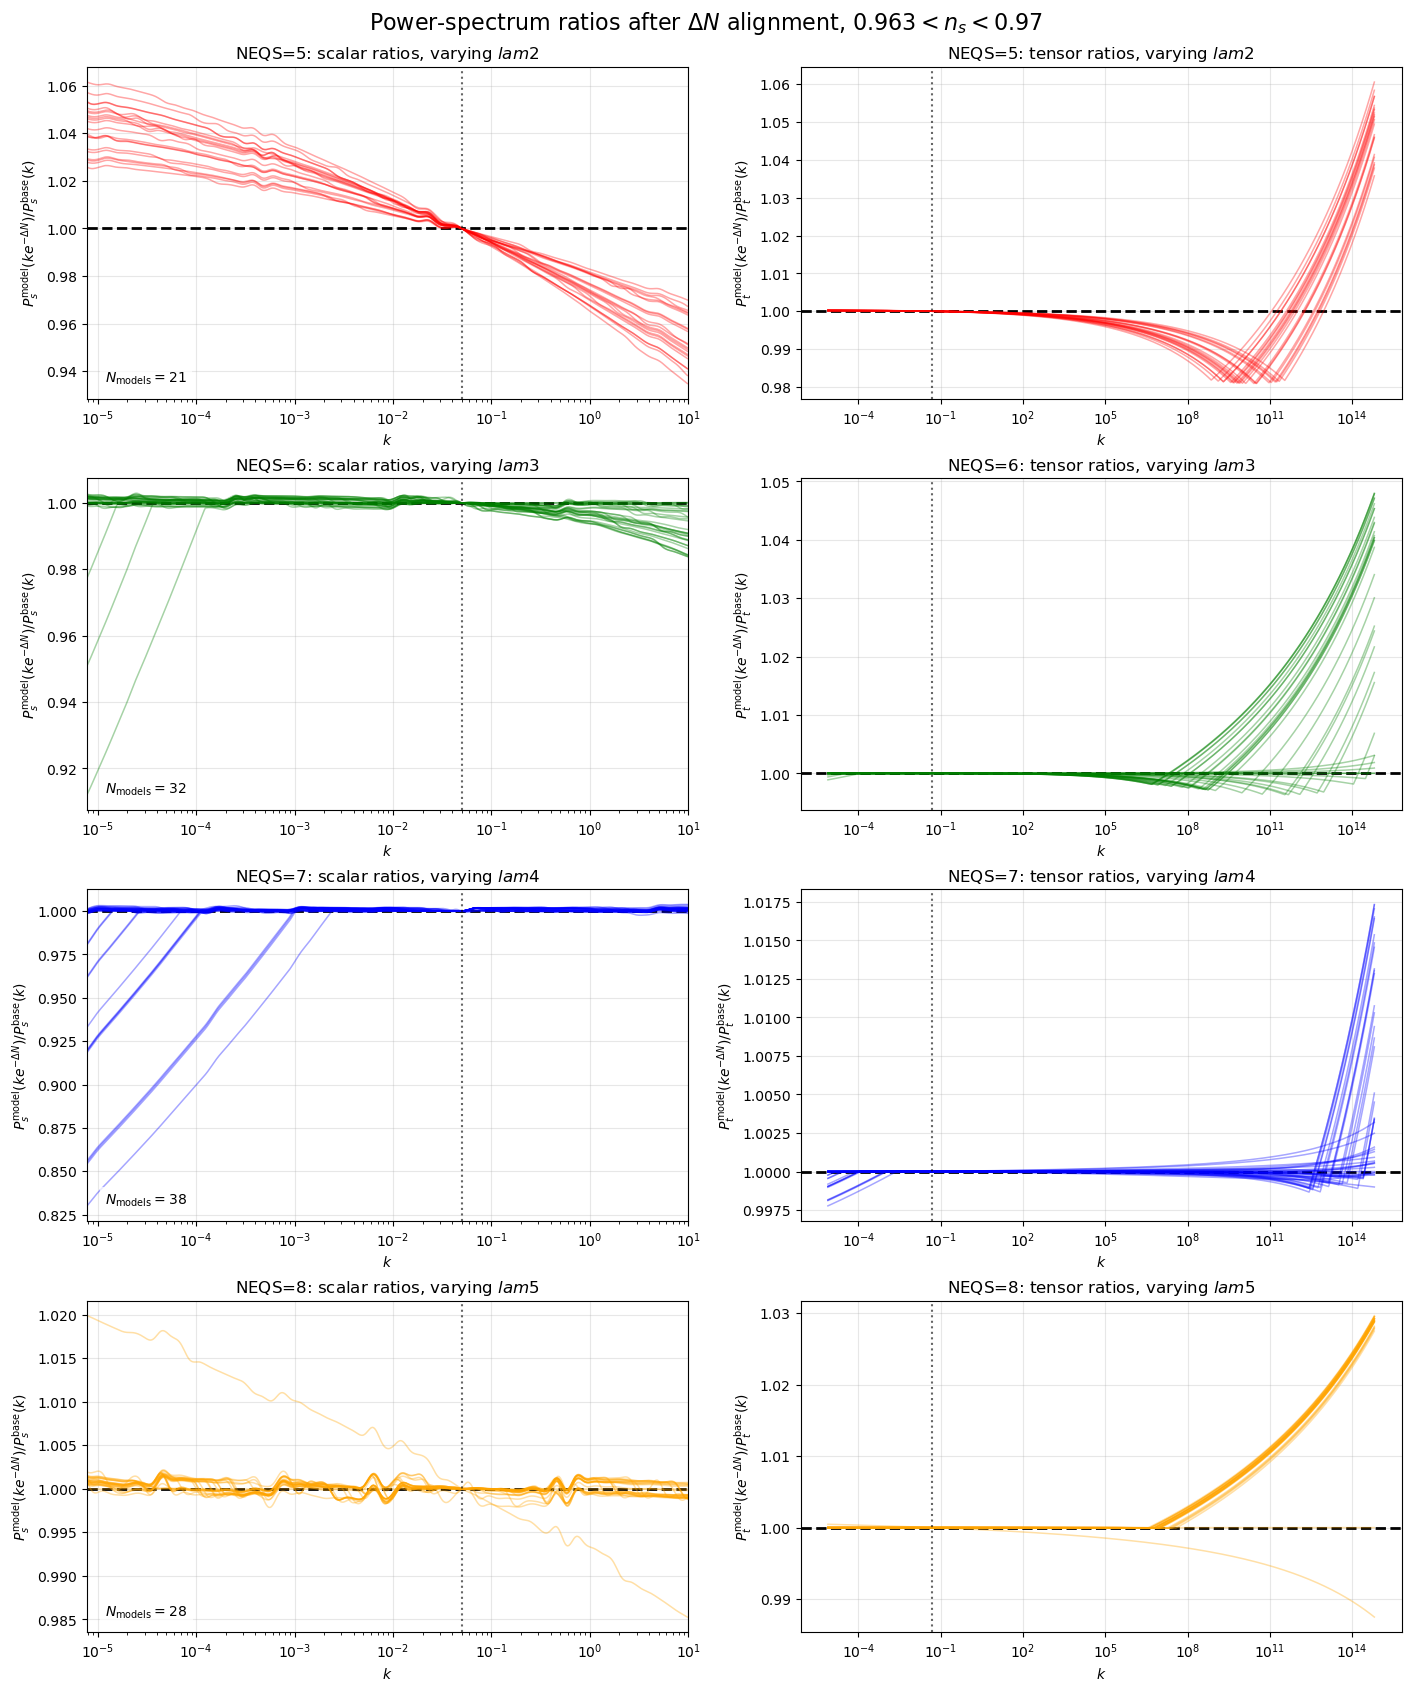


=== Ratio bundle summary ===
 NEQS  n_models  max_Ps_ratio_pct  median_Ps_ratio_pct  max_Pt_ratio_pct  median_Pt_ratio_pct  median_deltaN  max_abs_deltaN
    5        21          6.511849             4.866522          6.057147             5.059903      11.082466       13.687533
    6        32          8.792564             0.978811          4.796196             3.987697      13.946976       18.738119
    7        38         16.990608             0.231932          1.733064             0.343977       0.930149        5.770491
    8        28          1.988211             0.174419          2.964378             2.892710      18.185768       19.030728


In [73]:
scans = [
       {
        "NEQS": 5,
        "param_name": "lam2",
        "base_value": 0.000278972,
        "lam_values": lam2_values,
    },
    
    {
        "NEQS": 6,
        "param_name": "lam3",
        "base_value": -4.6097100000e-6,
        "lam_values": lam3_values,
    },
    {
        "NEQS": 7,
        "param_name": "lam4",
        "base_value": 6.87065e-8,
        "lam_values": lam4_values,
    },
    {
        "NEQS": 8,
        "param_name": "lam5",
        "base_value": -8.92461e-9,
        "lam_values": lam5_values,
    },
]

ratio_bundle_df = plot_higher_order_random_tail_ratio_bundles(
    base_path_root=base_path_root,
    scans=scans,
    ns_min=0.963,
    ns_max=0.970,
    k_ref=0.05,
    k_max_scalar=10.0,
    skip_zero=True,
    alpha=0.35,
    save_name="higher_order_random_tail_ratio_bundles_valid_ns.png",
)